In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

import verify_data as verify
import plotting_functions as plot_func
import load_nwb 
from load_nwb import nwb_loader
import prep_data as data_prep
import nwb_data_prep as nwb_prep

In [2]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import os,sys,glob, json
import _pickle as pkl

from tqdm.notebook import tqdm
%matplotlib inline
%load_ext autoreload
%autoreload 2
# plt.style.use('dark_background')

import pca_data_prep as prep
# import pca_plotting as plots
import verify_data as verify
# Load mouse_name from .env
import os
from dotenv import load_dotenv

# Always reload local modules so notebook uses latest patched code.
prep = importlib.reload(prep)
# plots = importlib.reload(plots)

print('pca_data_prep path:', Path(prep.__file__).resolve())
if not hasattr(prep, 'extract_probe_letters'):
    raise AttributeError(
        'Loaded pca_data_prep does not expose extract_probe_letters. '
        'Restart kernel and re-run this cell, then confirm it points to master/pca_data_prep.py.'
    )


pca_data_prep path: C:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\pca_data_prep.py


### Load in .env file

In [3]:
session_data_dic = prep.load_env()
session_data_dic

MOUSE loaded: Reach15




-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- First Neuropixels File --
NP_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
DATE loaded: 20260129
SESSION loaded: session003
BOMBCELL loaded: bombcell_batch_20260305_1130
PROBE_A_CH_CONFIG loaded: probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_C_CH_CONFIG loaded: probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_D_CH_CONFIG loaded: probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json


-- Second Neuropixels File --
NP_FILE loaded: Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32
NWB_FILE loaded: NA
DATE_01 loaded: 20260129
SESSION_01 loaded: session004
BOMBCELL_01 loaded: NA
PROBE_A_CH_CONFIG_01 loaded: NA
PROBE_C_CH_CONFIG_01 loaded: NA
PROBE_D_CH_CONFIG_01 loa

{'MOUSE': 'Reach15',
 'BEHAVIORAL_FOLDER': 'grant_reach15_swingDoor-christie',
 'NP_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'DATE': '20260129',
 'SESSION': 'session003',
 'BOMBCELL': 'bombcell_batch_20260305_1130',
 'NWB_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'PROBE_A_CH_CONFIG': 'probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_C_CH_CONFIG': 'probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_D_CH_CONFIG': 'probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'NP_FILE_01': 'Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32',
 'DATE_01': '20260129',
 'SESSION_01': 'session004',
 'BOMBCELL_01': 'NA',
 'NWB_FILE_01': 'NA',
 'PROBE_A_CH_CONFIG_01': 'NA',
 'PROBE_C_CH_CONFIG_01': 'NA',
 'PROBE_D_CH_CONFIG_01': 'NA',
 'NP_FILE_02': 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00',
 'DA

#### ============================================================
## SELECT SESSION TO ANALYZE
#### ============================================================

In [4]:
SESSION_TO_ANALYZE = 3

MOUSE, BEHAVIORAL_FOLDER, PROBE_A_CH_CONFIG, PROBE_C_CH_CONFIG, PROBE_D_CH_CONFIG , NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL= prep.session_to_analyze(
                                                                                        session_data_dic['MOUSE'], session_data_dic['BEHAVIORAL_FOLDER'], 
                                                                                        session_data_dic['NP_FILE'],session_data_dic['NWB_FILE'] ,session_data_dic['DATE'], session_data_dic['SESSION'],session_data_dic['BOMBCELL'],session_data_dic['PROBE_A_CH_CONFIG'], session_data_dic['PROBE_C_CH_CONFIG'], session_data_dic['PROBE_D_CH_CONFIG'],
                                                                                        session_data_dic['NP_FILE_01'], session_data_dic['NWB_FILE_01'], session_data_dic['DATE_01'], session_data_dic['SESSION_01'],session_data_dic['BOMBCELL_01'] ,session_data_dic['PROBE_A_CH_CONFIG_01'], session_data_dic['PROBE_C_CH_CONFIG_01'], session_data_dic['PROBE_D_CH_CONFIG_01'],
                                                                                        session_data_dic['NP_FILE_02'], session_data_dic['NWB_FILE_02'], session_data_dic['DATE_02'], session_data_dic['SESSION_02'],session_data_dic['BOMBCELL_02'],session_data_dic['PROBE_A_CH_CONFIG_02'], session_data_dic['PROBE_C_CH_CONFIG_02'], session_data_dic['PROBE_D_CH_CONFIG_02'],
                                                                                        session_selection=SESSION_TO_ANALYZE
                                                                                    )
SESSION_NAME = NP_FILE
                                                               


SESSION SELECTION:

NP_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
NWB_FILE: Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
DATE: 20260201
SESSION: session007
BEHAVIORAL_FOLDER: grant_reach15_swingDoor-christie
BOMBCELL: bombcell_batch_20260304_1536
PROBE_A_CH_CONFIG: probeA_SIM_IP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_C_CH_CONFIG: probeC_MoP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
PROBE_D_CH_CONFIG: probeD_VaL__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json


### Create full paths from .env variables for selected session

In [5]:
PROBES = ['A', 'B', 'C', 'D', 'E', 'F']
paths_dic = prep.setup_paths_and_verify(PROBES,NWB_FILE, NP_FILE, DATE, SESSION, BEHAVIORAL_FOLDER, BOMBCELL)
print("\nPaths setup and verified successfully. Paths dictionary:")
for key, value in paths_dic.items():
    print(f"{key}: {value}")

✅ Found bombcell data for probe A at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536\kilosort4_A
✅ Found bombcell data for probe B at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536\kilosort4_B
✅ Found bombcell data for probe C at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536\kilosort4_C
✅ Found bombcell data for probe D at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536\kilosort4_D
✅ Found bombcell data for probe E at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260304_1536\kilosort4_E
✅ Found bo

### set up channel map paths from .env variables

In [6]:
probe_A_ch_configuation_file_path = rf"H:\Grant\Neuropixels\Kilosort_Recordings\{SESSION_NAME}\NP2_shank_configuation_files\.json\{PROBE_A_CH_CONFIG}"
probe_C_ch_configuation_file_path = rf"H:\Grant\Neuropixels\Kilosort_Recordings\{SESSION_NAME}\NP2_shank_configuation_files\.json\{PROBE_C_CH_CONFIG}"
probe_D_ch_configuation_file_path = rf"H:\Grant\Neuropixels\Kilosort_Recordings\{SESSION_NAME}\NP2_shank_configuation_files\.json\{PROBE_D_CH_CONFIG}"

ch_configs = {
    'A': probe_A_ch_configuation_file_path,
    'C': probe_C_ch_configuation_file_path,
    'D': probe_D_ch_configuation_file_path
}

for key, value in ch_configs.items():
    if not os.path.isfile(value):
        raise FileNotFoundError(f"Channel configuration file for Probe {key} not found at path: {value}") 
    else:
        print(f"Channel configuration file for Probe {key} found at path: {value}")  

Channel configuration file for Probe A found at path: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\NP2_shank_configuation_files\.json\probeA_SIM_IP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
Channel configuration file for Probe C found at path: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\NP2_shank_configuation_files\.json\probeC_MoP__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json
Channel configuration file for Probe D found at path: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\NP2_shank_configuation_files\.json\probeD_VaL__Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00.json


### Set up NP Root folder using .env variabes

In [7]:
# Construct the recording folder path
root_recording_folder = fr"H:\Grant\Neuropixels\Kilosort_Recordings\{NP_FILE}"  # Replace with actual root path
print(f'root_recording_folder: {root_recording_folder}' )
recording_folder = os.path.join(root_recording_folder, "Record Node 103", "experiment1", "recording1", "continuous")

#root_behavior_path = fr"G:\Grant\neuropixels\behavioral_recordings\{BEHAVIORAL_FOLDER}"
# Example values (replace as needed)A
root_behavior_path = fr"G:\Grant\behavior_data\DLC_net\{BEHAVIORAL_FOLDER}"
behavioral_folder = os.path.join(root_behavior_path, DATE ,SESSION)
print(f'behavioral_folder: {behavioral_folder}')
# Check if the recording folder exists
if not os.path.exists(recording_folder):
    raise FileNotFoundError(f"Recording folder not found: {recording_folder}")
else:
    print("Neuropixel Recording folder found:", recording_folder)

recording_folder = root_recording_folder + r"\Record Node 103\experiment1\recording1\continuous"
if not os.path.exists(recording_folder):
    raise FileNotFoundError(f"Recording folder not found: {recording_folder}")
else:
    print("Recording folder found: ", recording_folder)

root_recording_folder: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
behavioral_folder: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\20260201\session007
Neuropixel Recording folder found: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\Record Node 103\experiment1\recording1\continuous
Recording folder found:  H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\Record Node 103\experiment1\recording1\continuous


In [8]:
from pathlib import Path
behavioral_folder = Path(behavioral_folder)
date = behavioral_folder.name
session = behavioral_folder.parts[-1]
date = behavioral_folder.parts[-2]

behavior_curation = (
    behavioral_folder.parent.parent
    / "Grant_curate"
    / f"{date}_christielab_{session}.xlsx"
)

print(behavior_curation)


G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\Grant_curate\20260201_christielab_session007.xlsx


### use the paths_dic to set specific variables for the session

In [9]:

mouse_nwb = paths_dic['NWB_PATH']
SESSION_NAME = session_data_dic['NP_FILE']
baseline_trials_index_path =paths_dic['baseline_trials_index_path']
washout_trials_index_path = paths_dic['washout_trials_index_path']
optoicalStim_trials_index_path = paths_dic['optoicalStim_trials_index_path']
save_dir = root_recording_folder
behavior_curation = behavior_curation
BOMBCELL_ROOT_FOR_AUTO_BUILD = paths_dic['BOMBCELL_ROOT_FOR_AUTO_BUILD']
print(f'mouse_nwb: {mouse_nwb}')
print(f'baseline_trials_index_path: {baseline_trials_index_path}')
print(f'washout_trials_index_path: {washout_trials_index_path}')
print(f'optoicalStim_trials_index_path: {optoicalStim_trials_index_path}')
print(f'save_dir: {save_dir}')
print(f'behavior_curation: {behavior_curation}')
print(f'BOMBCELL_ROOT_FOR_AUTO_BUILD: {BOMBCELL_ROOT_FOR_AUTO_BUILD}')
# Verify that the NWB file exists

mouse_nwb: H:\NWB_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
baseline_trials_index_path: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy
washout_trials_index_path: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy
optoicalStim_trials_index_path: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy
save_dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
behavior_curation: G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\Grant_curate\20260201_christielab_session007.xlsx
BOMBCELL_ROOT_FOR_AUTO_BUILD: H:\Gra

### SET 1: Load in the NWB file & Specify save_dir for all the data made in this notebook

In [10]:
# load NWB with nwb path
mouse_id = load_nwb.nwb_loader(mouse_nwb)

# Verify data in nwb
df_stim, df_units = nwb_loader.verify_nwb_data(mouse_id)

display(df_stim)
display(df_units)

loaded NWB from: H:\NWB_OUT\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00

===== Total units Per Probe ====
A:  554
B:  1316
C:  355
D:  820
E:  864
F:  691

 ======= Unique stimulus types ==========   : 
 ['tone1_timestamps' 'tone2_timestamps' 'stimROI_timestamps'
 'frame_events_timestamp' 'optical_timestamps'
 'reachInit_stimROI_timestamps' 'opto_tagging_timestamps'
 'baseline_reachInit_stimROI_timestamps'
 'stimulation_reachInit_stimROI_timestamps'
 'washout_reachInit_stimROI_timestamps']

===== Total Timestamps Per Event ====
tone1_timestamps:  376
tone2_timestamps:  270
stimROI_timestamps:  130
frame_events_timestamp:  1349818
optical_timestamps:  1900
reachInit_stimROI_timestamps:  270
opto_tagging_timestamps:  60
baseline_reachInit_stimROI_timestamps:  20
stimulation_reachInit_stimROI_timestamps:  130
washout_reachInit_stimROI_timestamps:  120




,start_time,stop_time,stimulus,optogenetics_LED_state
id,,,,
0,10239.422800,10239.422800,tone1_timestamps,0
1,10261.289967,10261.289967,tone1_timestamps,0
2,10283.329000,10283.329000,tone1_timestamps,0
3,10304.578900,10304.578900,tone1_timestamps,0
4,10382.254700,10382.254700,tone1_timestamps,0
...,...,...,...,...
1353089,18328.552900,18328.552900,washout_reachInit_stimROI_timestamps,0
1353090,18404.188900,18404.188900,washout_reachInit_stimROI_timestamps,0
1353091,18444.522500,18444.522500,washout_reachInit_stimROI_timestamps,0


,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
0,0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,NOISE,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,NOISE,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,NOISE,"[9938.29451763671, 9938.519134975282, 9938.609..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,4595,860.0,43.0,3740.0,0,1,10.2,175.3,F,OUT_ROI,None,NON-SOMA,"[9939.57044788735, 9939.597083318817, 9939.703..."
4596,4596,1020.0,43.0,3580.0,0,2,19.5,0.0,F,OUT_ROI,None,NOISE,"[10919.660133182651, 10919.6751343645, 10919.7..."
4597,4597,1060.0,11.0,3540.0,0,1,9.6,236.7,F,OUT_ROI,None,NOISE,"[9996.778036617923, 10049.712567383913, 10050...."
4598,4598,980.0,43.0,3620.0,0,2,26.1,0.0,F,OUT_ROI,None,NON-SOMA,"[10919.650099059141, 10919.665100240469, 10919..."


### Seperate out df_units into good, mua, all

In [11]:
(
dfA_good,dfA_SIM_good, dfA_IP_good, dfB_good, dfC_good, dfD_good, dfE_good, dfF_good,
dfA_mua, dfB_mua, dfC_mua, dfD_mua, dfE_mua, dfF_mua
) = data_prep.seperate_good_mua_units(df_units)

display(dfA_SIM_good[0:3])
display(dfA_IP_good[0:3])
display(dfB_good[0:3])

Total units in probe A: 554
Good units in probe A: 137 --> SIM & IP
MUA units in probe A: 417 --> SIM & IP

Total units in probe A SIM: 85
Total units in probe A IP: 52

Total units in probe B: 1316
Good units in probe B: 531 --> PG
MUA units in probe B: 785 --> PG

Total units in probe C: 355
Good units in probe C: 158 --> Mop
MUA units in probe C: 197 --> Mop

Total units in probe D: 820
Good units in probe D: 376 --> VaL
MUA units in probe D: 444 --> VaL

Total units in probe E: 864
Good units in probe E: 512 --> SnR
MUA units in probe E: 352 --> SnR

Total units in probe F: 691
Good units in probe F: 390 --> RN
MUA units in probe F: 301 --> RN


c:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\prep_data.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfA_good = df_units[df_units.probe=='A'][df_units.KSlabel==2] # these are the "good" labelled units from phy before curation


,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
19,19,2265.0,59.0,885.0,0,2,9.1,0.2,A,IN_ROI,SIM,NON-SOMA,"[9938.072833857716, 9938.08960181831, 9938.110..."
21,21,2235.0,27.0,915.0,0,2,8.7,10.6,A,IN_ROI,SIM,NON-SOMA,"[9938.356389078523, 9938.391325108953, 9939.38..."
22,22,2235.0,27.0,915.0,0,2,11.2,4.1,A,IN_ROI,SIM,NOISE,"[9938.14980646585, 9938.387191456639, 9938.401..."


,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
0,0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42..."
3,3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,NOISE,"[9938.897430842511, 9940.381573391209, 9941.04..."


,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
555,555,6980.0,43.0,20.0,2,2,11.5,5.1,B,IN_ROI,PG,MUA,"[9938.444535996017, 9939.917013711796, 9958.09..."
558,558,6960.0,59.0,40.0,0,2,21.5,2.2,B,IN_ROI,PG,GOOD,"[10383.125186256175, 10510.258669273911, 10648..."
559,559,6960.0,59.0,40.0,0,2,13.7,11.0,B,IN_ROI,PG,MUA,"[9940.006420454596, 9941.025197287188, 9941.84..."


### Verify the time between start_times of stimulus events from df_stim

In [12]:
#load .npy files
baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)


Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

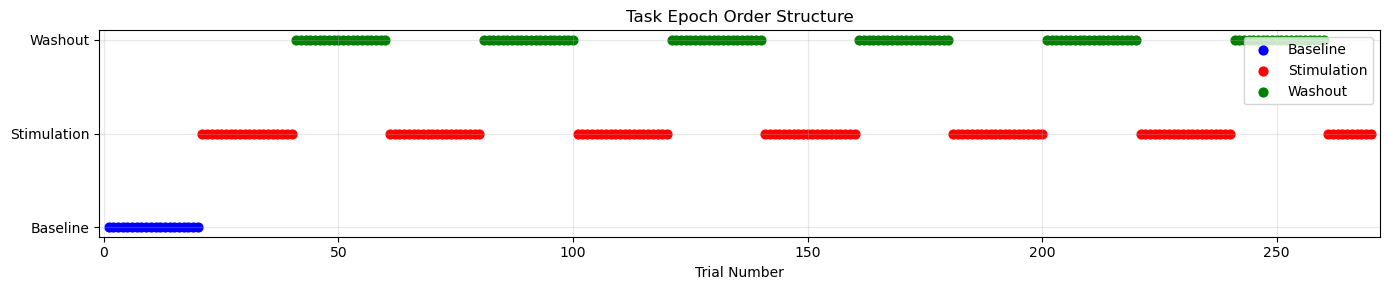

Epoch summaries (trial indices as used for verification):
  Baseline: 1..20 (n=20)
  Stim 1:  21..40 (n=20)
  Stim 2:  61..80 (n=20)
  Stim 3:  101..120 (n=20)
  Stim 4:  141..160 (n=20)
  Stim 5:  181..200 (n=20)
  Stim 6:  221..240 (n=20)
  Stim 7:  261..270 (n=10)
  Wash 1:  41..60 (n=20)
  Wash 2:  81..100 (n=20)
  Wash 3:  121..140 (n=20)
  Wash 4:  161..180 (n=20)
  Wash 5:  201..220 (n=20)
  Wash 6:  241..260 (n=20)

WARNINGS:
 - Stim epochs (7) != Wash epochs (6); checking first 6 pairs.

FAILED checks:
 - Stim epoch 7 size = 10 (expected 20).
 - Stim epochs = 7 (expected 5).
 - Wash epochs = 6 (expected 5).


In [13]:
result = verify.verify_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_per_epoch=20,
    expect_stim_epochs=5,
    expect_wash_epochs=5,
    auto_split_merged_epochs=True,
    split_mode="keep_incomplete",  # "raise" | "drop_incomplete" | "keep_incomplete"
    show_plot=True,
    verbose=True
)
# Overwrite with correct structure expected downstream
og_baseline_trials_idx = baseline_trials_idx
og_optoicalStim_trials_idx = optoicalStim_trials_idx
og_washout_trials_idx = washout_trials_idx

baseline_trials_idx = result["used_epochs"]["baseline"]
optoicalStim_trials_idx = result["used_epochs"]["stim"]
washout_trials_idx = result["used_epochs"]["wash"]

### Verify the time between events makes sense

In [14]:
stim_timing_dic = verify.check_stim_event_timing(df_stim,max_window=4,show_detailed_output=True)

=== Average time differences between events (valid pairs within expected window): ===

---- Expected ~2 s -----
tone1 and tone2:  1.43 (270 pairs)

---- These two should be similar -----
tone1 and stimROI:              1.75 (130 pairs)
tone1 and all_stimROI_triggers: 1.7 (270 pairs)

---- These two should be similar -----
tone2 and stimROI:              0.32 (127 pairs)
tone2 and all_stimROI_triggers: 0.32 (245 pairs)

---- Should be near zero -----
all_stimROI_triggers and stimROI: 0.04 (130 pairs)

=== Detailed valid time pairs (within expected window) ===

--- tone1_tone2 ---
  10239.423 s  -->  10239.945 s  (diff: 0.522 s)
  10261.290 s  -->  10263.387 s  (diff: 2.097 s)
  10283.329 s  -->  10284.957 s  (diff: 1.628 s)
  10304.579 s  -->  10305.746 s  (diff: 1.167 s)
  10382.255 s  -->  10382.945 s  (diff: 0.691 s)
  10461.343 s  -->  10462.508 s  (diff: 1.165 s)
  10482.123 s  -->  10484.223 s  (diff: 2.100 s)
  10503.843 s  -->  10504.382 s  (diff: 0.539 s)
  10524.476 s  -->  10

## Load in Behavior data files

### 1. Load in reachInit, reachMax, and reachEnd Frames and timestamps associated

In [15]:
behavior_curation

WindowsPath('G:/Grant/behavior_data/DLC_net/grant_reach15_swingDoor-christie/Grant_curate/20260201_christielab_session007.xlsx')

In [16]:
xlsx = pd.ExcelFile(behavior_curation)
#"C:\Users\user\Documents\DLC_net\grant_reach3_swingDoor-christie-2024-11-14\Grant_curate\old\20241114_christielab_session010_Grant_curate_20241118.xlsx"
xlsx
df_curate = pd.read_excel(xlsx, 'Sheet1')
# Adding a new column with sequential numbers starting from 1
df_curate['reach_number'] = range(1, len(df_curate) + 1)
df_curate[0:5]

df_curate

,T6000,T5000,reachInit,reachMax,reachEnd,Reach_Init,stim,stim_sent,behaviors,pellet_delivery,pellet_detected,ReachType,stim_present,Added_row,no_pellet_present,T6_T5_frames,actual_frame_delay_ms,set_delay_ms,delay_offset_ms,reach_number
0,31636.0,31715.0,31700,31706.0,31720.0,31702.0,0,0,none,0,0,NaN,False,31700.0,NaN,79.0,521.4,500.0,21.4,1
1,31636.0,31715.0,31702,NaN,NaN,31702.0,0,0,none,0,0,NaN,False,NaN,NaN,79.0,521.4,500.0,21.4,2
2,34916.0,35230.0,35218,NaN,NaN,35218.0,0,0,none,0,0,NaN,False,NaN,NaN,314.0,2072.4,2500.0,-427.6,3
3,34916.0,35230.0,35315,35347.0,35388.0,35218.0,0,0,dropped,0,0,short,False,35315.0,NaN,314.0,2072.4,2500.0,-427.6,4
4,38221.0,38465.0,38536,38553.0,38577.0,38541.0,0,0,none,0,0,on_pellet,False,38536.0,NaN,244.0,1610.4,2000.0,-389.6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,1240373.0,NaN,0,NaN,NaN,NaN,0,0,none,0,0,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,378
378,1253527.0,NaN,0,NaN,NaN,NaN,0,0,none,0,0,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,379
379,1254607.0,NaN,0,NaN,NaN,NaN,0,0,none,0,0,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,380
380,1282950.0,NaN,0,NaN,NaN,NaN,0,0,none,0,0,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,381


### Using Digital line data to get the timestamps for all events

In [17]:
tone1_start_times, tone2_start_times, frame_events_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = data_prep.extract_start_times(df_stim)


Total Tone1 start_times: 376
Total Tone2 start_times: 270
Total Frame Events start_times: 1349818
Total stimROI start_times: 130
Total Optical start_times: 1900
Total reachInit_stimROI start_times: 270


### Seperate out the Closed Loop Optical start_times from the Opto-Tagging start_times

In [18]:
(
    total_optical_timestamps,
    total_optoTagging_timestamps,
    total_opto_tagging_events,
    total_opto_tagging_pulses,
    first_opto_tagging_timestamp,
    end_opto_tagging_index,
    last_tone2_time,
    start_of_opto_tagging_index,
    behavioral_video_duration,
    final_behavioral_video_time,
    opto_closed_loop_start_timestamps,
    opto_tag_start_timestamps,
    last_closed_loop_start_time,
    first_opto_tagging_timestamp_per_trial,
    first_optical_pulse_per_closed_loop
) = data_prep.seperate_closedLoop_optoTagging(
    optical_start_times,
    tone2_start_times,
    frame_events_start_times,
    total_opto_tagging_events=60,
    pulses_per_event=10
)

Total optical start times: 1900
Total opto-tagging events: 60
Total opto-tagging pulses per event: 10
Last tone2 time: 18785.354166666668
Opto-tagging start time: 18840.179166666665, end time: 18958.665
Start of opto-tagging index: 1300

Estimated Behavioral Video duration (min): 149.98
Final behavioral Video Frame start_time: 19028.83

Total Closed Loop optical pulses: 1300
Total Opto-tagging optical pulses: 600


 ------- SUCCESS -------
 Optical Pulses have been seperated into closed loop and opto-tagging groups. And it has been verified that the first opto-tagging timestamp occurs after the last closed loop timestamp. 




In [19]:
print('Total closed loop start timestamps:', len(opto_closed_loop_start_timestamps))
print("Total optical timestamps:", len(opto_tag_start_timestamps),'\n')
print('Last 3 closed loop start timestamps:', opto_closed_loop_start_timestamps[-3:])
print("First 3 Opto-tagging timestamps:", opto_tag_start_timestamps[:3])

Total closed loop start timestamps: 1300
Total optical timestamps: 600 

Last 3 closed loop start timestamps: [18785.543 18785.548 18785.558]
First 3 Opto-tagging timestamps: [18840.17916667 18840.1892     18840.1942    ]


## Merge in bombcell columns to df_units

In [20]:
BOMBCELL_ROOT_FOR_AUTO_BUILD

WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00/bombcell/bombcell_batch_20260304_1536')

In [21]:
PROCESSED_BUNDLE_SESSION_DIR = (Path.cwd().resolve() / "processed_data" / NP_FILE)
PROCESSED_BUNDLE_SESSION_DIR.mkdir(parents=True, exist_ok=True)
bundle, merged_dic, stim_df, df_stim, pca_event_meta, extras, meta, PROCESSED_BUNDLE_DIR = nwb_prep.load_or_build_processed_bundle(
    processed_bundle_dir=PROCESSED_BUNDLE_SESSION_DIR,
    nwb_path_for_auto_build=mouse_nwb,
    bombcell_root_for_auto_build=BOMBCELL_ROOT_FOR_AUTO_BUILD,
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=("merged_dic.pkl", "stim_df.pkl", "pca_event_meta.pkl"),
    verbose=True,
)

print('\n\n NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell')

Loaded bundle: C:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\processed_data\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00
Meta: {'created_at': '2026-03-09T15:48:09.283782', 'files': ['merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl', 'extras.pkl'], 'n_probes': 6, 'n_events_stim_df': 1353094, 'n_events_pca_meta': 1353094}
pca_event_meta rows: 1353094


 NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell


In [22]:
pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times,baseline_reachInit_stimROI_start_times, stimulation_reachInit_stimROI_start_times, washout_reachInit_stimROI_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx
)

print('Total Rows in pca_event_meta: ', len(pca_event_meta))
print('Each rows = one trial')
print('\n Bellow should show the pca_event_meta seperated into the first 2 epochs. condition_epoch should match the above name\n')
print('baseline_epoch')
display(pca_event_meta[0:2])
print('stimulation_epoch_1')
display(pca_event_meta[20:22])
print('washout_epoch_1')
display(pca_event_meta[40:42])
print('stimulation_epoch_2')
display(pca_event_meta[60:62])
print('washout_epoch_2')
display(pca_event_meta[80:82])

Total Rows in pca_event_meta:  270
Each rows = one trial

 Bellow should show the pca_event_meta seperated into the first 2 epochs. condition_epoch should match the above name

baseline_epoch


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched
0,0,1,10239.893300,baseline,0,baseline_epoch,baseline,0,baseline_epoch,original_condition,False
1,1,2,10263.343867,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True


stimulation_epoch_1


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched
20,20,21,10919.650000,stimulation,1,stimulation_epoch_1,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True
21,21,22,10941.260333,stimulation,1,stimulation_epoch_1,stimulation,1,stimulation_epoch_1,original_condition,False


washout_epoch_1


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched
40,40,41,11432.124667,washout,1,washout_epoch_1,washout,1,washout_epoch_1,original_condition,False
41,41,42,11460.236200,washout,1,washout_epoch_1,washout,1,washout_epoch_1,reachInit_stimROI_real_start_times,True


stimulation_epoch_2


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched
60,60,61,12122.5500,stimulation,2,stimulation_epoch_2,stimulation,2,stimulation_epoch_2,original_condition,False
61,61,62,12144.6605,stimulation,2,stimulation_epoch_2,stimulation,2,stimulation_epoch_2,original_condition,False


washout_epoch_2


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched
80,80,81,12656.674933,washout,2,washout_epoch_2,washout,2,washout_epoch_2,reachInit_stimROI_real_start_times,True
81,81,82,12676.951833,washout,2,washout_epoch_2,washout,2,washout_epoch_2,reachInit_stimROI_real_start_times,True


## Verify the new pca_event_meta and merged_dic

In [23]:
pca_event_meta

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched
0,0,1,10239.893300,baseline,0,baseline_epoch,baseline,0,baseline_epoch,original_condition,False
1,1,2,10263.343867,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True
2,2,3,10285.494367,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True
3,3,4,10306.931567,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True
4,4,5,10383.171333,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True
...,...,...,...,...,...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7,washout,7,washout_epoch_7,reachInit_stimROI_real_start_times,True
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False


In [24]:
probe_letter = 'A'
merged_dic[probe_letter][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI_x,Brain_Region_x,bc_unitType,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,bc_ROI_y,Brain_Region_y
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,IP
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,IP
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,NOISE,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,IP


In [25]:
EVENT_TIME_ALIGN_TO = 'all_stimROI_triggers_start_times'
pca_event_meta_aligned, EVENT_TIME_ALIGN_REPORT = prep.align_pca_event_meta_start_times(
    pca_event_meta=pca_event_meta,
    align_to=EVENT_TIME_ALIGN_TO,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    baseline_reachInit_stimROI_start_times=baseline_reachInit_stimROI_start_times,
    stimulation_reachInit_stimROI_start_times=stimulation_reachInit_stimROI_start_times,
    washout_reachInit_stimROI_start_times=washout_reachInit_stimROI_start_times,
    custom_event_start_times=None,
    mismatch="index_then_nearest",
    max_delta_s=None,
    drop_unmatched=True,
)
pca_event_meta_aligned

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched,start_time_source,start_time_align_method,start_time_align_abs_delta_s
0,0,1,10239.893300,baseline,0,baseline_epoch,baseline,0,baseline_epoch,original_condition,False,all_stimROI_triggers_start_times,index,0.0
1,1,2,10263.343867,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
2,2,3,10285.494367,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
3,3,4,10306.931567,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
4,4,5,10383.171333,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False,all_stimROI_triggers_start_times,index,0.0
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False,all_stimROI_triggers_start_times,index,0.0
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7,washout,7,washout_epoch_7,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False,all_stimROI_triggers_start_times,index,0.0


### Compare real trials (stim and washout) structure to the expected structure 
- sometimes a stimulation trial may not have a stimulation go off, this lets you visualzie real vs expected trials

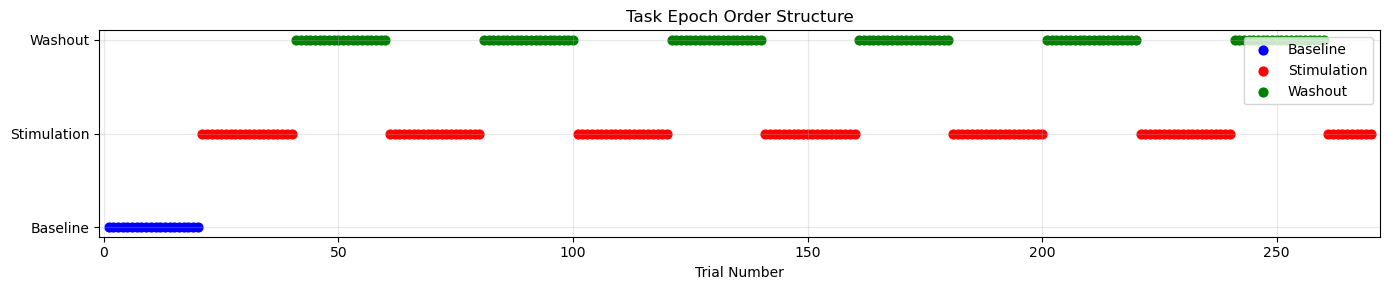

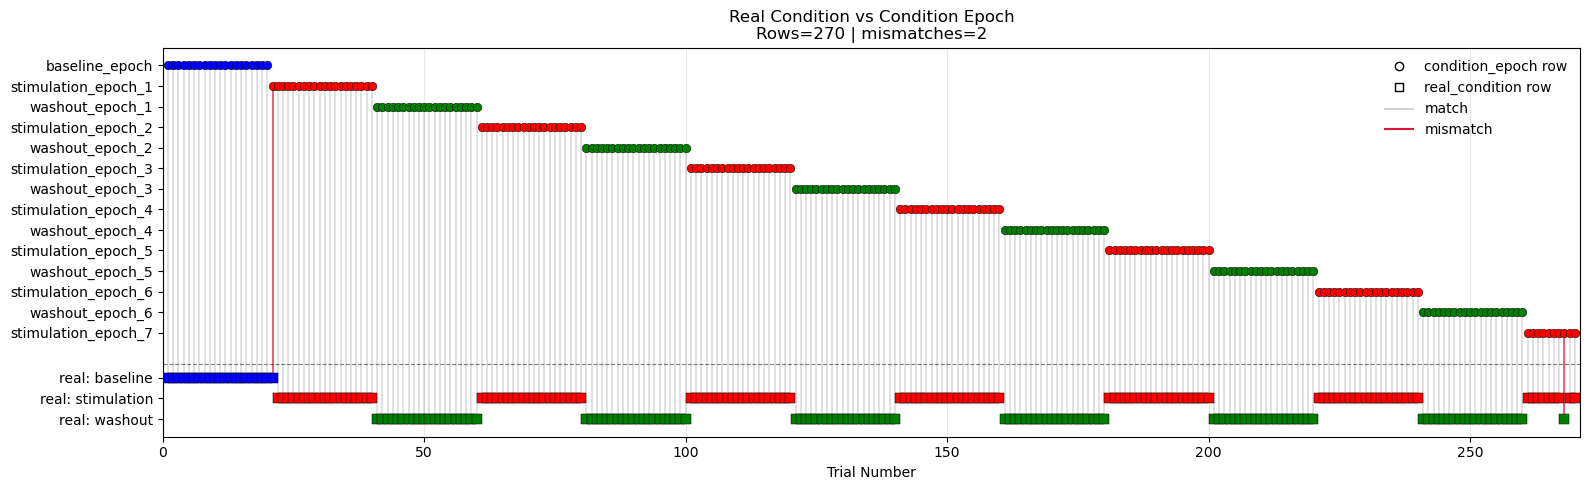

Real condition vs condition epoch plot saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\real_condition_vs_condition_epoch.png


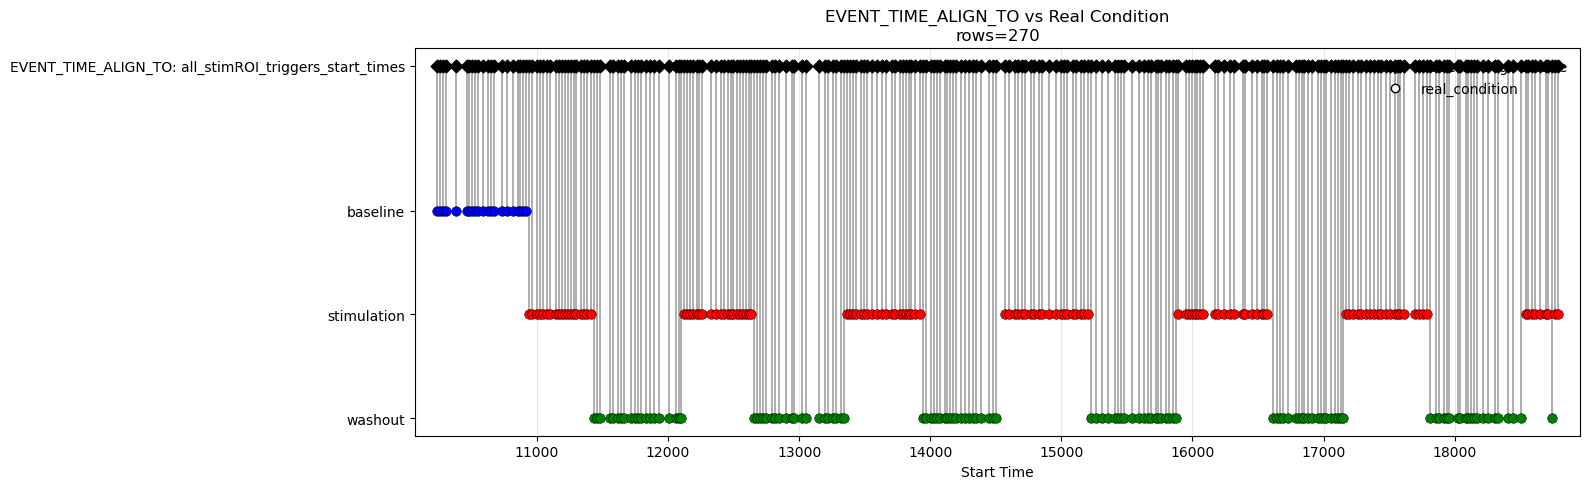

EVENT_TIME_ALIGN_TO vs real_condition plot saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\event_time_align_to_vs_real_condition.png


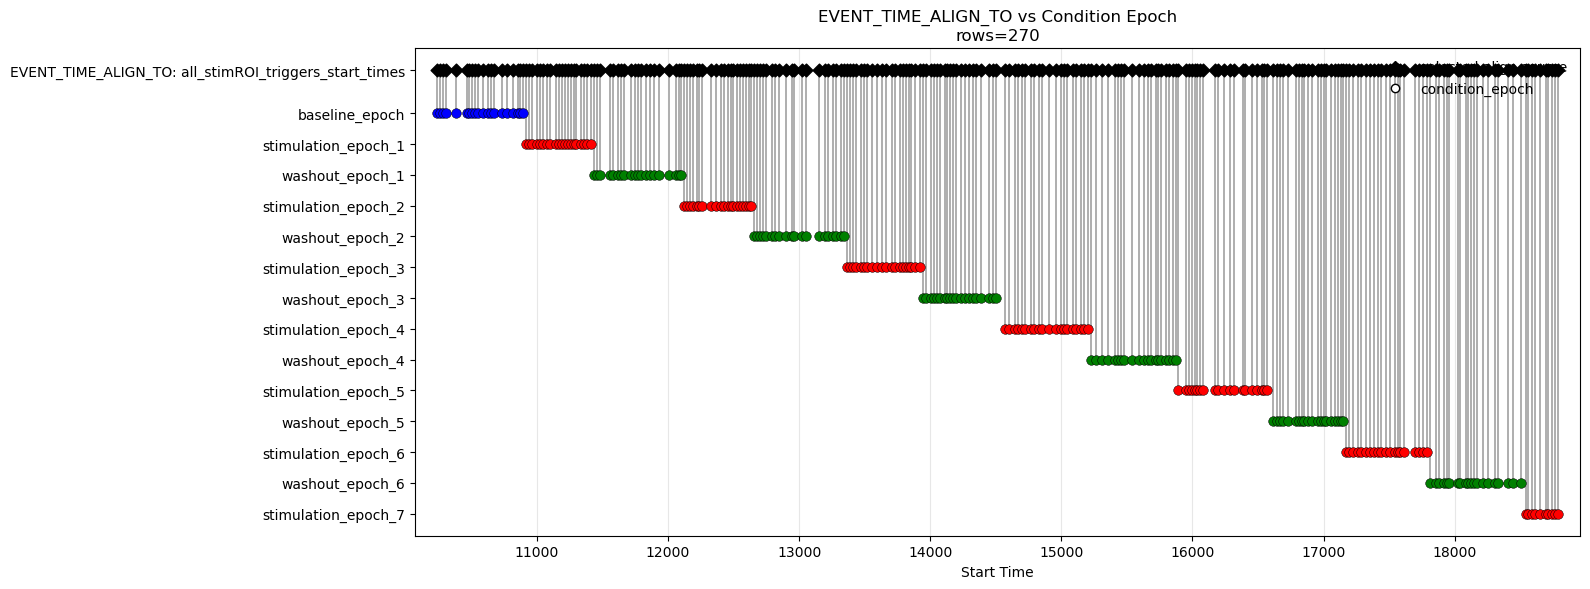

EVENT_TIME_ALIGN_TO vs condition_epoch plot saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\event_time_align_to_vs_condition_epoch.png
Aligned pca_event_meta saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\processed_data\pca_event_meta_aligned_all_stimROI_triggers_start_times.pkl


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,real_condition,real_epoch_id,real_condition_epoch,real_condition_source,real_condition_matched,start_time_source,start_time_align_method,start_time_align_abs_delta_s
0,0,1,10239.893300,baseline,0,baseline_epoch,baseline,0,baseline_epoch,original_condition,False,all_stimROI_triggers_start_times,index,0.0
1,1,2,10263.343867,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
2,2,3,10285.494367,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
3,3,4,10306.931567,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
4,4,5,10383.171333,baseline,0,baseline_epoch,baseline,0,baseline_epoch,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False,all_stimROI_triggers_start_times,index,0.0
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False,all_stimROI_triggers_start_times,index,0.0
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7,washout,7,washout_epoch_7,reachInit_stimROI_real_start_times,True,all_stimROI_triggers_start_times,index,0.0
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7,stimulation,7,stimulation_epoch_7,original_condition,False,all_stimROI_triggers_start_times,index,0.0


In [26]:
NP_ROOT_DIR = paths_dic['NP_ROOT_DIR']
verify.plot_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_are_one_based=True,
    figsize=(14, 3),
)

plot_real_condition_vs_condition_epoch_path = paths_dic['NP_ROOT_DIR'] / "real_condition_vs_condition_epoch.png"
verify.plot_real_condition_vs_condition_epoch(
    pca_event_meta_aligned,
    figsize=(16, 5),
    save_plot_path=plot_real_condition_vs_condition_epoch_path,
)
print("Real condition vs condition epoch plot saved to:", plot_real_condition_vs_condition_epoch_path)

plot_event_time_align_to_vs_real_condition_path = paths_dic['NP_ROOT_DIR'] / "event_time_align_to_vs_real_condition.png"
verify.plot_event_time_align_to_vs_real_condition(
    pca_event_meta_aligned,
    align_to=EVENT_TIME_ALIGN_TO,
    figsize=(16, 5),
    save_plot_path=plot_event_time_align_to_vs_real_condition_path,
)
print("EVENT_TIME_ALIGN_TO vs real_condition plot saved to:", plot_event_time_align_to_vs_real_condition_path)

plot_event_time_align_to_vs_condition_epoch_path = paths_dic['NP_ROOT_DIR'] / "event_time_align_to_vs_condition_epoch.png"
verify.plot_event_time_align_to_vs_condition_epoch(
    pca_event_meta_aligned,
    align_to=EVENT_TIME_ALIGN_TO,
    figsize=(16, 6),
    save_plot_path=plot_event_time_align_to_vs_condition_epoch_path,
)
print("EVENT_TIME_ALIGN_TO vs condition_epoch plot saved to:", plot_event_time_align_to_vs_condition_epoch_path)

DATA_SAVE_PATH = paths_dic['NP_ROOT_DIR'] / "processed_data"
DATA_SAVE_PATH.mkdir(parents=True, exist_ok=True)
# save out pca_event_meta
(pca_event_meta_aligned).to_pickle(DATA_SAVE_PATH / f"pca_event_meta_aligned_{EVENT_TIME_ALIGN_TO}.pkl")
print("Aligned pca_event_meta saved to:", DATA_SAVE_PATH / f"pca_event_meta_aligned_{EVENT_TIME_ALIGN_TO}.pkl")
display(pca_event_meta_aligned)

# # save out df_verify
# df_verify.to_csv(DATA_SAVE_PATH / f"df_verify_post_filtering.csv")
# print("df_verify saved to:", DATA_SAVE_PATH / f"df_verify_post_filtering.csv")
# display(df_verify)

### Create the reachInit (stimulation, washout, and baseline lists of start_times)

In [27]:
reach_Init_from_StimROI_with_STIM = stimulation_reachInit_stimROI_start_times
reach_Init_from_StimROI_without_STIM = washout_reachInit_stimROI_start_times
reach_Init_baseline = baseline_reachInit_stimROI_start_times
all_reach_Init_from_StimROI = np.concatenate([reach_Init_from_StimROI_with_STIM, reach_Init_from_StimROI_without_STIM, reach_Init_baseline])
all_reach_Init_from_StimROI = np.sort(all_reach_Init_from_StimROI)

all_reach_Init_from_StimROI,reach_Init_baseline,reach_Init_from_StimROI_with_STIM,reach_Init_from_StimROI_without_STIM
print(f'total reach_Init_from_StimROI_with_STIM: {len(reach_Init_from_StimROI_with_STIM)}')
print(f'total reach_Init_from_StimROI_without_STIM: {len(reach_Init_from_StimROI_without_STIM)}')
print(f'total reach_Init_baseline: {len(reach_Init_baseline)}')
print(f'total all_reach_Init_from_StimROI: {len(all_reach_Init_from_StimROI)}')

total reach_Init_from_StimROI_with_STIM: 130
total reach_Init_from_StimROI_without_STIM: 120
total reach_Init_baseline: 20
total all_reach_Init_from_StimROI: 270


### Check the tones and the stimROI timestamps


They are both seprarated by from the sinlge array of opticla timestamps that occured during the entire opne-ephys recording session


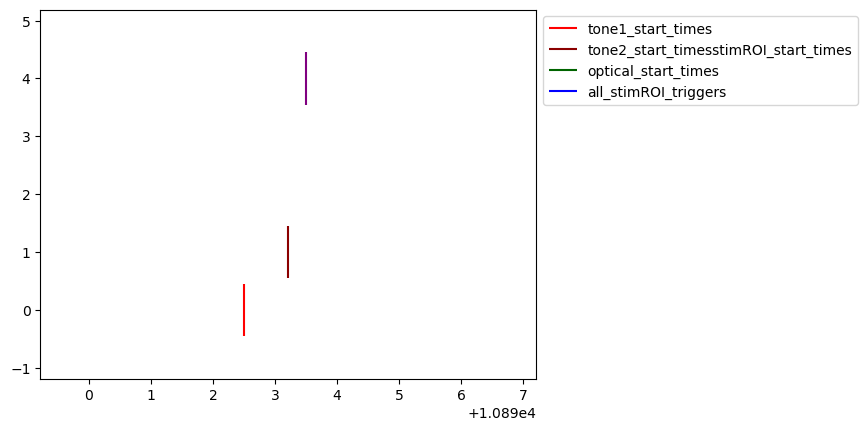

They are both seprarated by from the sinlge array of opticla timestamps that occured during the entire opne-ephys recording session


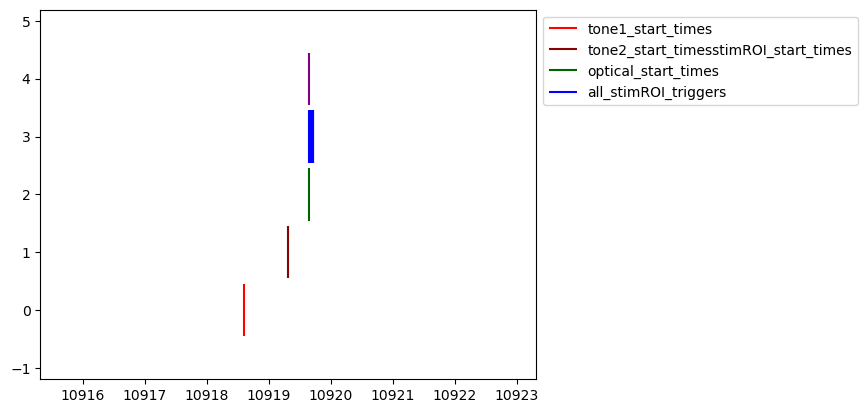

In [28]:
reach_number = 19
plt.eventplot([tone1_start_times,tone2_start_times,stimROI_start_times,optical_start_times,all_stimROI_triggers_start_times], orientation='horizontal', colors=['r','darkred','darkgreen','b','purple'], linelengths=0.9)
plt.xlim(tone2_start_times[reach_number]-4, tone2_start_times[reach_number]+4)

plt.legend(['tone1_start_times', 'tone2_start_times' 'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers'], 
           loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plotprint('The green lines represents the closed loop optical timestamps, while the blue line represents the opto tagging timestamps')
print('They are both seprarated by from the sinlge array of opticla timestamps that occured during the entire opne-ephys recording session')
plt.show()

reach_number = 20
plt.eventplot([tone1_start_times,tone2_start_times,stimROI_start_times,optical_start_times,all_stimROI_triggers_start_times], orientation='horizontal', colors=['r','darkred','darkgreen','b','purple'], linelengths=0.9)
plt.xlim(tone2_start_times[reach_number]-4, tone2_start_times[reach_number]+4)

plt.legend(['tone1_start_times', 'tone2_start_times' 'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers'], 
           loc='upper left', bbox_to_anchor=(1, 1))  # Moves the legend outside the plotprint('The green lines represents the closed loop optical timestamps, while the blue line represents the opto tagging timestamps')
print('They are both seprarated by from the sinlge array of opticla timestamps that occured during the entire opne-ephys recording session')
plt.show()

### This plot shows the entire duration of the recording 
- and only plots the optical time opto_tag_start_timestamps
- the optical timestamps that happened during the closed loop portion are shown in green
- the optical timestamps that happened during the opto tagging portion are shown in blue

The green lines represents the closed loop optical timestamps, while the blue line represents the opto tagging timestamps
They are both seprarated by from the sinlge array of opticla timestamps that occured during the entire opne-ephys recording session


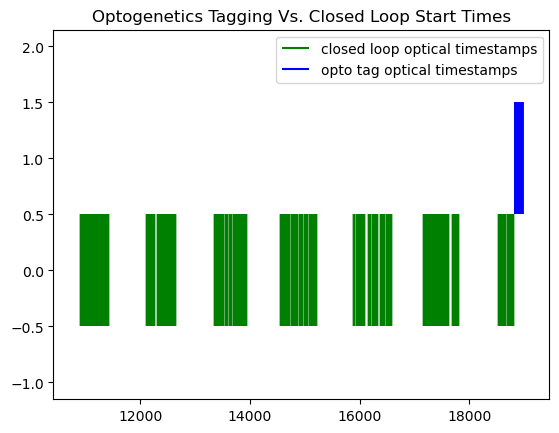

In [29]:

plt.eventplot([opto_closed_loop_start_timestamps,opto_tag_start_timestamps], orientation='horizontal', colors=['g','b'])
plt.xlim(opto_closed_loop_start_timestamps[0]-500, opto_tag_start_timestamps[-1]+500)
plt.legend(['closed loop optical timestamps','opto tag optical timestamps'])
plt.title('Optogenetics Tagging Vs. Closed Loop Start Times')
print('The green lines represents the closed loop optical timestamps, while the blue line represents the opto tagging timestamps')
print('They are both seprarated by from the sinlge array of opticla timestamps that occured during the entire opne-ephys recording session')
plt.show()

### The blue lines represents all the opto tagging timestamps for the entire recording
- this means this is the end of the recording
- and should be about 2 minutes in total duration

The blue lines represents the opto tagging timestamps only, this means this is the end of the recording


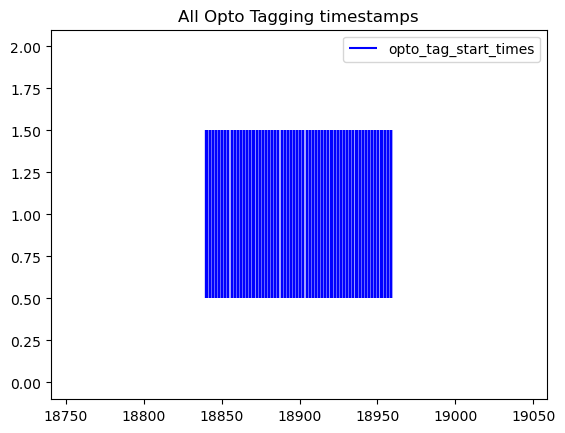

In [30]:
plt.eventplot([opto_tag_start_timestamps], orientation='horizontal', colors=['b'])
plt.xlim(opto_tag_start_timestamps[0]-100, opto_tag_start_timestamps[-1]+100)
plt.legend(['opto_tag_start_times'])
plt.title('All Opto Tagging timestamps')
print('The blue lines represents the opto tagging timestamps only, this means this is the end of the recording')
plt.show()


#### This plot shows one single opto-tagging event
- meaning every time the opto-tagging was turned on, this is the plot that shows the start and end of one sinlg opto-tagging event
- there should be 20 optical timestamps seen in the plot

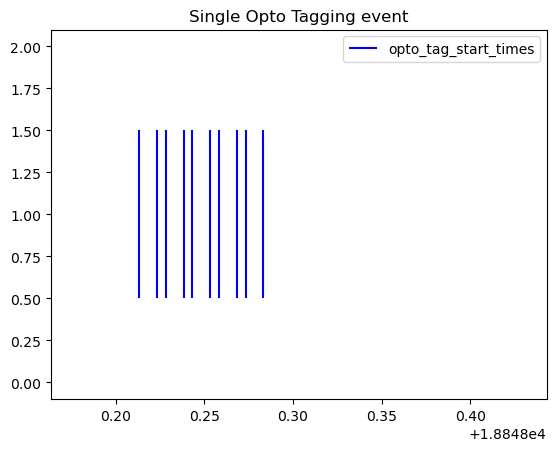

In [31]:
plt.eventplot([opto_tag_start_timestamps], orientation='horizontal', colors=['b'])
plt.xlim(opto_tag_start_timestamps[40]-0.05, opto_tag_start_timestamps[40]+0.23)
plt.legend(['opto_tag_start_times'])
plt.title('Single Opto Tagging event')
plt.show()

### This plot shows two opto-tagging events
- they should each have 20 pulses, and be seperated by somne amount of time (usually 1-2 second)

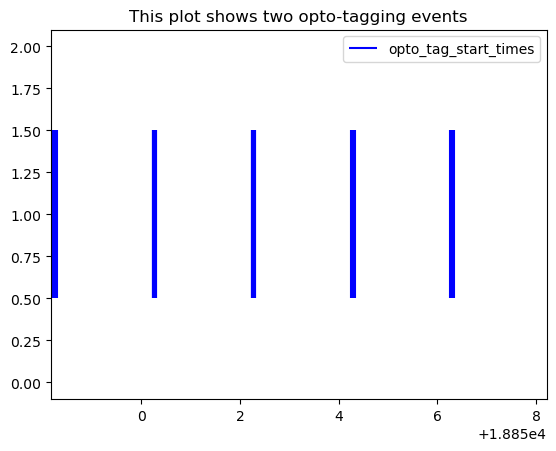

In [32]:
plt.eventplot([opto_tag_start_timestamps], orientation='horizontal', colors=['b'])
plt.xlim(opto_tag_start_timestamps[40]-0.05, opto_tag_start_timestamps[40]+10)
plt.legend(['opto_tag_start_times'])
plt.title('This plot shows two opto-tagging events')
plt.show()

#### This plot is to check that first_opto_tagging_timestamp_per_trial is actually extracting the first timestamp for each trial
- the blue line represents the first opto tagging timestamp for each trial
- the green line represents the remanining opto-tag optical timestamps
- it should have one blue line, followed by a block of green lines, then another blue line and so on

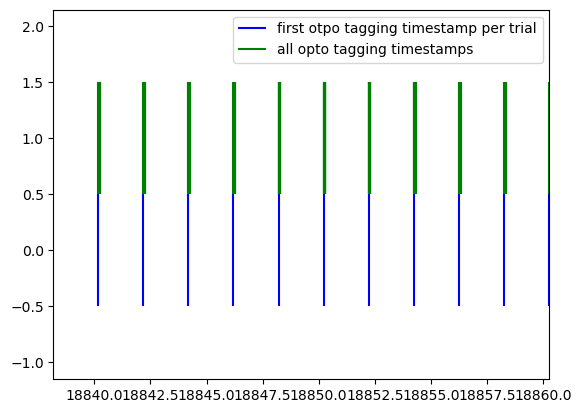

In [33]:

plt.eventplot([first_opto_tagging_timestamp_per_trial,opto_tag_start_timestamps], orientation='horizontal', colors=['b','g'])
plt.xlim(first_opto_tagging_timestamp_per_trial[0]-2, first_opto_tagging_timestamp_per_trial[10])
plt.legend(['first otpo tagging timestamp per trial', 'all opto tagging timestamps'])
plt.show()


### This plot checks the first optical pulse for the closed loop opto
- the first optical pulse for closed loop opto should be blue, followed by 9 green lines
- the two plots are the first and last closed loop events in the recording

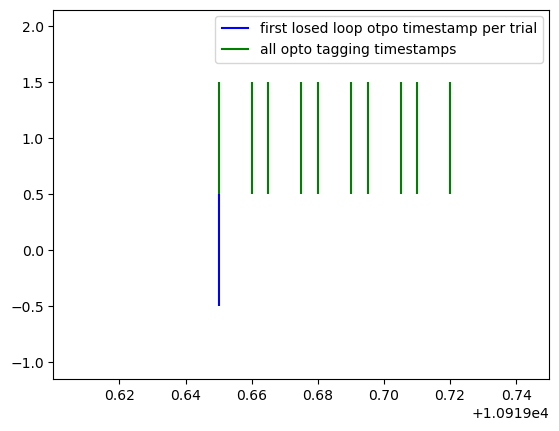

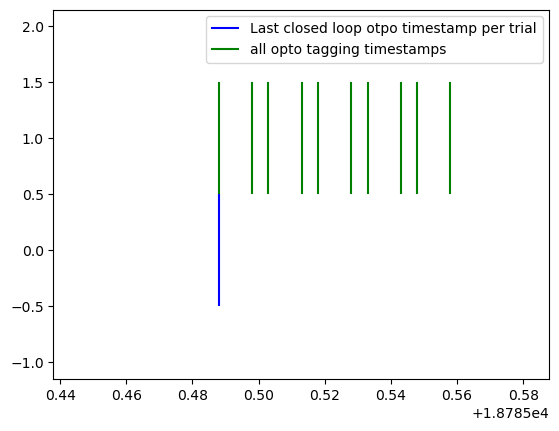

In [34]:

plt.eventplot([first_optical_pulse_per_closed_loop,optical_start_times], orientation='horizontal', colors=['b','g'])
plt.xlim(first_optical_pulse_per_closed_loop[0]-0.05, first_optical_pulse_per_closed_loop[0]+0.1)
plt.legend(['first losed loop otpo timestamp per trial', 'all opto tagging timestamps'])
plt.show()

plt.eventplot([first_optical_pulse_per_closed_loop,optical_start_times], orientation='horizontal', colors=['b','g'])
plt.xlim(first_optical_pulse_per_closed_loop[-1]-0.05, first_optical_pulse_per_closed_loop[-1]+0.1)
plt.legend(['Last closed loop otpo timestamp per trial', 'all opto tagging timestamps'])
plt.show()

#### This plot is to check that first_opto_tagging_timestamp_per_trial is actually extracting the first timestamp for each trial
- the blue line represents the first opto tagging timestamp for each trial 
- the green line represents the remanining opto-tag optical timestamps
- it should have one blue line, followed by a block of green lines, then another blue line and so on
- this is a zoomed in version of the plot aobve for the first opto-tag event, and the last opto-tag event

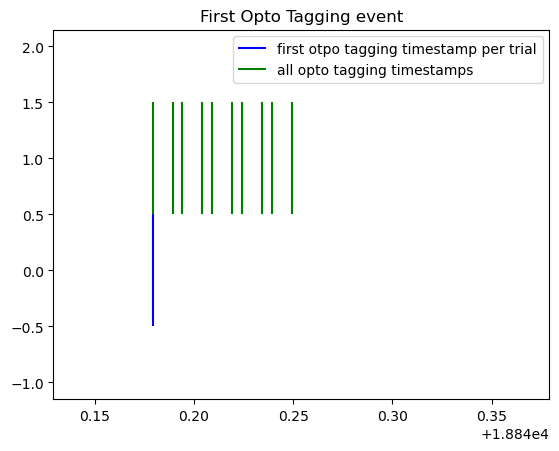

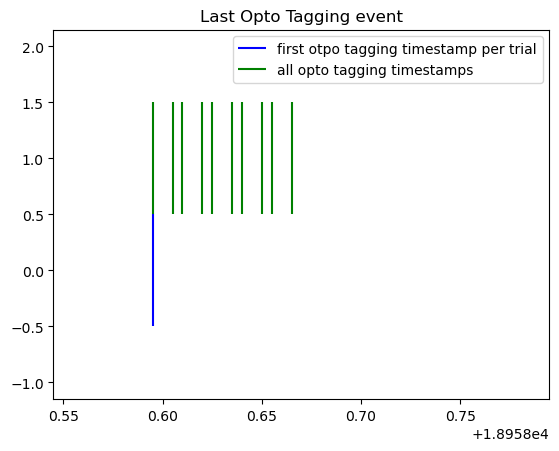

In [35]:
plt.eventplot([first_opto_tagging_timestamp_per_trial,opto_tag_start_timestamps], orientation='horizontal', colors=['b','g'])
plt.xlim(first_opto_tagging_timestamp_per_trial[0]-0.05, first_opto_tagging_timestamp_per_trial[0]+0.20)
plt.legend(['first otpo tagging timestamp per trial', 'all opto tagging timestamps'])
plt.title('First Opto Tagging event')
plt.show()


plt.eventplot([first_opto_tagging_timestamp_per_trial,opto_tag_start_timestamps], orientation='horizontal', colors=['b','g'])
plt.xlim(first_opto_tagging_timestamp_per_trial[-1]-0.05, first_opto_tagging_timestamp_per_trial[-1]+0.20)
plt.legend(['first otpo tagging timestamp per trial', 'all opto tagging timestamps'])
plt.title('Last Opto Tagging event')
plt.show()

### Look at the structure of reachInits 

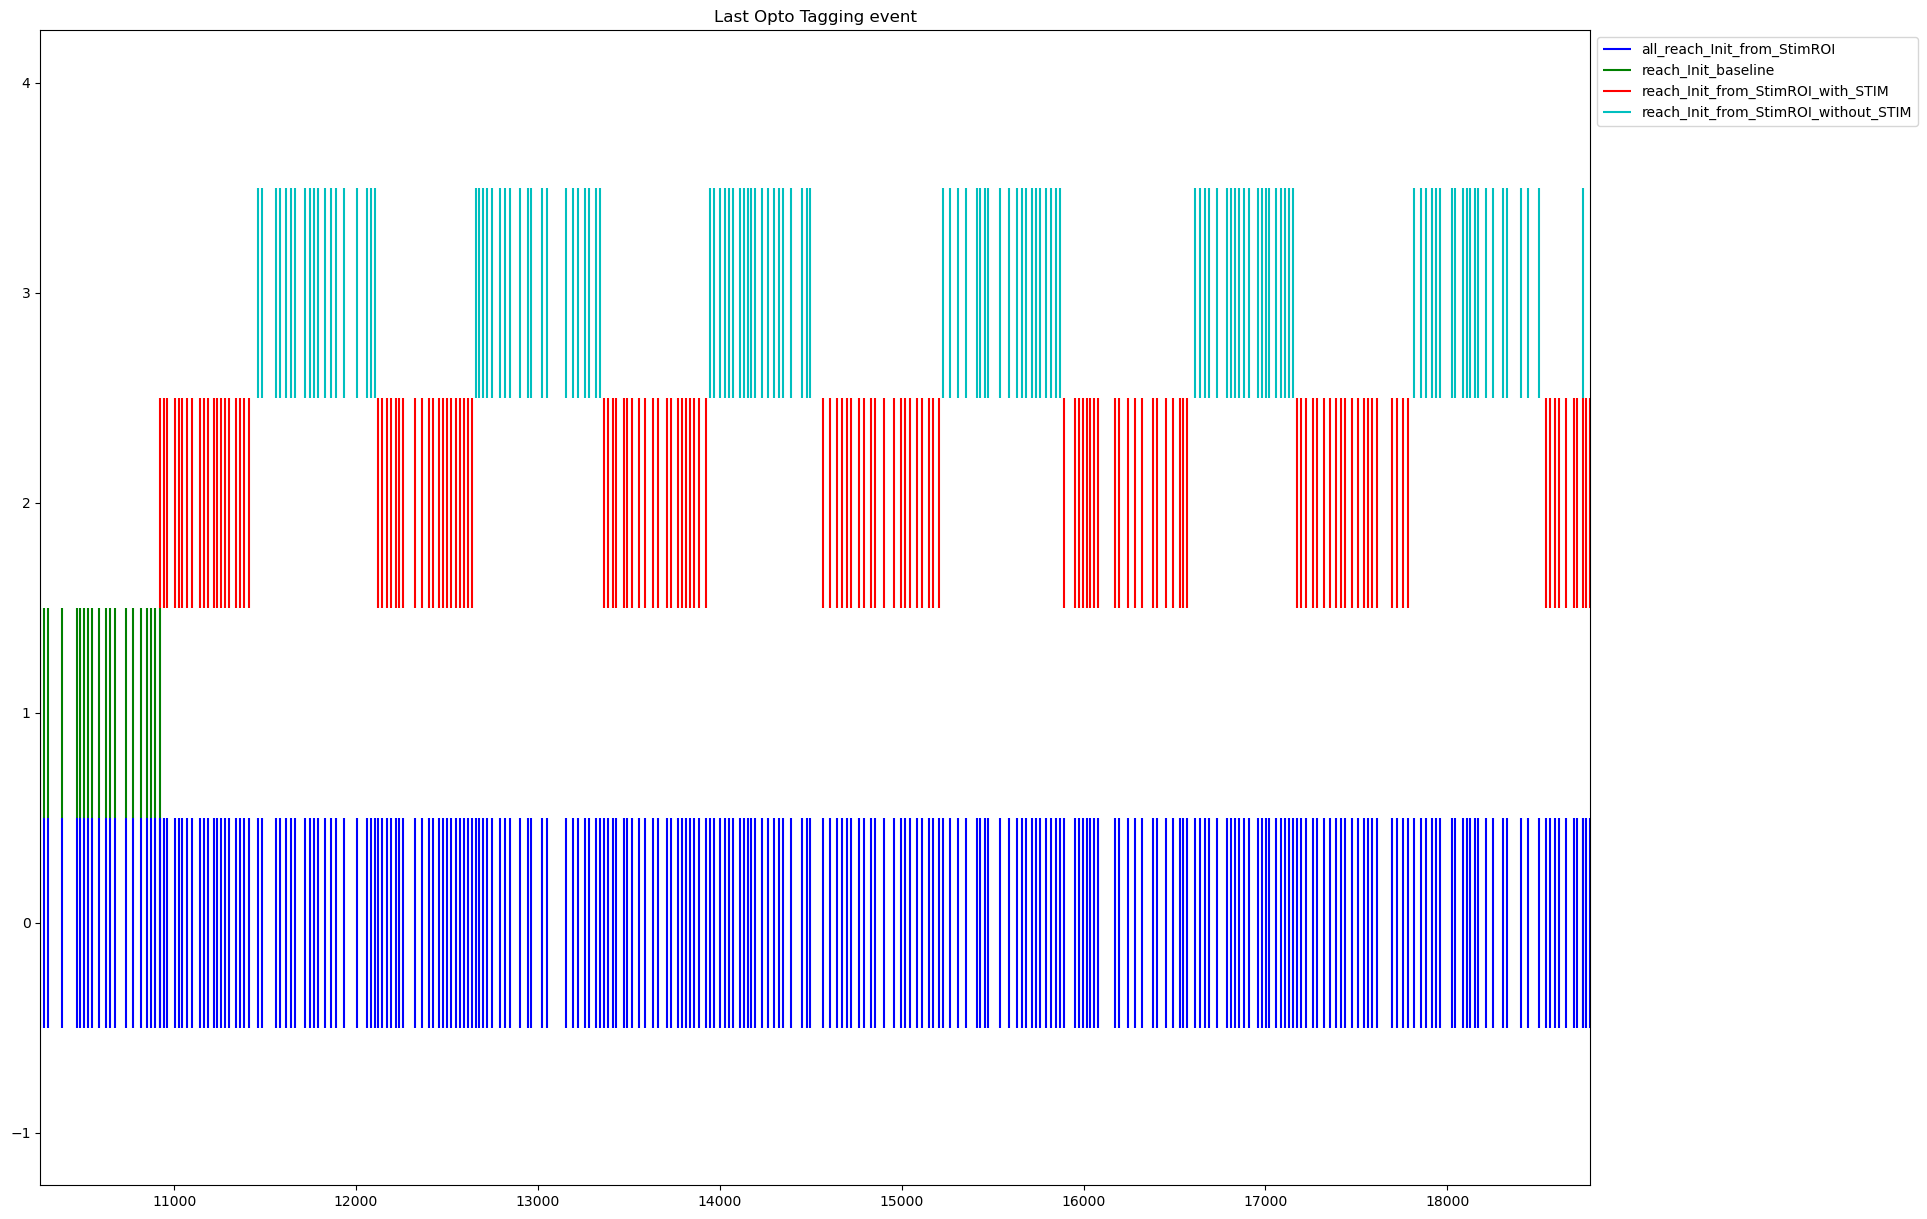

In [36]:
all_reach_Init_from_StimROI,reach_Init_baseline,reach_Init_from_StimROI_with_STIM,reach_Init_from_StimROI_without_STIM


plt.eventplot([all_reach_Init_from_StimROI,reach_Init_baseline,reach_Init_from_StimROI_with_STIM,reach_Init_from_StimROI_without_STIM], orientation='horizontal', colors=['b','g','r','c'])
plt.xlim(all_reach_Init_from_StimROI[0], all_reach_Init_from_StimROI[-1])
plt.gcf().set_size_inches(20,15)
# Add legend off to right side of the plot
plt.legend(['all_reach_Init_from_StimROI', 'reach_Init_baseline', 'reach_Init_from_StimROI_with_STIM', 'reach_Init_from_StimROI_without_STIM'], loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Last Opto Tagging event')
plt.savefig(paths_dic['NP_ROOT_DIR'] / "reach_Init_from_StimROI_with_and_without_STIM.png", bbox_inches='tight')
plt.show()

## Compare the old df1 to the new df1 from merged_dic

In [37]:
df1 = df_units[df_units.probe == 'B']
df1

,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
554,554,6960.0,59.0,40.0,1,1,12.3,89.3,B,IN_ROI,PG,MUA,"[9938.120278208322, 9938.182216212743, 9938.21..."
555,555,6980.0,43.0,20.0,2,2,11.5,5.1,B,IN_ROI,PG,MUA,"[9938.444535996017, 9939.917013711796, 9958.09..."
556,556,6980.0,11.0,20.0,1,1,9.5,43.4,B,IN_ROI,PG,NOISE,"[9939.385306945673, 9940.727441498186, 9957.55..."
557,557,6980.0,11.0,20.0,0,1,9.4,59.0,B,IN_ROI,PG,MUA,"[9944.501338606167, 9966.249336973879, 9966.80..."
558,558,6960.0,59.0,40.0,0,2,21.5,2.2,B,IN_ROI,PG,GOOD,"[10383.125186256175, 10510.258669273911, 10648..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1865,1865,3400.0,27.0,3600.0,0,2,9.8,6.6,B,OUT_ROI,None,MUA,"[9939.55862001632, 9941.75341887385, 9942.1074..."
1866,1866,3400.0,27.0,3600.0,0,2,9.0,0.0,B,OUT_ROI,None,MUA,"[9938.087975772156, 9938.301025172865, 9938.73..."
1867,1867,3400.0,27.0,3600.0,0,1,9.2,54.5,B,OUT_ROI,None,NON-SOMA,"[9963.542866184409, 9966.149929476538, 10066.8..."
1868,1868,3400.0,27.0,3600.0,0,2,26.3,0.0,B,OUT_ROI,None,MUA,"[9938.282523777583, 9938.563945001395, 9938.79..."


In [38]:
df1_merged_dic = merged_dic['B']
df1_merged_dic[0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,in_brainRegion,brain_region,bc_unitType,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label
0,6960.0,59.0,40.0,1,1,12.3,89.3,B,IN_ROI,PG,MUA,"[9938.120278208322, 9938.182216212743, 9938.21...",0,342314.0,11.119194,2,MUA
1,6980.0,43.0,20.0,2,2,11.5,5.1,B,IN_ROI,PG,MUA,"[9938.444535996017, 9939.917013711796, 9958.09...",1,93291.0,25.348637,0,MUA
2,6980.0,11.0,20.0,1,1,9.5,43.4,B,IN_ROI,PG,NOISE,"[9939.385306945673, 9940.727441498186, 9957.55...",2,21451.0,9.852627,1,NOISE


In [39]:
df_units

,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
0,0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,NOISE,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,NOISE,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,NOISE,"[9938.29451763671, 9938.519134975282, 9938.609..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,4595,860.0,43.0,3740.0,0,1,10.2,175.3,F,OUT_ROI,None,NON-SOMA,"[9939.57044788735, 9939.597083318817, 9939.703..."
4596,4596,1020.0,43.0,3580.0,0,2,19.5,0.0,F,OUT_ROI,None,NOISE,"[10919.660133182651, 10919.6751343645, 10919.7..."
4597,4597,1060.0,11.0,3540.0,0,1,9.6,236.7,F,OUT_ROI,None,NOISE,"[9996.778036617923, 10049.712567383913, 10050...."
4598,4598,980.0,43.0,3620.0,0,2,26.1,0.0,F,OUT_ROI,None,NON-SOMA,"[10919.650099059141, 10919.665100240469, 10919..."


# Simple raster 
- This raster plot is working.(no other raster plots are currently working lol)
- it has different logic than all other raster plots so far...


C:\Users\user\AppData\Local\Temp\ipykernel_35780\3676984618.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


array([<Axes: title={'center': 'PSTH - 6 - IP'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
       <Axes: >], dtype=object)

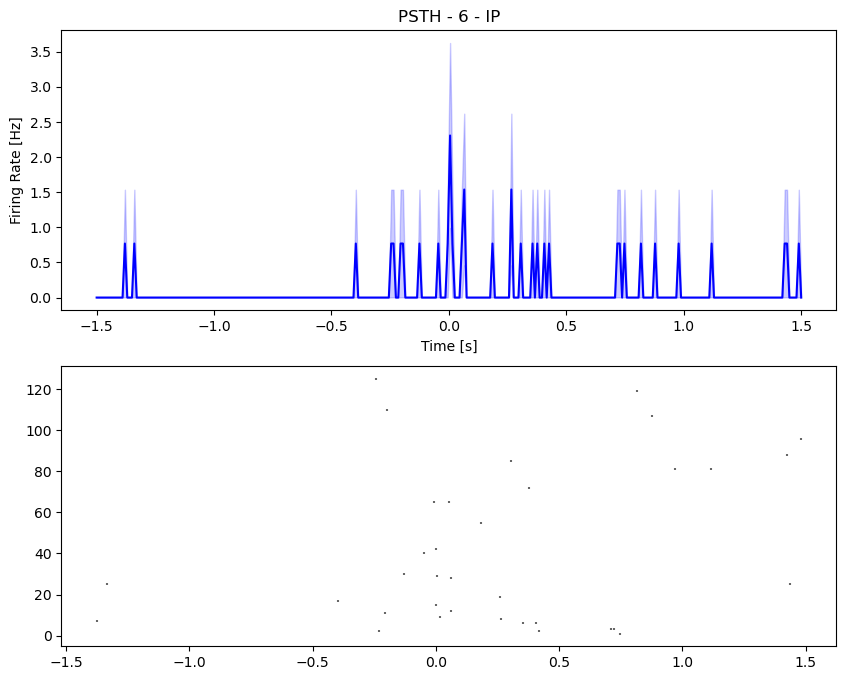

In [40]:

unit_idx = 4
pre = 1.5
post = 1.5
probeLetter = 'A'
df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
brain_region = df1.Brain_Region.values[unit_idx]
spike_times = df1.spike_times.values[unit_idx]
event_times = stimROI_start_times
unit_id = df1.index[unit_idx]
# plot_func.singleUnit_psth_raster_test(spike_times=spike_times, event_times=event_times,unit_id=unit_id, pre=pre, post=post, bin_size=0.01)
plot_func.singleUnit_psth_raster_test(spike_times=spike_times, event_times=event_times,unit_id=unit_id, pre=pre, post=post, bin_size=0.01,brain_region=brain_region)

C:\Users\user\AppData\Local\Temp\ipykernel_35780\3086557124.py:49: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


array([<Axes: title={'center': 'PSTH - 4 - IP'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
       <Axes: >], dtype=object)

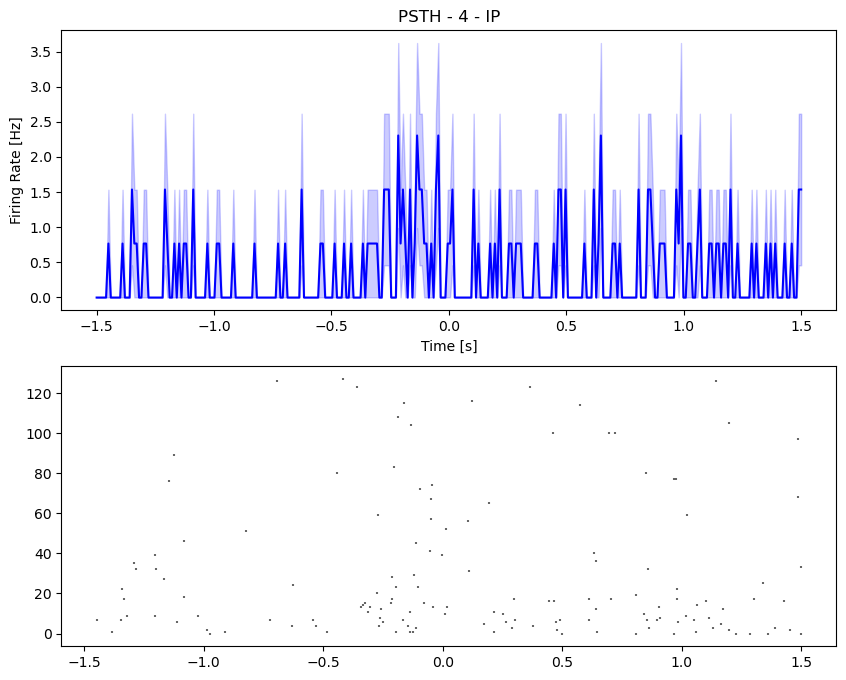

In [41]:


def singleUnit_psth_raster_test(spike_times, event_times,unit_id, pre, post, bin_size=0.01,brain_region=None):
    fig, ax = plt.subplots(2,1)  # Initialize the plot
    fig.set_size_inches(10, 8)  # Set the figure size

    psth,var,edges,bytrial = plot_func.trial_by_trial(spike_times, event_times, pre, post, bin_size)

    mean_baseline = bytrial[:,:int(pre/bin_size)].mean()
    std_baseline  = bytrial[:,:int(pre/bin_size)].std()
    zMean         = (bytrial[:,int(pre/bin_size):].mean(axis=1) - mean_baseline)/std_baseline

    # mean_response = bytrial[:,int(pre/bin_size):].mean()
    # std_response  = bytrial[:,int(pre/bin_size):].std()

    n_bins = len(psth)
    ax[0].plot(edges,psth-mean_baseline,color='b')
    # ax.set_xticks(np.linspace(0,n_bins,6),np.round(np.linspace(-pre,post,6),1))
    # ax.fill_between(np.arange(0,n_bins),psth+var-mean_baseline,psth-var-mean_baseline,alpha=0.2,color='b')
    ax[0].fill_between(edges,psth+var-mean_baseline,psth-var-mean_baseline,alpha=0.2,color='b')

    ax[0].set_ylabel('Firing Rate [Hz]')
    ax[0].set_xlabel('Time [s]')
    ax[0].set_title(f'PSTH - {unit_id} - {brain_region}')


    for t, time in enumerate(event_times):
        trial_spikes = spike_times[(spike_times > time-pre) & (spike_times < time+post)]
        trial_spikes = trial_spikes - time
        # print(f'trial_spikes: {trial_spikes[0:5]}')
        # print(f'time-post: {time-post}')
        # print(f'time+post: {time+post}')

        ax[1].scatter(trial_spikes,
                [t] * len(trial_spikes),  # Use `t` as the y-value for each trial
                marker='|',
                color='black',
                s=1,
                alpha=0.6)

    return ax



# df1 = merged_dic[probeLetter]

unit_idx = 3
pre = 1.5
post = 1.5
probeLetter = 'A'
df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
brain_region = df1.Brain_Region.values[unit_idx]
spike_times = df1.spike_times.values[unit_idx]
event_times = stimROI_start_times
unit_id = df1.index[unit_idx]

singleUnit_psth_raster_test(spike_times=spike_times, event_times=event_times,unit_id=unit_id, pre=pre, post=post, bin_size=0.01, brain_region=brain_region)


#### Uses the above function to plot the results of the first optical pulse for every opto-tagging pulse
- each opto-tag event should have 20 optical pulses in it
- first_opto_tagging_timestamp_per_trial extracted out the first optical pulse of each block of 20 optical pulses 

C:\Users\user\AppData\Local\Temp\ipykernel_35780\3843114769.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


array([<Axes: title={'center': 'PSTH - 15 - IP'}, xlabel='Time [s]', ylabel='Firing Rate [Hz]'>,
       <Axes: >], dtype=object)

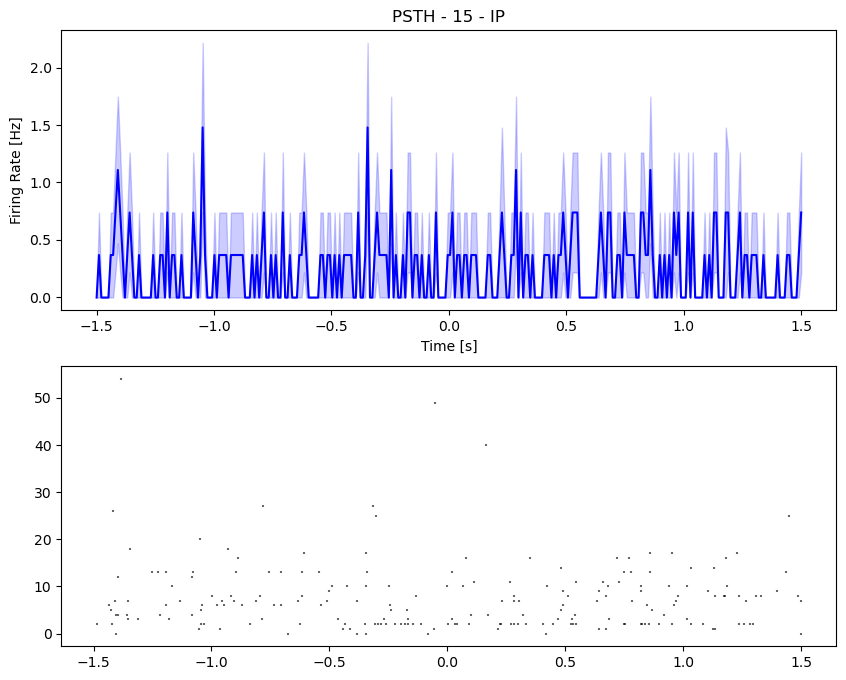

In [42]:
# Options for the event_times. can change it to one of these options related to the opto tagging timestamps, or closed loop opto timestamps
opto_tag_start_timestamps
opto_closed_loop_start_timestamps
first_opto_tagging_timestamp_per_trial

unit_idx = 10
pre = 1.5
post = 1.5
probeLetter = 'A'
# df1 = merged_dic[probeLetter]
df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
brain_region = df1.Brain_Region.values[unit_idx]
spike_times = df1.spike_times.values[unit_idx]
unit_id = df1.index[unit_idx]
event_times = all_stimROI_triggers_start_times
singleUnit_psth_raster_test(spike_times=spike_times, event_times=event_times,unit_id=unit_id, pre=pre, post=post, bin_size=0.01, brain_region=brain_region)



In [43]:
import matplotlib.pyplot as plt
import os

def allUnits_psth_raster_2(df_units, df_stim, brain_region=None,title_name='Not Set', event_times=None, label=False, KSlabel=False,all_units=True, dot_size=0.5, pre=0.5, post=1, bin_size=0.05, epoch1='pellet_delivery_timestamp', probeLetter=None ,save_dir=None):
    # Select units based on the label or KSlabel
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel')  
    if all_units:
        df1 = df_units[df_units.probe == probeLetter]

    unit_index = df1.index.tolist()
    brain_region = brain_region

    # Loop through each unit
    for unit in unit_index:
        # Create a figure for each unit
        fig, ax = plt.subplots(2, 1, figsize=(10, 15))
        fig.suptitle(f"{title_name} \n unit {unit}, probe {probeLetter} in {brain_region}", color='black')

        # Retrieve spike times for the unit
        spike_times = df1[df1.index == unit].spike_times.values[0]

        # Compute the PSTH and plot it
        psth, var, edges, bytrial = plot_func.trial_by_trial(spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size, brain_region=brain_region)

        # PSTH plot
        mean_baseline = bytrial[:, :int(pre/bin_size)].mean()
        ax[0].plot(edges, psth - mean_baseline, color='b')
        ax[0].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color='b')
        ax[0].set_ylabel('Firing Rate [Hz]')
        ax[0].set_xlabel('Time [s]')
        ax[0].set_title('PSTH')

        # Raster plot
        for t, time in enumerate(event_times):
            trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
            trial_spikes = trial_spikes - time
            ax[1].scatter(trial_spikes, [t] * len(trial_spikes), marker='|', color='black', s=1, alpha=0.6)

        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")
        

        # Ensure save_dir exists
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Save the figure
        fig_filename = rf"{save_dir}\unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free up memory



In [44]:

# main variables to set
probe_letters = ['A', 'B','C', 'D', 'E','F']# Iterate over probes and event times
for probeLetter in probe_letters:
    df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
    unique_brain_regions = df1.Brain_Region.unique()
    # drp nan values from unique_brain_regions
    unique_brain_regions = unique_brain_regions[~pd.isnull(unique_brain_regions)]
    # Drop all 'nan' and 'None' from unique_brain_regions
    unique_brain_regions = [br for br in unique_brain_regions if pd.notna(br) and br != 'None']
    unique_brain_regions = [br for br in unique_brain_regions if pd.notna(br) and br != 'nan']

    print(f'Unique brain regions for probe {probeLetter}: {unique_brain_regions}\n')

Unique brain regions for probe A: ['IP', 'SIM']

Unique brain regions for probe B: ['PG']

Unique brain regions for probe C: ['MoP']

Unique brain regions for probe D: ['VaL']

Unique brain regions for probe E: ['SnR']

Unique brain regions for probe F: ['RN']



C:\Users\user\AppData\Local\Temp\ipykernel_35780\1185849069.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


In [45]:
stimulation_reachInit_stimROI_start_times,stimROI_start_times

missMatch_count = 0
aligned_count = 0
# Compare the stimulation_reachInit_stimROI_start_times and stimROI_start_times to verify they are identical
for i in range(min(len(stimulation_reachInit_stimROI_start_times), len(stimROI_start_times))):
    if stimulation_reachInit_stimROI_start_times[i] != stimROI_start_times[i]:
        print(f"Mismatch at index {i}: stimulation_reachInit_stimROI_start_times[{i}] = {stimulation_reachInit_stimROI_start_times[i]} does not match stimROI_start_times[{i}] = {stimROI_start_times[i]}")
        missMatch_count += 1
    else:
        aligned_count += 1
    if aligned_count == len(stimulation_reachInit_stimROI_start_times):
        print("All timestamps are perfectly aligned between stimulation_reachInit_stimROI_start_times and stimROI_start_times.")
print(f"Total mismatches: {missMatch_count}")


print('\n')
all_reachInit_stimROI_start_times_merged = np.concatenate([baseline_reachInit_stimROI_start_times, stimulation_reachInit_stimROI_start_times, washout_reachInit_stimROI_start_times])
missMatch_count = 0
aligned_count = 0
# Compare the all_stimROI_triggers_start_times and all_stimROI_triggers_start_times to verify they are identical
for i in range(min(len(all_stimROI_triggers_start_times), len(all_stimROI_triggers_start_times))):
    if all_stimROI_triggers_start_times[i] != all_stimROI_triggers_start_times[i]:
        print(f"Mismatch at index {i}: all_stimROI_triggers_start_times[{i}] = {all_stimROI_triggers_start_times[i]} does not match all_stimROI_triggers_start_times[{i}] = {all_stimROI_triggers_start_times[i]}")
        missMatch_count += 1
    else:
        aligned_count += 1
    if aligned_count == len(all_stimROI_triggers_start_times):
        print("All timestamps are perfectly aligned between stimulation_reachInit_stimROI_start_times and all_stimROI_triggers_start_times.")
print(f"Total mismatches: {missMatch_count}")


All timestamps are perfectly aligned between stimulation_reachInit_stimROI_start_times and stimROI_start_times.
Total mismatches: 0


All timestamps are perfectly aligned between stimulation_reachInit_stimROI_start_times and all_stimROI_triggers_start_times.
Total mismatches: 0


C:\Users\user\AppData\Local\Temp\ipykernel_35780\3091745892.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
C:\Users\user\AppData\Local\Temp\ipykernel_35780\4082963160.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


Unique brain regions for probe A: ['IP', 'SIM']

brain_region:  IP
number of units in IP: 137
brain_region:  SIM
number of units in SIM: 137
--Start--
working on data from probe: A
No files found for: tone2_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\allUnits_psth_raster_2_by_brainRegion\probeA_SIM\tone2_start_times
Creating plots for: tone2_start_times
 
using KSlabel


KeyboardInterrupt: 

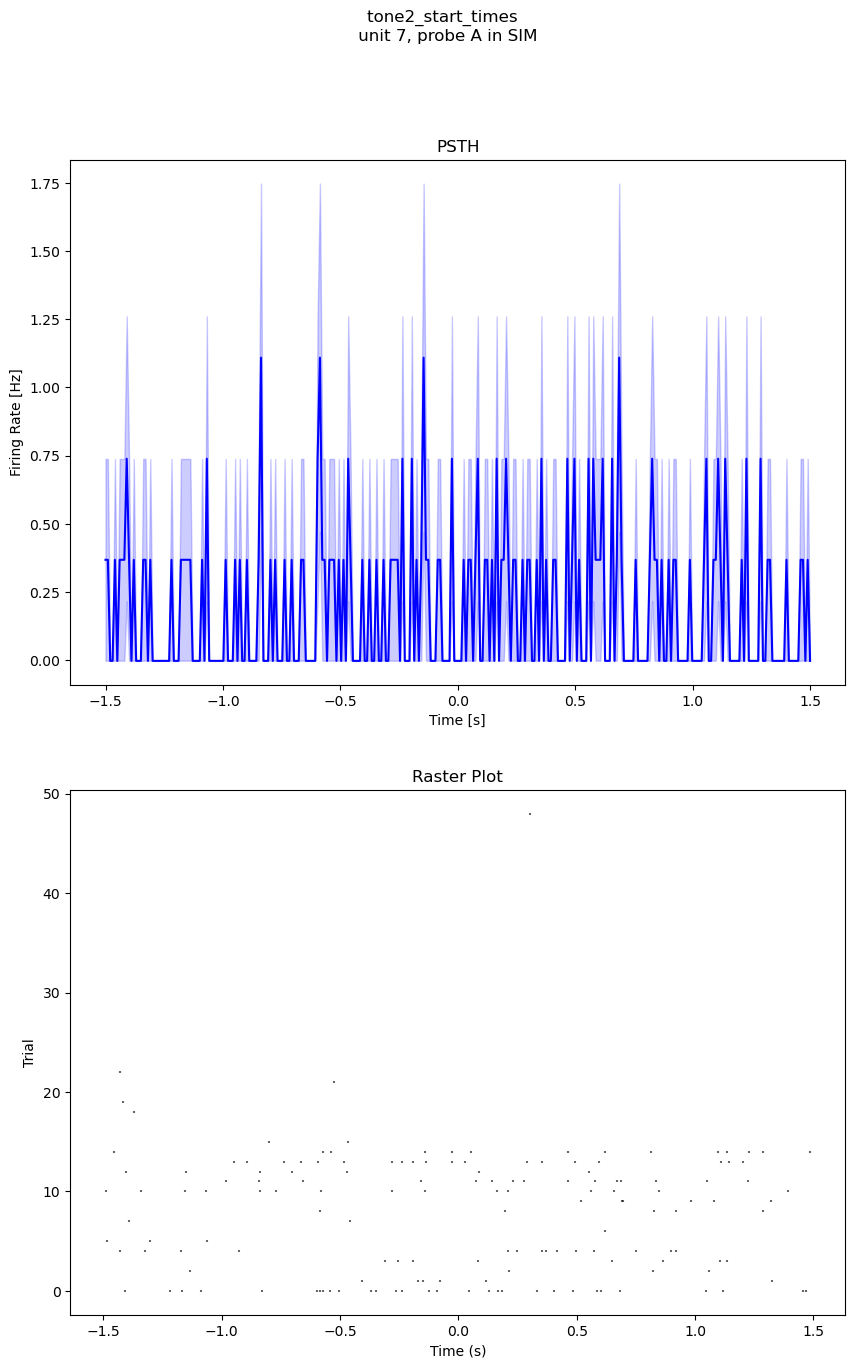

In [46]:
from itertools import product


# main variables to set
probe_letters = ['A', 'B','C', 'D', 'E','F']

# Dictionary mapping event names to event times
variables = {
    'tone2_start_times': tone2_start_times,
    'all_stimROI_start_times':all_stimROI_triggers_start_times
   
}


# General parameters
KSlabel = True
label = False
all_units = False
pre = 1.5
post = 1.5
bin_size = 0.01

# Iterate over probes and event times
for probeLetter in probe_letters:
    df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
    unique_brain_regions = df1.Brain_Region.unique()
    # drp nan values from unique_brain_regions
    unique_brain_regions = unique_brain_regions[~pd.isnull(unique_brain_regions)]
    # Drop all 'nan' and 'None' from unique_brain_regions
    unique_brain_regions = [br for br in unique_brain_regions if pd.notna(br) and br != 'None']
    unique_brain_regions = [br for br in unique_brain_regions if pd.notna(br) and br != 'nan']

    print(f'Unique brain regions for probe {probeLetter}: {unique_brain_regions}\n')
    for brain_region in unique_brain_regions:
        print('brain_region: ', brain_region)
        print(f'number of units in {brain_region}: {len(df1)}')
        for event_name, event_times in variables.items():

            # Construct the path
            save_path = f"{save_dir}\\analysis\\dlab_raster_psth\\allUnits_psth_raster_2_by_brainRegion\\probe{probeLetter}_{brain_region}\\{event_name}"
                
            # Check if directory exists before proceeding
            if not os.path.exists(save_path):
                os.makedirs(save_path)
                print('--Start--')
                print(f'working on data from probe: {probeLetter}')
                print(f'No files found for: {event_name}')
                print(f"Directory created: {save_path}")
                print(f'Creating plots for: {event_name}')
                print(' ')

            else:
                # print(f"Directory already exists: {save_path}")
                # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
                continue

            # Generate plots using the correct brain region for the probe
            save_dir_02 = save_path
            allUnits_psth_raster_2(
                df_units, df_stim, brain_region=brain_region, title_name=event_name, event_times=event_times, 
                KSlabel=KSlabel, all_units=all_units, probeLetter=probeLetter, 
                save_dir=save_dir_02, pre=pre, post=post, bin_size=bin_size
            )


In [ ]:
df_units

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
id,,,,,,,,,,,,
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,NOISE,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,NOISE,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,NOISE,"[9938.29451763671, 9938.519134975282, 9938.609..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4595,860.0,43.0,3740.0,0,1,10.2,175.3,F,OUT_ROI,None,NON-SOMA,"[9939.57044788735, 9939.597083318817, 9939.703..."
4596,1020.0,43.0,3580.0,0,2,19.5,0.0,F,OUT_ROI,None,NOISE,"[10919.660133182651, 10919.6751343645, 10919.7..."
4597,1060.0,11.0,3540.0,0,1,9.6,236.7,F,OUT_ROI,None,NOISE,"[9996.778036617923, 10049.712567383913, 10050...."


In [55]:
cluster_id = df1.cluster_id.values
cluster_id

array([  0,   1,   3,   4,   6,   7,   9,  11,  13,  14,  15,  19,  21,
        22,  23,  26,  28,  29,  30,  31,  40,  48,  51,  58,  59,  61,
        69,  71,  72,  73,  74,  75,  78,  79,  81,  85,  92, 102, 103,
       104, 105, 106, 107, 109, 110, 114, 115, 117, 120, 121, 122, 123,
       126, 127, 130, 131, 132, 133, 143, 144, 145, 148, 150, 152, 160,
       167, 183, 186, 189, 190, 193, 195, 199, 203, 206, 208, 209, 210,
       211, 215, 217, 224, 230, 234, 243, 261, 274, 275, 277, 283, 290,
       291, 292, 297, 303, 305, 317, 318, 320, 333, 340, 341, 347, 350,
       353, 359, 360, 364, 372, 375, 378, 384, 386, 389, 394, 395, 403,
       406, 419, 421, 422, 424, 429, 432, 458, 476, 494, 499, 507, 523,
       526, 527, 529, 532, 544, 551, 552], dtype=int64)

In [56]:
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def psth_raster_stim_seperated_baseline(df_units, df_stim, brain_region=None,event_name='Not Set',trail_indices=None, event_times=None, label=False, KSlabel_good=False,kslabel_mua=False,all_units=True, dot_size=0.5, pre=-1.5, post=1.5, bin_size=0.05, epoch1='pellet_delivery_timestamp', probeLetter=None, save_dir=None):
    # Select units based on the label or KSlabel

    df_units = df_units[df_units.Brain_Region == brain_region]
    
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel_good:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel_good')  
        unit_tag = 'kslabel_good'
    if kslabel_mua:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 1]
        unit_tag = 'kslabel_mua'
        print('using kslabel_mua')
    if all_units:
        df1 = df_units[df_units.probe == probeLetter]
        unit_tag = 'all_units'


    unit_index = df1.index.tolist()

    cluster_id = df1.cluster_id.values

    # Loop through each unit
    for unit in cluster_id:
        # Create a figure for each unit
        n_cols = 1
        n_rows = 2
        fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 15))

        # Retrieve spike times for the unit
        spike_times = df1[df1.cluster_id == unit].spike_times.values[0]

        spike_times_count = len(spike_times)
        fig.suptitle(f"{event_name} \n unit {unit}, probe {probeLetter} in {brain_region} \n {unit_tag} \n n_spikes: {spike_times_count}", color='black')

        # Compute the PSTH and plot it
        psth, var, edges, bytrial = plot_func.trial_by_trial(spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size,brain_region=brain_region)

        #old code
        # color_mapping = {
        #     'optical_stim': 'blue',
        #     'no_optical_stim': 'black'
        # }

        # New Code
        color_mapping = {
            'baseline': 'green',          # New Code
            'optical_stim': 'blue',       # New Code
            'no_optical_stim': 'black'    # New Code
        }

        # Raster plot and PSTH
        for i, (event_name_2, event_indices) in enumerate(trail_indices.items()):
            psth, var, edges, bytrial = plot_func.trial_by_trial(spike_times, event_times[event_indices], pre, post, bin_size, brain_region=brain_region)

            # Get the correct color for this trial type
            color = color_mapping.get(event_name_2, 'gray')  # already correct

            # --- PSTH Plot ---
            mean_baseline = bytrial[:, :int(pre/bin_size)].mean()
            ax[0].plot(edges, psth - mean_baseline, color=color)
            ax[0].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color=color)
            ax[0].set_ylabel('Firing Rate [Hz]')
            ax[0].set_xlabel('Time [s]')
            ax[0].set_title('PSTH')
            legend_handles = [mpatches.Patch(color=color, label=event_name) for event_name, color in color_mapping.items()]
            ax[0].legend(handles=legend_handles, loc='upper right')


        # --- Raster Plot (Ensure Both Colors are Plotted) ---
        for event_name_2, event_indices in trail_indices.items():

            # old code
            # color = color_mapping[event_name_2]

            # New Code
            color = color_mapping.get(event_name_2, 'gray')  # New Code (prevents KeyError)

            for t_idx in event_indices:  # Iterate over indices in this group
                time = event_times[t_idx]  # Get event time
                trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                trial_spikes = trial_spikes - time

                ax[1].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color=color, s=1, alpha=0.6)

        # --- Fixing the Legend ---
        legend_handles = [mpatches.Patch(color=color, label=event_name) for event_name, color in color_mapping.items()]
        ax[1].legend(handles=legend_handles, loc='upper right')

        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")

        # Ensure save_dir exists
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Save the figure
        fig_filename = rf"{save_dir}\clusterID_{unit}_probe{probeLetter}_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free up memory

In [57]:
df_units

,cluster_id,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,bc_ROI,Brain_Region,bc_unitType,spike_times
0,0,3120.0,277.0,30.0,0,2,9.5,14.5,A,IN_ROI,IP,NOISE,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,1,3120.0,277.0,30.0,0,2,10.3,17.2,A,IN_ROI,IP,NOISE,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,2,3120.0,59.0,30.0,0,1,9.0,0.0,A,IN_ROI,IP,NOISE,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,3,2775.0,27.0,375.0,0,2,8.5,0.0,A,IN_ROI,IP,NOISE,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,4,2745.0,59.0,405.0,0,2,9.1,7.4,A,IN_ROI,IP,NOISE,"[9938.29451763671, 9938.519134975282, 9938.609..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,4595,860.0,43.0,3740.0,0,1,10.2,175.3,F,OUT_ROI,None,NON-SOMA,"[9939.57044788735, 9939.597083318817, 9939.703..."
4596,4596,1020.0,43.0,3580.0,0,2,19.5,0.0,F,OUT_ROI,None,NOISE,"[10919.660133182651, 10919.6751343645, 10919.7..."
4597,4597,1060.0,11.0,3540.0,0,1,9.6,236.7,F,OUT_ROI,None,NOISE,"[9996.778036617923, 10049.712567383913, 10050...."
4598,4598,980.0,43.0,3620.0,0,2,26.1,0.0,F,OUT_ROI,None,NON-SOMA,"[10919.650099059141, 10919.665100240469, 10919..."


C:\Users\user\AppData\Local\Temp\ipykernel_35780\595492617.py:64: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


Unique brain regions for probe A: ['IP', 'SIM']

Unique brain regions for probe B: ['PG']

--Start--
working on data from probe: B
brain region: PG
Using Event time for alignment: tone2_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated_baseline_by_brainRegion\all_units\probeB_PG\tone2_start_times
Total Units Found After Filtering:  {511}


Unique brain regions for probe C: ['MoP']

--Start--
working on data from probe: C
brain region: MoP
Using Event time for alignment: tone2_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated_baseline_by_brainRegion\all_units\probeC_MoP\tone2_start_times
Total Units Found After Filtering:  {355}


Unique brain regions for probe D: ['VaL']

--Start--
working on data fro

KeyboardInterrupt: 

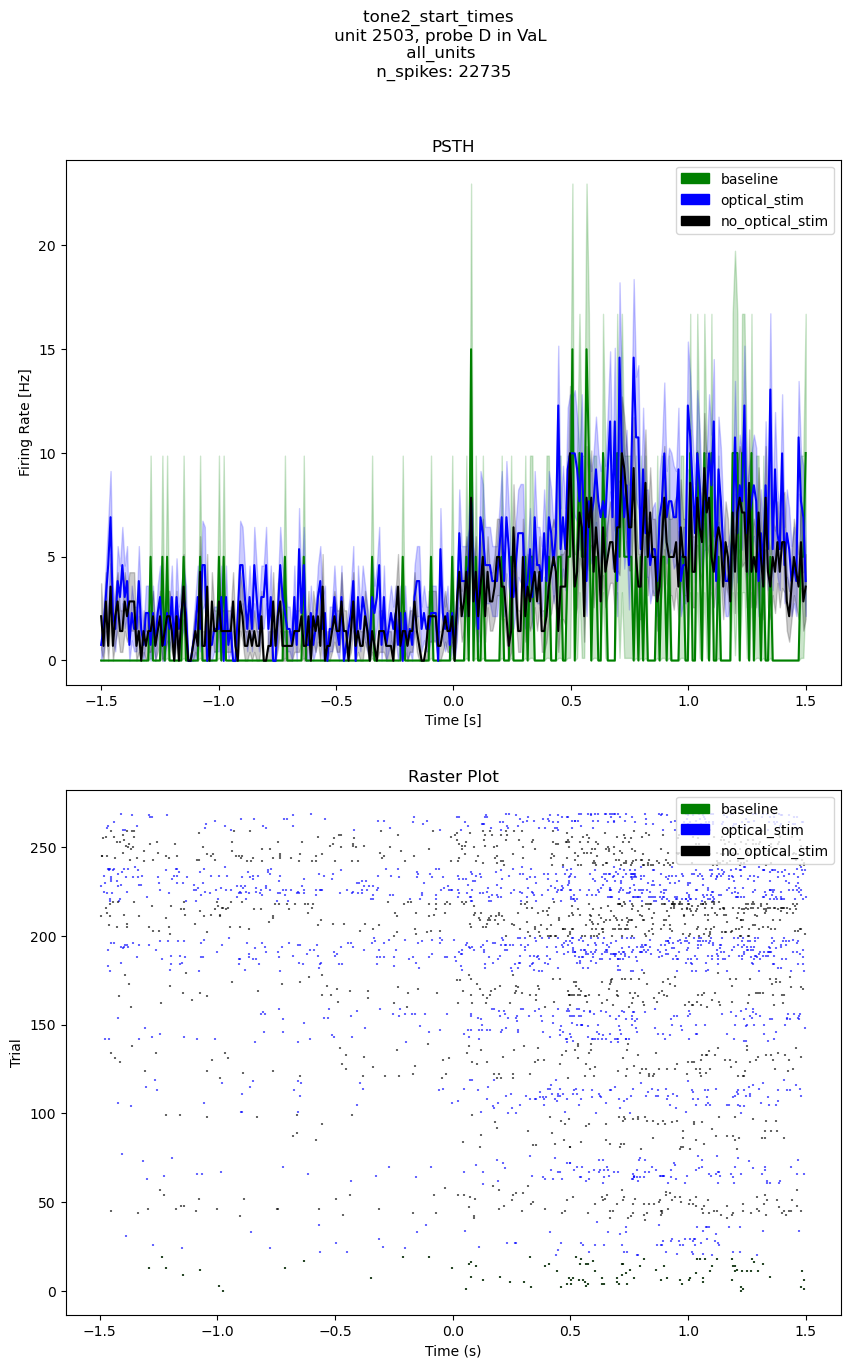

In [59]:
from itertools import product


# main variables to set
probe_letters = ['A', 'B','C', 'D', 'E','F']

# Dictionary mapping event names to event times
variables = {
    'tone2_start_times': tone2_start_times,
    # 'all_stimROI_start_times':all_stimROI_triggers_start_times
   
}

# }

# New Code: include baseline + ensure 0-based indexing

def flatten_nested_trial_numbers(nested):  # New Code
    if isinstance(nested, np.ndarray) and nested.dtype == object:
        return np.concatenate([np.asarray(x, dtype=int) for x in nested])
    return np.asarray(nested, dtype=int)

baseline_trials_1based = flatten_nested_trial_numbers(baseline_trials_idx)          # New Code
stim_trials_1based     = flatten_nested_trial_numbers(optoicalStim_trials_idx)      # New Code

baseline_trials_0based = baseline_trials_1based - 1                                  # New Code
stim_trials_0based     = stim_trials_1based - 1                                      # New Code

# IMPORTANT: these indices are only guaranteed to match tone2 ordering.
# If you use event_times other than tone2_start_times, you must ensure the same trial indexing.
n_trials_total = len(tone2_start_times)                                              # New Code
all_trials_0based = np.arange(n_trials_total, dtype=int)                             # New Code

no_stim_trials_0based = np.setdiff1d(all_trials_0based, stim_trials_0based)          # New Code

trail_indices = {                                                                     # New Code
    'baseline': baseline_trials_0based,
    'optical_stim': stim_trials_0based,
    'no_optical_stim': no_stim_trials_0based,
}


# General parameters
KSlabel_good = False
kslabel_mua = False
label_good = False
label_mua = False
all_units = True
pre = 1.5
post = 1.5
bin_size = 0.01

if all_units:
    save_tag = 'all_units'
elif KSlabel_good:
    save_tag = 'KSlabel_good'
elif kslabel_mua:
    save_tag = 'kslabel_mua'
elif label:
    save_tag = 'label'

# Iterate over probes and event times
for probeLetter in probe_letters:
    df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
    unique_brain_regions = df1.Brain_Region.unique()
    # drp nan values from unique_brain_regions
    unique_brain_regions = unique_brain_regions[~pd.isnull(unique_brain_regions)]
    # Drop all 'nan' and 'None' from unique_brain_regions
    unique_brain_regions = [br for br in unique_brain_regions if pd.notna(br) and br != 'None']
    unique_brain_regions = [br for br in unique_brain_regions if pd.notna(br) and br != 'nan']

    print(f'Unique brain regions for probe {probeLetter}: {unique_brain_regions}\n')  
    for brain_region in unique_brain_regions:
        # df1 = merged_dic[probeLetter]
        for event_name, event_times in variables.items():

            # Construct the path
            save_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_stim_seperated_baseline_by_brainRegion\\{save_tag}\\probe{probeLetter}_{brain_region}\\{event_name}"  # New Code

                
            # Check if directory exists before proceeding
            if not os.path.exists(save_path):
                os.makedirs(save_path)
                print('--Start--')
                print(f'working on data from probe: {probeLetter}')
                print(f'brain region: {brain_region}')
                print(f'Using Event time for alignment: {event_name}')
                print(f"Directory created: {save_path}")
    

            else:
                # print(f"Directory already exists: {save_path}")
                # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
                continue

            # Generate plots using the correct brain region for the probe
            save_dir_02 = save_path

            if all_units:
                df_units_brain_region = df_units[df_units.Brain_Region == brain_region]
            if KSlabel_good:
                df_units_brain_region = df_units[(df_units.Brain_Region == brain_region) & (df_units.KSlabel == 2)]
            if kslabel_mua:
                df_units_brain_region = df_units[(df_units.Brain_Region == brain_region) & (df_units.KSlabel == 1)]
            if label:
                df_units_brain_region = df_units[(df_units.Brain_Region == brain_region) & (df_units.label == 2)]

            print('Total Units Found After Filtering: ', {len(df_units_brain_region)})
            print('\n')

            psth_raster_stim_seperated_baseline(
                df_units_brain_region, df_stim,
                brain_region=brain_region,
                trail_indices=trail_indices,
                event_name=event_name,
                event_times=event_times,
                KSlabel_good=KSlabel_good,
                kslabel_mua=kslabel_mua,
                all_units=all_units,
                probeLetter=probeLetter,
                save_dir=save_dir_02,
                pre=pre, post=post, bin_size=bin_size
            )


In [ ]:
from itertools import product


# main variables to set
probe_letters = ['A', 'B','C', 'D', 'E','F']

# Dictionary mapping event names to event times
variables = {
    # 'tone2_start_times': tone2_start_times,
    'all_stimROI_start_times':all_stimROI_triggers_start_times
}

# }

# New Code: include baseline + ensure 0-based indexing

def flatten_nested_trial_numbers(nested):  # New Code
    if isinstance(nested, np.ndarray) and nested.dtype == object:
        return np.concatenate([np.asarray(x, dtype=int) for x in nested])
    return np.asarray(nested, dtype=int)

baseline_trials_1based = flatten_nested_trial_numbers(baseline_trials_idx)          # New Code
stim_trials_1based     = flatten_nested_trial_numbers(optoicalStim_trials_idx)      # New Code

baseline_trials_0based = baseline_trials_1based - 1                                  # New Code
stim_trials_0based     = stim_trials_1based - 1                                      # New Code

# IMPORTANT: these indices are only guaranteed to match tone2 ordering.
# If you use event_times other than tone2_start_times, you must ensure the same trial indexing.
n_trials_total = len(tone2_start_times)                                              # New Code
all_trials_0based = np.arange(n_trials_total, dtype=int)                             # New Code

no_stim_trials_0based = np.setdiff1d(all_trials_0based, stim_trials_0based)          # New Code

trail_indices = {                                                                     # New Code
    'baseline': baseline_trials_0based,
    'optical_stim': stim_trials_0based,
    'no_optical_stim': no_stim_trials_0based,
}


# General parameters

# Yu must set one of these to TRUE
KSlabel_good = True
kslabel_mua = False
label = False
all_units = False
# Yu must set one of these to TRUE
pre = 1.5
post = 1.5
bin_size = 0.01

if all_units:
    save_tag = 'all_units'
elif KSlabel_good:
    save_tag = 'KSlabel_good'
elif kslabel_mua:
    save_tag = 'kslabel_mua'
elif label:
    save_tag = 'label'

# Iterate over probes and event times
for probeLetter in probe_letters:
    df1 = merged_dic[probeLetter]
    unique_brain_regions = df1.Brain_Region_y.unique()
    # drp nan values from unique_brain_regions
    unique_brain_regions = unique_brain_regions[~pd.isnull(unique_brain_regions)]
    print(unique_brain_regions)
    for brain_region in unique_brain_regions:
        print(brain_region)
        df1 = merged_dic[probeLetter]
        df1_brain_region = df1[df1.Brain_Region_y == brain_region]
        print(f'number of units in {brain_region}: {len(df1_brain_region)}')

        for event_name, event_times in variables.items():
            print(f'Processing probe {probeLetter}, brain region {brain_region}, event {event_name} with save tag {save_tag}')

            # Construct the path
            opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_stim_seperated_baseline_by_brainRegion\\{save_tag}\\probe{probeLetter}_{brain_region}\\{event_name}"  # New Code

                
            # Check if directory exists before proceeding
            if not os.path.exists(opto_tagging_path):
                os.makedirs(opto_tagging_path)
                print('--Start--')
                print(f'working on data from probe: {probeLetter}')
                print(f'No files found for: {event_name}')
                print(f"Directory created: {opto_tagging_path}")
                print(f'Creating plots for: {event_name}')
                print(' ')

            else:
                print(f"Directory already exists: {opto_tagging_path}")
                print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
                continue

            # Generate plots using the correct brain region for the probe
            save_dir_02 = opto_tagging_path
            df_units = df1_brain_region

            psth_raster_stim_seperated_baseline(
                df_units, df_stim,
                brain_region=brain_region,
                trail_indices=trail_indices,
                event_name=event_name,
                event_times=event_times,
                KSlabel_good=KSlabel_good,
                kslabel_mua=kslabel_mua,
                all_units=all_units,
                probeLetter=probeLetter,
                save_dir=save_dir_02,
                pre=pre, post=post, bin_size=bin_size
            )


['SIM' 'IP']
SIM
number of units in SIM: 468
Processing probe A, brain region SIM, event all_stimROI_start_times with save tag all_units
--Start--
working on data from probe: A
No files found for: all_stimROI_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated_baseline_by_brainRegion\all_units\probeA_SIM\all_stimROI_start_times
Creating plots for: all_stimROI_start_times
 


### MUA unit plotting using 

--Start--
working on data from probe: B
No files found for: tone1_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated_baseline\KSlabel_mua\probeB\tone1_start_times
Creating plots for: tone1_start_times
 
using kslabel_mua


C:\Users\user\AppData\Local\Temp\ipykernel_32012\501484980.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 1]


KeyboardInterrupt: 

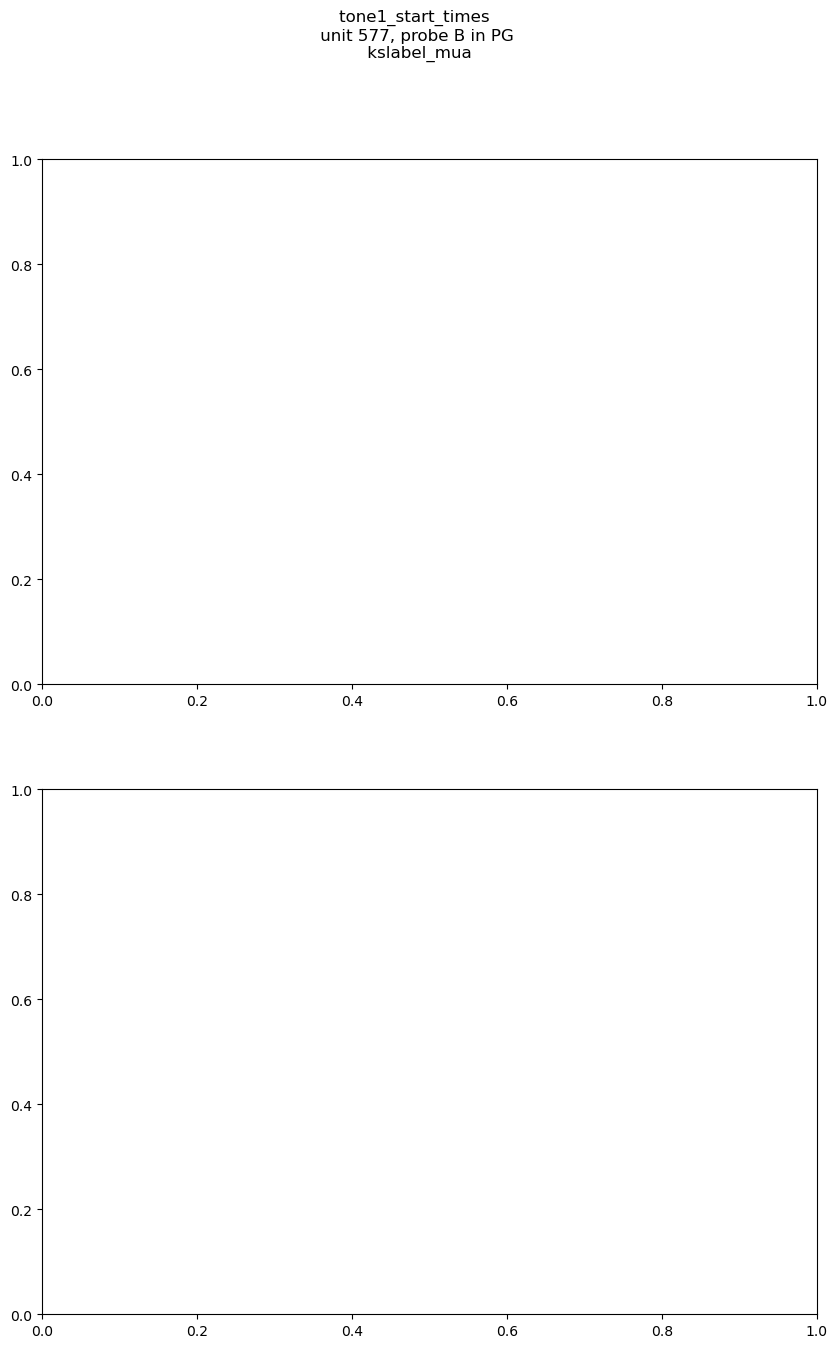

In [ ]:
from itertools import product

# old code
# probe_letters = ['A', 'B','C' 'C', 'D', 'E','F']

# New Code (fixes the accidental 'CC' concatenation)
probe_letters = ['A', 'B', 'C', 'D', 'E', 'F']  # New Code


# Dictionary mapping event names to event times
variables = {
    'all_stimROI_triggers_start_times': all_stimROI_triggers_start_times,
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
}

# Mapping each probe to its corresponding brain region
probe_to_brain_region = {
    'A': 'SIM_IP',
    'B': 'PG',
    'C': 'MoP',
    'D': 'VaL',
    'E': 'SnR',
    'F': 'RN'
}

# old code
# trail_indices = {
#     'optical_stim': trails_with_optical_stim,
#     'no_optical_stim': trails_without_optical_stim,
# }

# New Code: include baseline + ensure 0-based indexing
import numpy as np  # New Code

def flatten_nested_trial_numbers(nested):  # New Code
    if isinstance(nested, np.ndarray) and nested.dtype == object:
        return np.concatenate([np.asarray(x, dtype=int) for x in nested])
    return np.asarray(nested, dtype=int)

baseline_trials_1based = flatten_nested_trial_numbers(baseline_trials_idx)          # New Code
stim_trials_1based     = flatten_nested_trial_numbers(optoicalStim_trials_idx)      # New Code

baseline_trials_0based = baseline_trials_1based - 1                                  # New Code
stim_trials_0based     = stim_trials_1based - 1                                      # New Code

# IMPORTANT: these indices are only guaranteed to match tone2 ordering.
# If you use event_times other than tone2_start_times, you must ensure the same trial indexing.
n_trials_total = len(tone2_start_times)                                              # New Code
all_trials_0based = np.arange(n_trials_total, dtype=int)                             # New Code

no_stim_trials_0based = np.setdiff1d(all_trials_0based, stim_trials_0based)          # New Code

trail_indices = {                                                                     # New Code
    'baseline': baseline_trials_0based,
    'optical_stim': stim_trials_0based,
    'no_optical_stim': no_stim_trials_0based,
}


# General parameters
KSlabel_good = False
kslabel_mua = True
label = False
all_units = False
pre = 0.5
post = 1
bin_size = 0.01

# Iterate over probes and event times
for probeLetter in probe_letters:
    brain_region = probe_to_brain_region[probeLetter]

    for event_name, event_times in variables.items():

        # old code
        # opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_stim_seperated\\probe{probeLetter}\\{event_name}"

        # New Code (optional but recommended): new output folder name to reflect baseline
        opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_stim_seperated_baseline\\KSlabel_mua\\probe{probeLetter}\\{event_name}"  # New Code

        if not os.path.exists(opto_tagging_path):
            os.makedirs(opto_tagging_path)
            print('--Start--')
            print(f'working on data from probe: {probeLetter}')
            print(f'No files found for: {event_name}')
            print(f"Directory created: {opto_tagging_path}")
            print(f'Creating plots for: {event_name}')
            print(' ')
        else:
            continue

        save_dir_02 = opto_tagging_path
        psth_raster_stim_seperated_baseline(
            df_units, df_stim,
            brain_region=brain_region,
            trail_indices=trail_indices,
            event_name=event_name,
            event_times=event_times,
            KSlabel_good=KSlabel_good,
            kslabel_mua=kslabel_mua,
            all_units=all_units,
            probeLetter=probeLetter,
            save_dir=save_dir_02,
            pre=pre, post=post, bin_size=bin_size
        )


## psth_raster_stim_seperated creates one single plot for each event
- - - Working Check: Yes, (01-30-25)
- it makes a psth and raster plot for each event
- and a folder for each event placed into the variables dictionary

In [ ]:
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def psth_raster_stim_seperated(df_units, df_stim, brain_region,event_name='Not Set',trail_indices=None, event_times=None, label=False, KSlabel=False,all_units=True, dot_size=0.5, pre=0.5, post=1, bin_size=0.05, epoch1='pellet_delivery_timestamp', probeLetter=None, save_dir=None):
    # Select units based on the label or KSlabel
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel')  
    if all_units:
        df1 = df_units[df_units.probe == probeLetter]

    unit_index = df1.index.tolist()

    # Loop through each unit
    for unit in unit_index:
        # Create a figure for each unit
        n_cols = 1
        n_rows = 2
        fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 15))
        fig.suptitle(f"{event_name} \n unit {unit}, probe {probeLetter} in {brain_region}", color='black')

        # Retrieve spike times for the unit
        spike_times = df1[df1.index == unit].spike_times.values[0]

        # Compute the PSTH and plot it
        psth, var, edges, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size)
    
            # Define color mapping for each trial group
        # NEW CODE
        color_mapping = {
            'baseline': 'green',
            'optical_stim': 'blue',
            'no_optical_stim': 'black'
        }

        # Raster plot and PSTH
        for i, (event_name_2, event_indices) in enumerate(trail_indices.items()):
            psth, var, edges, bytrial = trial_by_trial(spike_times, event_times[event_indices], pre, post, bin_size)

            # Get the correct color for this trial type
            color = color_mapping.get(event_name_2, 'gray')  # Default to gray if not found

            # --- PSTH Plot ---
            mean_baseline = bytrial[:, :int(pre/bin_size)].mean()
            ax[0].plot(edges, psth - mean_baseline, color=color)
            ax[0].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color=color)
            ax[0].set_ylabel('Firing Rate [Hz]')
            ax[0].set_xlabel('Time [s]')
            ax[0].set_title('PSTH')
            legend_handles = [mpatches.Patch(color=color, label=event_name) for event_name, color in color_mapping.items()]
            ax[0].legend(handles=legend_handles, loc='upper right')


        # --- Raster Plot (Ensure Both Colors are Plotted) ---
        for event_name_2, event_indices in trail_indices.items():
            color = color_mapping[event_name_2]

            for t_idx in event_indices:  # Iterate over indices in this group
                time = event_times[t_idx]  # Get event time
                trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                trial_spikes = trial_spikes - time

                ax[1].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color=color, s=1, alpha=0.6)

        # --- Fixing the Legend ---
        legend_handles = [mpatches.Patch(color=color, label=event_name) for event_name, color in color_mapping.items()]
        ax[1].legend(handles=legend_handles, loc='upper right')

        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")

            
            

        # Ensure save_dir exists
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Save the figure
        fig_filename = rf"{save_dir}\unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free up memory



--Start--
working on data from probe: A
No files found for: reach_Init_from_StimROI_without_STIM
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated\probeA\reach_Init_from_StimROI_without_STIM
Creating plots for: reach_Init_from_StimROI_without_STIM
 
using KSlabel


C:\Users\user\AppData\Local\Temp\ipykernel_7968\878305385.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


--Start--
working on data from probe: B
No files found for: reach_Init_from_StimROI_with_STIM
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated\probeB\reach_Init_from_StimROI_with_STIM
Creating plots for: reach_Init_from_StimROI_with_STIM
 
using KSlabel


IndexError: index 125 is out of bounds for axis 0 with size 125

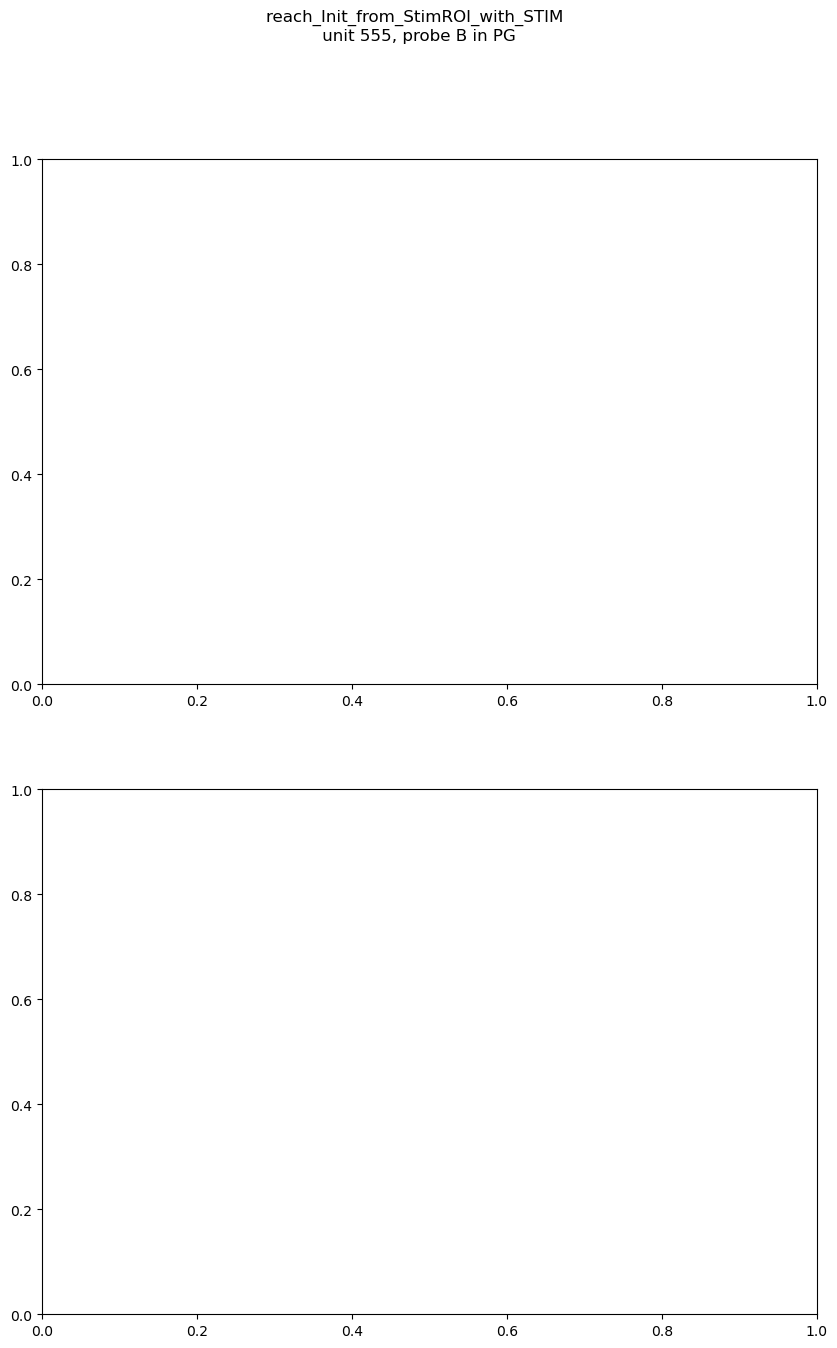

In [102]:
from itertools import product


# main variables to set
probe_letters = ['A', 'B','C' 'C', 'D', 'E','F']

# Dictionary mapping event names to event times
variables = {
    'reach_Init_from_StimROI_with_STIM': reach_Init_from_StimROI_with_STIM,
    'reach_Init_from_StimROI_without_STIM': reach_Init_from_StimROI_with_NO_STIM,
    # 'all_stimROI_start_times':all_stimROI_triggers_start_times
   }

# Mapping each probe to its corresponding brain region
probe_to_brain_region = {
    'A': 'SIM_IP',
    'B': 'PG',
    'C': 'MoP',
    'D': 'VaL',
    'E': 'SnR',
    'F': 'RN'   
}

trail_indices = {
    'optical_stim': trails_with_optical_stim,
    'no_optical_stim': trails_without_optical_stim,
}

# General parameters
KSlabel = True
label = False
all_units = False
pre = 0.5
post = 1
bin_size = 0.01

# Iterate over probes and event times
for probeLetter in probe_letters:
    brain_region = probe_to_brain_region[probeLetter]  # Get the corresponding brain region

    for event_name, event_times in variables.items():

        # Construct the path
        opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_stim_seperated\\probe{probeLetter}\\{event_name}"
            
        # Check if directory exists before proceeding
        if not os.path.exists(opto_tagging_path):
            os.makedirs(opto_tagging_path)
            print('--Start--')
            print(f'working on data from probe: {probeLetter}')
            print(f'No files found for: {event_name}')
            print(f"Directory created: {opto_tagging_path}")
            print(f'Creating plots for: {event_name}')
            print(' ')

        else:
            # print(f"Directory already exists: {opto_tagging_path}")
            # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
            continue

        # Generate plots using the correct brain region for the probe
        save_dir_02 = opto_tagging_path
        psth_raster_stim_seperated(
            df_units, df_stim, brain_region=brain_region, trail_indices=trail_indices, event_name=event_name, event_times=event_times, 
            KSlabel=KSlabel, all_units=all_units, probeLetter=probeLetter, 
            save_dir=save_dir_02, pre=pre, post=post, bin_size=bin_size
        )


In [105]:
print(trails_with_optical_stim[0:40])
print(trails_without_optical_stim[0:40])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
[43, 50, 81, 126]


--Start--
working on data from probe: A
No files found for: all_stimROI_triggers_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated\probeA\all_stimROI_triggers_start_times
Creating plots for: all_stimROI_triggers_start_times
 
using KSlabel


C:\Users\user\AppData\Local\Temp\ipykernel_7968\878305385.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]


--Start--
working on data from probe: A
No files found for: tone1_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated\probeA\tone1_start_times
Creating plots for: tone1_start_times
 
using KSlabel
--Start--
working on data from probe: A
No files found for: tone2_start_times
Directory created: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\dlab_raster_psth\psth_raster_stim_seperated\probeA\tone2_start_times
Creating plots for: tone2_start_times
 
using KSlabel


KeyboardInterrupt: 

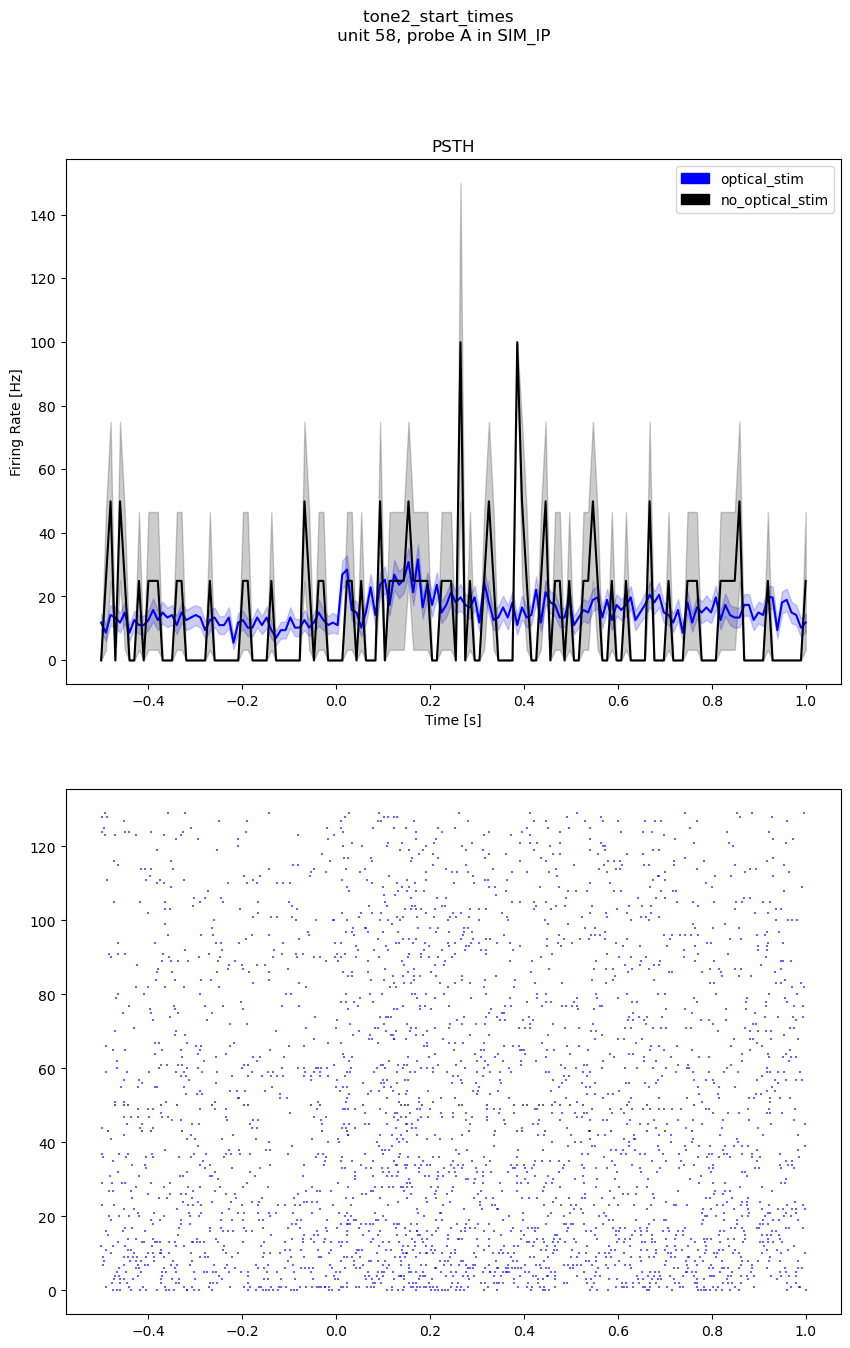

In [103]:
from itertools import product


# main variables to set
probe_letters = ['A', 'B','C' 'C', 'D', 'E','F']

# Dictionary mapping event names to event times
variables = {
    
    'all_stimROI_triggers_start_times': all_stimROI_triggers_start_times,
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
   }

# Mapping each probe to its corresponding brain region
probe_to_brain_region = {
    'A': 'SIM_IP',
    'B': 'PG',
    'C': 'MoP',
    'D': 'VaL',
    'E': 'SnR',
    'F': 'RN'   
}

trail_indices = {
    'optical_stim': trails_with_optical_stim,
    'no_optical_stim': trails_without_optical_stim,
}

# General parameters
KSlabel = True
label = False
all_units = False
pre = 0.5
post = 1
bin_size = 0.01

# Iterate over probes and event times
for probeLetter in probe_letters:
    brain_region = probe_to_brain_region[probeLetter]  # Get the corresponding brain region

    for event_name, event_times in variables.items():

        # Construct the path
        opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_stim_seperated\\probe{probeLetter}\\{event_name}"
            
        # Check if directory exists before proceeding
        if not os.path.exists(opto_tagging_path):
            os.makedirs(opto_tagging_path)
            print('--Start--')
            print(f'working on data from probe: {probeLetter}')
            print(f'No files found for: {event_name}')
            print(f"Directory created: {opto_tagging_path}")
            print(f'Creating plots for: {event_name}')
            print(' ')

        else:
            # print(f"Directory already exists: {opto_tagging_path}")
            # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
            continue

        # Generate plots using the correct brain region for the probe
        save_dir_02 = opto_tagging_path
        psth_raster_stim_seperated(
            df_units, df_stim, brain_region=brain_region, trail_indices=trail_indices, event_name=event_name, event_times=event_times, 
            KSlabel=KSlabel, all_units=all_units, probeLetter=probeLetter, 
            save_dir=save_dir_02, pre=pre, post=post, bin_size=bin_size
        )


## psth_raster_all_events_seperated creates one plot with different subplots for each event
- - Working Check: Yes, (01-30-25)
- in the variables, whatever event_times you add will become a subplot with a raster and a psth plot
- the psth and raster plots are seperated by color to show the trials either with or without optical stimulation


In [42]:
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches

def psth_raster_all_events_seperated(df_units, df_stim, brain_region, event_name='Not Set', 
                                variables=None, trail_indices=None, label=False, KSlabel=False, 
                                all_units=True, dot_size=0.5, pre=0.5, post=1, bin_size=0.05, 
                                epoch1='pellet_delivery_timestamp', probeLetter=None, save_dir=None):
    """
    Generates a multi-column figure where each column corresponds to an event time in `variables`. 
    Each column contains a PSTH (top row) and a Raster plot (bottom row) for that event time.
    """

    # Select units based on the label or KSlabel
    if label:
        df1 = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
        print('Using label')
    elif KSlabel:
        df1 = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
        print('Using KSlabel')
    else:
        df1 = df_units[df_units.probe == probeLetter]

    unit_index = df1.index.tolist()
    num_columns = len(variables)  # Number of event_times to plot

    # Define color mapping for each trial group
    color_mapping = {
        'optical_stim': 'blue',
        'no_optical_stim': 'black'
    }

    # Loop through each unit
    for unit in unit_index:
        # Create a figure with multiple columns (one per event_time in variables)
        fig, ax = plt.subplots(2, num_columns, figsize=(10 * num_columns, 20), sharey='row')
        fig.suptitle(f"Unit {unit}, Probe {probeLetter} in {brain_region}", color='black')

        # Retrieve spike times for the unit
        spike_times = df1.loc[unit, 'spike_times']

        # Loop through `variables` to create subplots per event_time
        for col, (event_name_2, event_times) in enumerate(variables.items()):
            
            # --- PSTH Plot (Top Row) ---
            for i, (trial_type, event_indices) in enumerate(trail_indices.items()):
                psth, var, edges, bytrial = trial_by_trial(spike_times, event_times[event_indices], pre, post, bin_size)
                mean_baseline = bytrial[:, :int(pre/bin_size)].mean()
                color = color_mapping.get(trial_type, 'gray')

                ax[0, col].plot(edges, psth - mean_baseline, color=color)
                ax[0, col].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color=color)

            ax[0, col].set_ylabel('Firing Rate [Hz]')
            ax[0, col].set_xlabel('Time [s]')
            ax[0, col].set_title(f'{event_name_2}')
            # ax[0, col].legend([mpatches.Patch(color=c, label=n) for n, c in color_mapping.items()], loc='upper right')

            # --- Raster Plot (Bottom Row) ---
            for trial_type, event_indices in trail_indices.items():
                color = color_mapping.get(trial_type, 'gray')

                for t_idx in event_indices:
                    time = event_times[t_idx]  
                    trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                    trial_spikes = trial_spikes - time

                    ax[1, col].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color=color, s=1, alpha=0.6)

            ax[1, col].set_ylabel("Trial")
            ax[1, col].set_xlabel("Time (s)")
            ax[1, col].set_title(f"{event_name_2}")
            # ax[1, col].legend([mpatches.Patch(color=c, label=n) for n, c in color_mapping.items()], loc='upper right')

        # Ensure save_dir exists
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Save the figure
        fig_filename = os.path.join(save_dir, f"unit_{unit}_probe_{probeLetter}_region_{brain_region}.png")
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free up memory


--Start--
Working on data from probe: B
Directory created: G:\Grant\neuropixels\kilosort_recordings\reach3_01_2024-11-14_21-30-18_001\analysis\dlab_raster_psth\psth_raster_all_events_seperated\probeB
Creating plots for all event times
Using KSlabel


KeyboardInterrupt: 

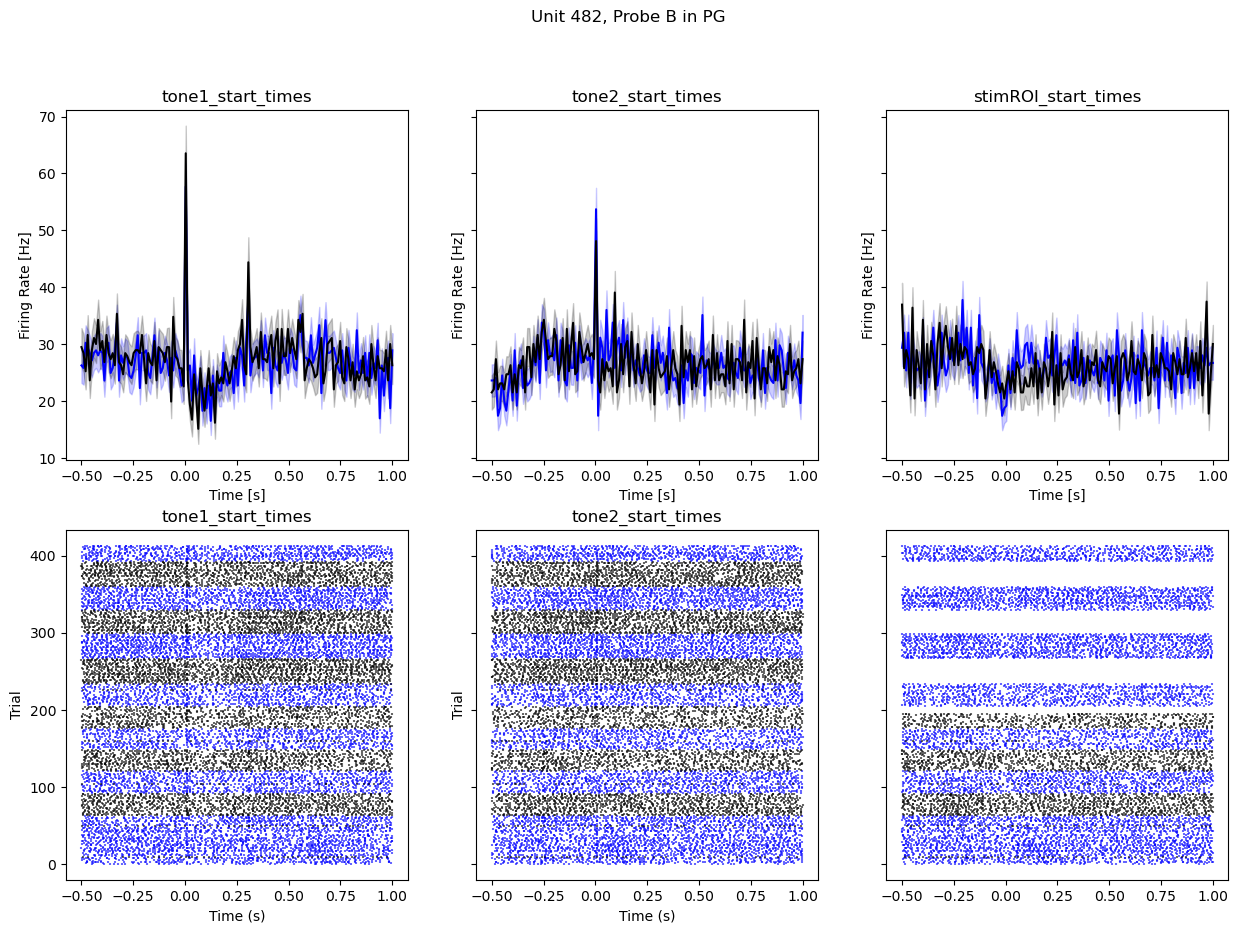

In [ ]:
from itertools import product


# main variables to set
probe_letters = ['A', 'B', 'D', 'E']

# Dictionary mapping event names to event times
variables = {
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
    'all_stimROI_start_times':all_stimROI_triggers_start_times
   }

# Mapping each probe to its corresponding brain region
probe_to_brain_region = {
    'A': 'SIM_IP',
    'B': 'PG',
    'C': 'MoP',
    'D': 'VaL',
    'E': 'SnR',
    'F': 'RN'
}

trail_indices = {
    'optical_stim': trails_with_optical_stim,
    'no_optical_stim': trails_without_optical_stim,
}

# General parameters
KSlabel = True
label = False
all_units = False
pre = 0.5
post = 1
bin_size = 0.01

# Iterate over probes (DO NOT loop over `variables.items()` anymore)
for probeLetter in probe_letters:
    brain_region = probe_to_brain_region[probeLetter]  # Get the corresponding brain region

    # Construct the path (single directory for all event times)
    opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_all_events_seperated\\probe{probeLetter}"
    
    if not os.path.exists(opto_tagging_path):
        os.makedirs(opto_tagging_path)
        print('--Start--')
        print(f'Working on data from probe: {probeLetter}')
        print(f"Directory created: {opto_tagging_path}")
        print('Creating plots for all event times')
    
    else:
        # print(f"Directory already exists: {opto_tagging_path}")
        # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
        continue

    # Generate plots for all event times in one figure
    psth_raster_all_events_seperated(
        df_units, df_stim, brain_region=brain_region, 
        variables=variables, trail_indices=trail_indices, probeLetter=probeLetter, 
        save_dir=opto_tagging_path, pre=pre, post=post, bin_size=bin_size,
        KSlabel=KSlabel, all_units=all_units
    )

## psth_raster_all_events_seperated_plus_opto creates one plot with different subplots for each event. 
- Working Check: Yes, (01-30-25)
- it can also add aubplots for different trial types that do not have the same number of trials. for example: the opto-tagging trails
- in the variables, whatever event_times you add will become a subplot with a raster and a psth plot
- the psth and raster plots are seperated by color to show the trials either with or without optical stimulation

In [48]:
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches

def psth_raster_all_events_seperated_plus_opto(df_units, df_stim, brain_region, event_name='Not Set', 
                                variables=None, trail_indices=None, label=False, KSlabel=False, 
                                all_units=True, dot_size=0.5, pre=0.5, post=1, bin_size=0.05, 
                                epoch1='pellet_delivery_timestamp', probeLetter=None, save_dir=None):
    """
    Generates a multi-column figure where each column corresponds to an event time in `variables`. 
    The last two variables are plotted as regular PSTH and raster plots without color separation.
    """

    # Select units based on the label or KSlabel
    if label:
        df1 = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
        print('Using label')
    elif KSlabel:
        df1 = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
        print('Using KSlabel')
    else:
        df1 = df_units[df_units.probe == probeLetter]

    unit_index = df1.index.tolist()
    num_columns = len(variables)  # Number of event_times to plot

    # Define color mapping for each trial group
    color_mapping = {
        'optical_stim': 'blue',
        'no_optical_stim': 'black'
    }
    scatter_dot_size = 7
    # Loop through each unit
    for unit in unit_index:
        # Create a figure with multiple columns (one per event_time in variables)
        fig, ax = plt.subplots(2, num_columns, figsize=(10 * num_columns, 20), sharey='row')
  
        fig.suptitle(f"Unit {unit}, Probe {probeLetter} in {brain_region}", color='black')

        # Retrieve spike times for the unit
        spike_times = df1.loc[unit, 'spike_times']

        # Loop through `variables` to create subplots per event_time
        for col, (event_name_2, event_times) in enumerate(variables.items()):
        
            # --- PSTH Plot (Top Row) ---
            if event_name_2 in ['first_opto_tagging_timestamp_per_trial', 'first_optical_pulse_per_closed_loop']:
                # Regular PSTH without color separation
                if len(event_times) == 0:
                    continue

                psth, var, edges, bytrial = trial_by_trial(spike_times, event_times, pre, post, bin_size)
                mean_baseline = bytrial[:, :int(pre/bin_size)].mean()
                
                if np.all(psth == 0):  # If PSTH is all zeros, warn
                    print(f"Warning: PSTH for {event_name_2} is empty. No spikes aligned.")

                ax[0, col].plot(edges, psth - mean_baseline, color='black')
                ax[0, col].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color='black')
            
            else:
                # PSTH with color separation
                for i, (trial_type, event_indices) in enumerate(trail_indices.items()):
                    psth, var, edges, bytrial = trial_by_trial(spike_times, event_times[event_indices], pre, post, bin_size)
                    mean_baseline = bytrial[:, :int(pre/bin_size)].mean()
                    color = color_mapping.get(trial_type, 'gray')

                    ax[0, col].plot(edges, psth - mean_baseline, color=color)
                    ax[0, col].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color=color)

            ax[0, col].set_ylabel('Firing Rate [Hz]')
            ax[0, col].set_xlabel('Time [s]')
            ax[0, col].set_title(f'{event_name_2}')

                        ## --- Raster Plot (Bottom Row) ---
            if event_name_2 in ['first_opto_tagging_timestamp_per_trial', 'first_optical_pulse_per_closed_loop']:
                # Regular Raster Plot without color separation
                trial_counts = len(event_times)  # Count valid trials

                for t_idx, time in enumerate(event_times):
                    trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                    trial_spikes = trial_spikes - time

                    ax[1, col].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color='black', s=scatter_dot_size, alpha=0.6)

                ax[1, col].set_ylim(0, trial_counts)  # Dynamically adjust y-axis based on trial count

                            # âœ… Added these two lines to display actual trial numbers:
                # ax[1, col].set_yticks(range(trial_counts))
                # ax[1, col].set_yticklabels(range(1, trial_counts + 1))  # Trial numbers start from 1
            else:
                # Raster plot with color separation
                max_trials = 0
                for trial_type, event_indices in trail_indices.items():
                    color = color_mapping.get(trial_type, 'gray')

                    for t_idx in event_indices:
                        if t_idx < len(event_times):  # Ensure index is within bounds
                            time = event_times[t_idx]  
                            trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                            trial_spikes = trial_spikes - time

                            ax[1, col].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color=color, s=scatter_dot_size, alpha=0.6)
                            max_trials = max(max_trials, t_idx)

                ax[1, col].set_ylim(0, max_trials + 10)  # General case, adding buffer

                        # âœ… Added these two lines to display actual trial numbers:
            ax[1, col].set_yticks(event_indices[::10])  # Select every 10th trial index
            ax[1, col].set_yticklabels(event_indices[::10])  # Label only every 10th trial

            ax[1, col].set_ylabel("Trial")
            ax[1, col].set_xlabel("Time (s)")


        # --- Add Legend for Opto-Stim and No-Opto-Stim ---
        legend_handles = [
            mpatches.Patch(color='blue', label='Opto-Stim Trials'),
            mpatches.Patch(color='black', label='No-Opto-Stim Trials')
        ]
        fig.legend(handles=legend_handles, loc='upper right', fontsize=12, frameon=False)

        # Ensure save_dir exists
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Save the figure
        fig_filename = os.path.join(save_dir, f"unit_{unit}_probe_{probeLetter}_region_{brain_region}.png")
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free up memory


In [52]:
# main variables to set
probe_letters = ['A', 'B', 'C','D', 'E']

# Dictionary mapping event names to event times
variables = {
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
    'stimROI_start_times': stimROI_start_times,
    # 'first_optical_pulse_per_closed_loop': first_optical_pulse_per_closed_loop,
    'first_opto_tagging_timestamp_per_trial': first_opto_tagging_timestamp_per_trial,
     
   }

# Mapping each probe to its corresponding brain region
probe_to_brain_region = {
    'A': 'SIM_IP',
    'B': 'PG',
    'C': 'MoP',
    'D': 'VaL',
    'E': 'SnR',
}

trail_indices = {
    'no_optical_stim': trails_without_optical_stim,
    'optical_stim': trails_with_optical_stim,

}

# General parameters
KSlabel = True
label = False
all_units = False
pre = 0.5
post = 1
bin_size = 0.01

# Iterate over probes (DO NOT loop over `variables.items()` anymore)
for probeLetter in probe_letters:
    brain_region = probe_to_brain_region[probeLetter]  # Get the corresponding brain region

    # Construct the path (single directory for all event times)
    opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_all_events_seperated_plus_opto\\probe{probeLetter}"
    
    if not os.path.exists(opto_tagging_path):
        os.makedirs(opto_tagging_path)
        print('--Start--')
        print(f'Working on data from probe: {probeLetter}')
        print(f"Directory created: {opto_tagging_path}")
        print('Creating plots for all event times')
    
    else:
        # print(f"Directory already exists: {opto_tagging_path}")
        # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
        continue

    # Generate plots for all event times in one figure
    psth_raster_all_events_seperated_plus_opto(
        df_units, df_stim, brain_region=brain_region, 
        variables=variables, trail_indices=trail_indices, probeLetter=probeLetter, 
        save_dir=opto_tagging_path, pre=pre, post=post, bin_size=bin_size,
        KSlabel=KSlabel, all_units=all_units
    )

--Start--
Working on data from probe: A
Directory created: G:\Grant\neuropixels\kilosort_recordings\reach7_07_2024-12-04_20-57-49_008\analysis\dlab_raster_psth\psth_raster_all_events_seperated_plus_opto\probeA
Creating plots for all event times
Using KSlabel


### psth_raster_all_events_seperated_by_color is supposed to seperate each group of trials by color, but it is not working as expected.
- needs work to fix the issue

In [ ]:
gap_threshold = 20
# Define a color palette for the segments
color_palette = ['blue', 'red', 'yellow', 'green', 'purple', 'cyan', 'magenta', 'orange', 'pink']

trail_indices = {
    'no_optical_stim': trails_without_optical_stim,
    'optical_stim': trails_with_optical_stim,

}

# Raster plot with color separation per segment
segment_idx = 0
max_trials = 0

for trial_type, event_indices in trail_indices.items():
                    event_indices = np.array(event_indices)

                    # **Fix: Ignore small gaps by only splitting on large gaps**
                    segment_edges = np.split(event_indices, np.where(np.diff(event_indices) > gap_threshold)[0] + 1)
                    print(len(segment_edges))
                    print(segment_edges)
                    print('')

                    for segment in segment_edges:
                        if len(segment) > 0:
                            segment_color = color_palette[segment_idx % len(color_palette)]

In [155]:
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches
import numpy as np

def psth_raster_all_events_seperated_by_color(df_units, df_stim, brain_region, event_name='Not Set', 
                                variables=None, trail_indices=None, label=False, KSlabel=False, 
                                all_units=True, dot_size=0.5, pre=0.5, post=1, bin_size=0.05, 
                                epoch1='pellet_delivery_timestamp', probeLetter=None, save_dir=None):
    """
    Generates a multi-column figure where each column corresponds to an event time in `variables`. 
    The last two variables are plotted as regular PSTH and raster plots without color separation.
    """

    # Select units based on the label or KSlabel
    if label:
        df1 = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
        print('Using label')
    elif KSlabel:
        df1 = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
        print('Using KSlabel')
    else:
        df1 = df_units[df_units.probe == probeLetter]

    unit_index = df1.index.tolist()
    num_columns = len(variables)  # Number of event_times to plot

    # Define a color palette for the segments
    color_palette = ['blue', 'red', 'yellow', 'green', 'purple', 'cyan', 'magenta', 'orange', 'pink']

    # Define a gap threshold for splitting groups
    gap_threshold = 5  # Ignore gaps smaller than this
    scatter_dot_size = 7  # Ensuring scatter points are visible

    # Loop through each unit
    for unit in unit_index:
        # Create a figure with multiple columns (one per event_time in variables)
        fig, ax = plt.subplots(2, num_columns, figsize=(10 * num_columns, 20), sharey='row')

        fig.suptitle(f"Unit {unit}, Probe {probeLetter} in {brain_region}", color='black')

        # Retrieve spike times for the unit
        spike_times = df1.loc[unit, 'spike_times']

        # Loop through `variables` to create subplots per event_time
        for col, (event_name_2, event_times) in enumerate(variables.items()):
        
            # --- PSTH Plot (Top Row) ---
            if event_name_2 in ['first_opto_tagging_timestamp_per_trial', 'first_optical_pulse_per_closed_loop']:
                # Regular PSTH without color separation
                if len(event_times) == 0:
                    print(f"Skipping {event_name_2}: No event timestamps found.")
                    continue

                psth, var, edges, bytrial = trial_by_trial(spike_times, event_times, pre, post, bin_size)
                mean_baseline = bytrial[:, :int(pre/bin_size)].mean()

                ax[0, col].plot(edges, psth - mean_baseline, color='black')
                ax[0, col].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color='black')
            
            else:
                # PSTH with color segmentation based on continuous blocks
                segment_idx = 0
                for trial_type, event_indices in trail_indices.items():
                    event_indices = np.array(event_indices)

                    # **Fix: Ignore small gaps & Remove single-trial splits**
                    segment_edges = [
                        seg for seg in np.split(event_indices, np.where(np.diff(event_indices) > gap_threshold)[0] + 1)
                        if len(seg) > 1  # Ignore single-trial splits
                    ]

                    for segment in segment_edges:
                        segment_color = color_palette[segment_idx % len(color_palette)]
                        segment_idx += 1

                        psth, var, edges, bytrial = trial_by_trial(spike_times, event_times[segment], pre, post, bin_size)
                        mean_baseline = bytrial[:, :int(pre/bin_size)].mean()

                        ax[0, col].plot(edges, psth - mean_baseline, color=segment_color)
                        ax[0, col].fill_between(edges, psth + var - mean_baseline, psth - var - mean_baseline, alpha=0.2, color=segment_color)

            ax[0, col].set_ylabel('Firing Rate [Hz]')
            ax[0, col].set_xlabel('Time [s]')
            ax[0, col].set_title(f'{event_name_2}')

            # --- Raster Plot (Bottom Row) ---
            if event_name_2 in ['first_opto_tagging_timestamp_per_trial', 'first_optical_pulse_per_closed_loop']:
                # Regular Raster Plot without color separation
                trial_counts = len(event_times)

                for t_idx, time in enumerate(event_times):
                    trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                    trial_spikes = trial_spikes - time

                    ax[1, col].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color='black', s=scatter_dot_size, alpha=0.6)

                ax[1, col].set_ylim(0, trial_counts)
            else:
                # Raster plot with color separation per segment
                segment_idx = 0
                max_trials = 0
                for trial_type, event_indices in trail_indices.items():
                    event_indices = np.array(event_indices)

                    # **Fix: Ignore small gaps & Remove single-trial splits**
                    segment_edges = [
                        seg for seg in np.split(event_indices, np.where(np.diff(event_indices) > gap_threshold)[0] + 1)
                        if len(seg) > 1  # Ignore single-trial splits
                    ]

                    for segment in segment_edges:
                        segment_color = color_palette[segment_idx % len(color_palette)]
                        segment_idx += 1

                        for t_idx in segment:
                            if t_idx < len(event_times):  # Ensure index is within bounds
                                time = event_times[t_idx]  
                                trial_spikes = spike_times[(spike_times > time - pre) & (spike_times < time + post)]
                                trial_spikes = trial_spikes - time

                                ax[1, col].scatter(trial_spikes, [t_idx] * len(trial_spikes), marker='|', color=segment_color, s=scatter_dot_size, alpha=0.6)
                                max_trials = max(max_trials, t_idx)

                ax[1, col].set_ylim(0, max_trials + 10)

            ax[1, col].set_ylabel("Trial")
            ax[1, col].set_xlabel("Time (s)")
            ax[1, col].set_title(f"{event_name_2}")

        # --- Add Legend ---
        legend_handles = [mpatches.Patch(color=color_palette[i % len(color_palette)], label=f'Segment {i+1}') for i in range(segment_idx)]
        fig.legend(handles=legend_handles, loc='upper right', fontsize=12, frameon=False)

        # Ensure save_dir exists
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Save the figure
        fig_filename = os.path.join(save_dir, f"unit_{unit}_probe_{probeLetter}_region_{brain_region}.png")
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free up memory


--Start--
Working on data from probe: A
Directory created: G:\Grant\neuropixels\kilosort_recordings\reach3_01_2024-11-14_21-30-18_001\analysis\dlab_raster_psth\psth_raster_all_events_seperated_by_color\probeA
Creating plots for all event times
Using KSlabel


KeyboardInterrupt: 

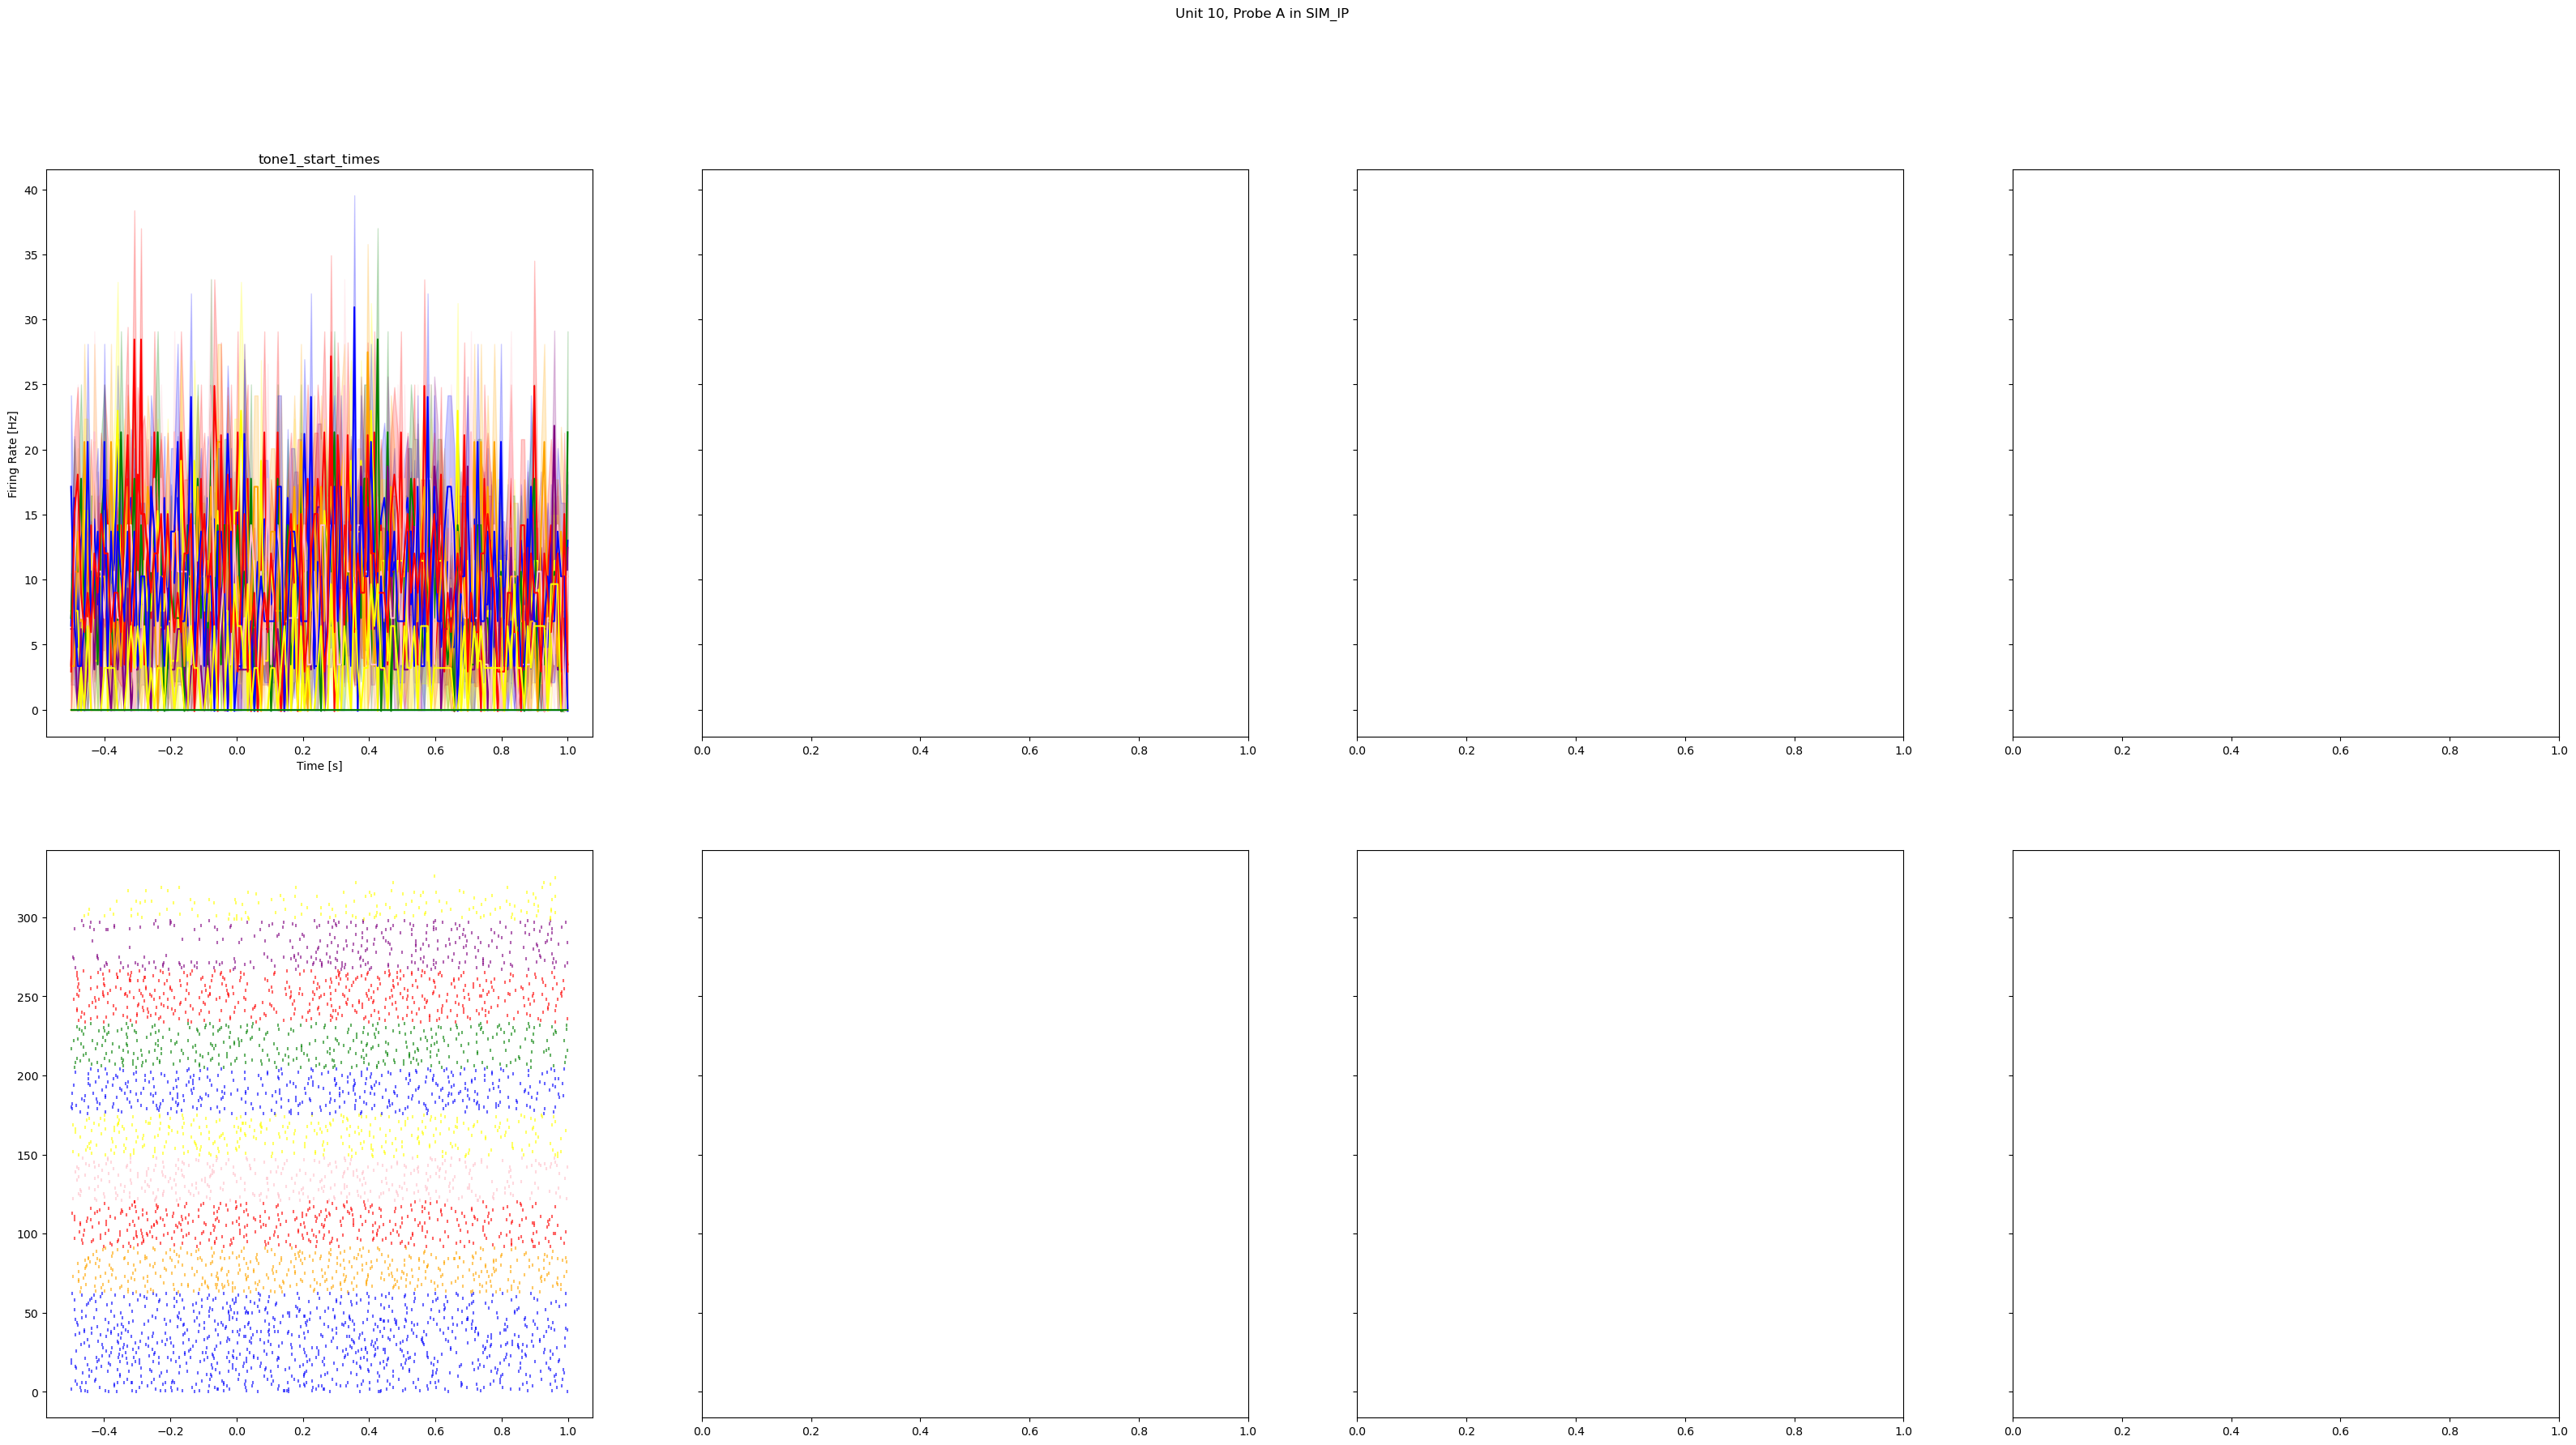

In [157]:
# main variables to set
save_dir = r"G:\Grant\neuropixels\kilosort_recordings\reach3_01_2024-11-14_21-30-18_001"
probe_letters = ['A', 'B', 'D', 'E']

# Dictionary mapping event names to event times
variables = {
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
    'stimROI_start_times': stimROI_start_times,
    # 'first_optical_pulse_per_closed_loop': first_optical_pulse_per_closed_loop,
    'first_opto_tagging_timestamp_per_trial': first_opto_tagging_timestamp_per_trial,
     
   }

# Mapping each probe to its corresponding brain region
probe_to_brain_region = {
    'A': 'SIM_IP',
    'B': 'PG',
    'D': 'VaL',
    'E': 'SnR',
}

trail_indices = {
    'optical_stim': trails_with_optical_stim,
    'no_optical_stim': trails_without_optical_stim,
}

# General parameters
KSlabel = True
label = False
all_units = False
pre = 0.5
post = 1
bin_size = 0.01

# Iterate over probes (DO NOT loop over `variables.items()` anymore)
for probeLetter in probe_letters:
    brain_region = probe_to_brain_region[probeLetter]  # Get the corresponding brain region

    # Construct the path (single directory for all event times)
    opto_tagging_path = f"{save_dir}\\analysis\\dlab_raster_psth\\psth_raster_all_events_seperated_by_color\\probe{probeLetter}"
    
    if not os.path.exists(opto_tagging_path):
        os.makedirs(opto_tagging_path)
        print('--Start--')
        print(f'Working on data from probe: {probeLetter}')
        print(f"Directory created: {opto_tagging_path}")
        print('Creating plots for all event times')
    
    else:
        # print(f"Directory already exists: {opto_tagging_path}")
        # print(f"Skipping raster and PSTH plots for all units in probe: {probeLetter}")
        continue

    # Generate plots for all event times in one figure
    psth_raster_all_events_seperated_by_color(
        df_units, df_stim, brain_region=brain_region, 
        variables=variables, trail_indices=trail_indices, probeLetter=probeLetter, 
        save_dir=opto_tagging_path, pre=pre, post=post, bin_size=bin_size,
        KSlabel=KSlabel, all_units=all_units
    )

## Smoothed Heatmap stacked, sorted by firing rate change
- will stack heatmaps of firing rates
- before running Z-score it smooths the data in selected binSize
- also aligne the units so the top unit of the plot has the max change in FR closest to pre time
- and the unit with max change in FR closest to the post time is at the bottom

In [1]:
def smooth_data(data, bin_size=20):
    """
    Smooth the data using a simple moving average.
    
    Args:
        data (ndarray): 1D array of firing rates (time bins).
        bin_size (int): The size of the smoothing window (in bins).

    Returns:
        smoothed_data (ndarray): Smoothed 1D data array.
    """
    kernel = np.ones(bin_size) / bin_size  # Moving average kernel

    smoothed_data = np.convolve(data, kernel, mode='same')
    return smoothed_data  # Ensure this is returned as 1D

from scipy.ndimage import gaussian_filter1d

def smooth_data(data, sigma=1.5):
    """
    Smooth the data using a Gaussian filter.
    
    Args:
        data (ndarray): 1D array of firing rates (time bins).
        sigma (float): The standard deviation for the Gaussian kernel.
                      A higher sigma results in more smoothing.
    
    Returns:
        smoothed_data (ndarray): Smoothed 1D data array.
    """
    return gaussian_filter1d(data, sigma=sigma)

In [ ]:

def sort_units_by_firing_rate_change(heatmap_data, time_axis, pre, post, bin_size, sort_by_time=False, smoothing_window=1.5):
    """
    Sort units based on the maximum firing rate change across the entire time window or by time of maximum change.
    """
    # Apply Gaussian smoothing before sorting
    smoothed_heatmap = np.array([smooth_data(row, smoothing_window) for row in heatmap_data])

    # Find the time bin with the maximum smoothed firing rate change for each unit
    max_change_times = np.argmax(np.abs(np.diff(smoothed_heatmap, axis=1)), axis=1)
    max_change_times = np.argmax(smoothed_heatmap, axis=1)


    if sort_by_time:
        # Sort strictly by time of the maximum change
        sorted_indices = np.argsort(max_change_times)
    else:
        # Sort by the magnitude of the maximum change in firing rate (descending)
        max_change_magnitudes = np.max(np.abs(np.diff(smoothed_heatmap, axis=1)), axis=1)
        sorted_indices = np.argsort(-max_change_magnitudes)
    
    return sorted_indices


In [ ]:

# New Code (full replacement of the function)
def multi_probe_units_heatmap_smoothed(
    df_units,
    df_stim,
    probes,
    selected_units=None,                     # kept for backward-compat (dict by probe)
    selected_units_by_subplot=None,          # New Code: list aligned to `probes`
    times_of_events=None,
    event_name=None,
    brain_regions=None,
    pre=0.5,
    post=1,
    bin_size=0.05,
    epoch1='pellet_detected_timestamp',
    label=False,
    KSlabel=True,
    save_dir=None,
    max_fr=60,
    show_unit_labels=True,
    normalize_fr=False,
    sort_by_time=True,
    reset_unit_count=False,
    smoothing_window=1
):
    """
    Generate separate heatmaps for each entry in `probes`.
    When the same probe letter appears multiple times, supply
    `selected_units_by_subplot` as a list of unit-id lists aligned
    positionally with `probes`.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    num_probes = len(probes)
    fig, axes = plt.subplots(num_probes, 1, figsize=(15, num_probes * 5))
    if num_probes == 1:
        axes = [axes]

    for idx, probeLetter in enumerate(probes):
        ax = axes[idx]

        # Filter by probe and quality label
        if label:
            df_probe = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
        elif KSlabel:
            df_probe = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
        else:
            df_probe = df_units[df_units.probe == probeLetter]

        # ---- New Code: pick units for THIS subplot ----
        if selected_units_by_subplot is not None:
            units_for_this_subplot = selected_units_by_subplot[idx]
            df_probe = df_probe[df_probe.index.isin(units_for_this_subplot)]
        elif selected_units is not None and probeLetter in selected_units:
            # legacy dict-by-probe path (works only if keys are unique)
            df_probe = df_probe[df_probe.index.isin(selected_units[probeLetter])]
        else:
            # nothing specified for this subplot -> skip
            continue

        if df_probe.empty:
            raise ValueError(f"No units for probe {probeLetter} at subplot index {idx}.")

        unit_index = df_probe.index.tolist()
        heatmap_data = []

        for unit in unit_index:
            spike_times = df_probe.loc[unit].spike_times
            event_times = times_of_events
            # user-defined helper assumed available:
            psth, _, _, bytrial = trial_by_trial(
                spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size
            )
            unit_heatmap_row = np.sum(bytrial, axis=0)
            unit_heatmap_row = smooth_data(unit_heatmap_row, smoothing_window)

            if normalize_fr:
                mean_fr = np.mean(unit_heatmap_row)
                std_fr = np.std(unit_heatmap_row)
                unit_heatmap_row = (unit_heatmap_row - mean_fr) / std_fr if std_fr != 0 else np.zeros_like(unit_heatmap_row)
            else:
                unit_heatmap_row = np.clip(unit_heatmap_row, 0, max_fr)

            heatmap_data.append(unit_heatmap_row)

        heatmap_data = np.squeeze(np.array(heatmap_data))
        time_axis = np.linspace(-pre, post, heatmap_data.shape[1])

        sorted_indices = sort_units_by_firing_rate_change(
            heatmap_data, time_axis, pre, post, bin_size, sort_by_time=sort_by_time, smoothing_window=smoothing_window
        )
        sorted_heatmap_data = heatmap_data[sorted_indices]
        sorted_unit_index = np.array(unit_index)[sorted_indices]

        vmin, vmax = (-2, 2) if normalize_fr else (0, max_fr)
        
        from matplotlib.colors import TwoSlopeNorm  # Add near imports

        # inside the plotting section:
        cmap = 'RdBu_r'  # red = positive, blue = negative, white = zero
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

        if reset_unit_count:
            yticklabels=np.arange(1, sorted_heatmap_data.shape[0] + 1) if show_unit_labels else False
        else:
            yticklabels=sorted_unit_index if show_unit_labels else False,



        sns.heatmap(
            sorted_heatmap_data,
            cmap=cmap,             # New
            norm=norm,             # New
            cbar=True,
            xticklabels=False,
            yticklabels=yticklabels,
            ax=ax,
            cbar_kws={"shrink": 0.6},
        )

        # num_ticks = 10
        # tick_positions = np.linspace(0, heatmap_data.shape[1] - 1, num_ticks).astype(int)
        # tick_labels = np.round(np.linspace(-pre, post, num_ticks), 2)

        # New Code
        tick_positions = np.linspace(0, heatmap_data.shape[1] - 1, int(pre + post) + 1).astype(int)
        tick_labels = np.arange(-int(pre), int(post) + 1, 1)

        zero_position = np.argmin(np.abs(np.linspace(-pre, post, heatmap_data.shape[1])))
        if 0 not in tick_labels:
            insert_at = np.searchsorted(tick_labels, 0)
            tick_positions = np.insert(tick_positions, insert_at, zero_position)
            tick_labels = np.insert(tick_labels, insert_at, 0)
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')

        if brain_regions:
            ax.set_ylabel(brain_regions[idx], rotation=0, labelpad=30, va='center')
        ax.set_xlabel("Time (s)")

    fig.suptitle(f"Aligned to {event_name}", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_dir:
        plt.savefig(f"{save_dir}/multi_probe_heatmap_{event_name}_{pre}_{post}.png", bbox_inches='tight')
        plt.savefig(f"{save_dir}/multi_probe_heatmap_{event_name}_{pre}_{post}.svg", bbox_inches='tight')
    plt.show()

In [ ]:
## Create Single Heatmaps using multi_probe_units_heatmap()
selected_units_A_SIM = [187,188,192,196,197,198,199,212,213,214,218,222,225,226,230,232,236,242,244,249,251,252,253,254,255,256]  #
selected_units_A_IP =  [0,11,12, 16, 18,19,20,25,26,36,39,49,52,57,62,67,69,88,93,103,137,148,151,152,158,159,176,180]  # Specify the unit IDs you want to include
selected_units_C = [1334,1349,1350,1352,1364,1368,1393,1396,1401,1404,1423,1424,1425,1426,1435,1436,1442,1443,1446,1447,1464,1470,1476,1481,1482,1492,1494,1510,1520,1523,1533,1534,1542,1544,1564,1566,1573,1575,1584,1598,1599,1601,1602,1610,1620,1626,1634,1641,1642,1660,1662,1663,1672,1675,1677,1683,1691,1698,1703,1707,1708,1710,1711,1727,1730,1732,1734,1744,1752,1766,1774,1797,1800,1803,1804,1805,1806,1812,1820,1821,1835,1848,1852,1854,1856,1859,1861,1862,1865,1868,1919,1029,]
selected_units_D = [1960,1961,1963,1983,1997,2000,2003,2007,2012,2015,2018,2021,2022,2029,2032,2038,2040,2041,2045,2047,2049,2050,2052,2053,2055,2061,2067,2069,2070,2071,2074,2075,2076,2079,2091,2100,2103,2106,2108,2110,2112,2113,2115,2117,2119,2121,2129,2131,2137,]

# old code
selected_units_dic = {
    'A': selected_units_A_SIM,
    'A': selected_units_A_IP,
    'C': selected_units_C,
    'D': selected_units_D,
}

# New Code
probe_letters = ['A','A','D','C']
brain_regions  = ['SIM','IP','VL','MoP']

selected_units_by_subplot = [
    selected_units_A_SIM,   # for probes[0] -> A SIM
    selected_units_A_IP,    # for probes[1] -> A IP
    selected_units_D,       # for probes[2] -> D VL
    selected_units_C,       # for probes[3] -> C MoP
]

multi_probe_units_heatmap_smoothed(
    df_units,
    df_stim,
    probes=probe_letters,
    brain_regions=brain_regions,
    times_of_events=reachInit_start_times,
    event_name='reachInit_start_times',
    pre=5, post=5,
    bin_size=0.01,
    max_fr=100,
    selected_units_by_subplot=selected_units_by_subplot,  # New Code
    save_dir=r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\post_kilosort\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\multi_probe_units_heatmap_smoothed_2025_11_03\5_5\ReachInit", 
    show_unit_labels=False,
    normalize_fr=True
)


# NOTHING BELLOW HERE IS WORKING CORRECTLY

## Old non working code

In [ ]:
import os

def allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=False, KSlabel=False,dot_size=0.5,pre=0.5, post=1, binSizeRaster=0.05, epoch1='pellet_delivery_timestamp', save_dir=None):
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel')  

    unit_index = df1.index.tolist()

    for unit in unit_index:
        # Create a single figure with 2 subplots
        f, ax = plt.subplots(2, 1, figsize=(10, 15))
        f.suptitle(f"Aligned to pellet detected; unit {unit}, probe {probeLetter} in {brain_region}", color='black')

        # Plot the PSTH in the first subplot
        ax[0].set_facecolor('white')
        ax[0].tick_params(color='black', labelcolor='black')
        for spine in ax[0].spines.values():
            spine.set_edgecolor('black')

        # this is to be able to get data for the raster plot, by using bytrial
        psth, var, edges, bytrial = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=binSizeRaster
        )

        # this is to be able to set a different bin size for the PSTH plot, by using edges_1 and psth_1
        psth_1, var_1, edges_1, bytrial_1 = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=0.025
        )
        
        ax[0].plot(edges_1, psth_1)
        ax[0].set_title("PSTH")

        # Plot the raster plot in the second subplot
        ax[1].set_facecolor('white')
        ax[1].tick_params(color='black', labelcolor='black')
        for spine in ax[1].spines.values():
            spine.set_edgecolor('black')
        
        # for trial_idx, trial in enumerate(bytrial):
        #     spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
        #     ax[1].scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)

        # Plot raster using bytrial
        for trial_idx, trial in enumerate(bytrial):
            plt.scatter(np.where(trial > 0)[0] * binSizeRaster - pre, [trial_idx] * np.count_nonzero(trial), color='black', s=dot_size)

        
        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")

        # Save the figure
        fig_filename = f"{save_dir}/unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(f)  # Close the figure to free up memory and avoid display

        # print(f"Saved figure for unit {unit} as {fig_filename} to {save_dir}")


In [ ]:
label = False
KSlabel = True
pre = 3
post = 3
binSizeRaster = 0.001
binsizePsth = 0.025
dot_size = 0.25
epoch1 = 'pellet_delivery_timestamp'
Savefig= True


save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeA\3s_3s"
probeLetter = "A"
brain_region = 'SIM_IP'
allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

## Epoch Raster Psth plots for every unit from a probe
-   This function works by you Selecting the epoch you want to use for time zero (this works by using the stimulus column in df_stim, and calling the associated timestamps in every row time zero for the plots )

In [16]:
import os

def allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=False, KSlabel=False,dot_size=0.5,pre=0.5, post=1, binSizeRaster=0.05, epoch1='pellet_delivery_timestamp', save_dir=None):
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel')  

    unit_index = df1.index.tolist()

    for unit in unit_index:
        # Create a single figure with 2 subplots
        f, ax = plt.subplots(2, 1, figsize=(10, 15))
        f.suptitle(f"Aligned to pellet detected; unit {unit}, probe {probeLetter} in {brain_region}", color='black')

        # Plot the PSTH in the first subplot
        ax[0].set_facecolor('white')
        ax[0].tick_params(color='black', labelcolor='black')
        for spine in ax[0].spines.values():
            spine.set_edgecolor('black')

        # this is to be able to get data for the raster plot, by using bytrial
        psth, var, edges, bytrial = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=binSizeRaster
        )

        # this is to be able to set a different bin size for the PSTH plot, by using edges_1 and psth_1
        psth_1, var_1, edges_1, bytrial_1 = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=0.025
        )
        
        ax[0].plot(edges_1, psth_1)
        ax[0].set_title("PSTH")

        # Plot the raster plot in the second subplot
        ax[1].set_facecolor('white')
        ax[1].tick_params(color='black', labelcolor='black')
        for spine in ax[1].spines.values():
            spine.set_edgecolor('black')
        
        # for trial_idx, trial in enumerate(bytrial):
        #     spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
        #     ax[1].scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)

        # Plot raster using bytrial
        for trial_idx, trial in enumerate(bytrial):
            plt.scatter(np.where(trial > 0)[0] * binSizeRaster - pre, [trial_idx] * np.count_nonzero(trial), color='black', s=dot_size)

        
        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")

        # Save the figure
        fig_filename = f"{save_dir}/unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(f)  # Close the figure to free up memory and avoid display

        # print(f"Saved figure for unit {unit} as {fig_filename} to {save_dir}")


In [ ]:
label = False
KSlabel = True
pre = 3
post = 3
binSizeRaster = 0.001
binsizePsth = 0.025
dot_size = 0.25
epoch1 = 'pellet_delivery_timestamp'
Savefig= True


save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeA\3s_3s"
probeLetter = "A"
brain_region = 'SIM_IP'
allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeB\3s_3s"
probeLetter = "B"
brain_region = 'SnR'
allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeC\3s_3s"
probeLetter = "C"
brain_region = 'MoP'
allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=label, dot_size=dot_size,KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeD\3s_3s"
probeLetter = "D"
brain_region = 'VL'
allUnits_psth_raster_epoch(df_units, df_stim, probeLetter, brain_region, label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

In [ ]:
df_stim.stimulus.unique()

## Selected Event_times Raster Psth plots for every unit from a probe
-   This function works by you Selecting the specifc event_times you want to use for time zero (ie. T5000_played, Pellet_deleivey, T6000_played, pellet_detected) 
- this works by taking in an array of timestamps, which should be relative to the neuropixel clock, and calling each value in that array time zero for the plots
- Mostly the timestamps are made by using the frame_numbers stimulus in the df_stim, since all frame numbers are recorded, indexing into that frame gives you the relaztuve time it occured for the neuropixel

In [135]:
import os

def allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region,event_times_to_use=None,label=False, KSlabel=False,dot_size=0.5,pre=0.5, post=1, binSizeRaster=0.05, epoch1='pellet_delivery_timestamp', save_dir=None):
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel')  

    unit_index = df1.index.tolist()

    for unit in unit_index:
        # Create a single figure with 2 subplots
        f, ax = plt.subplots(2, 1, figsize=(10, 15))
        f.suptitle(f"Aligned to pellet detected; unit {unit}, probe {probeLetter} in {brain_region}", color='black')

        # Plot the PSTH in the first subplot
        ax[0].set_facecolor('white')
        ax[0].tick_params(color='black', labelcolor='black')
        for spine in ax[0].spines.values():
            spine.set_edgecolor('black')

        # this is to be able to get data for the raster plot, by using bytrial
        psth, var, edges, bytrial = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == 'pellet_delivery_timestamp') & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=binSizeRaster
        )

        # this is to be able to set a different bin size for the PSTH plot, by using edges_1 and psth_1
        psth_1, var_1, edges_1, bytrial_1 = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == 'pellet_delivery_timestamp') & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=0.025
        )
        
        ax[0].plot(edges_1, psth_1)
        ax[0].set_title("PSTH")

        # Plot the raster plot in the second subplot
        ax[1].set_facecolor('white')
        ax[1].tick_params(color='black', labelcolor='black')
        for spine in ax[1].spines.values():
            spine.set_edgecolor('black')
        
        for trial_idx, trial in enumerate(bytrial):
            spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
            ax[1].scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)
        
        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")

        # Save the figure
        fig_filename = f"{save_dir}/unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(f)  # Close the figure to free up memory and avoid display

        # print(f"Saved figure for unit {unit} as {fig_filename} to {save_dir}")


In [ ]:
# event_times_to_use options
print(T6000_start_times[0], T5000_start_times[0], pellet_delivery_start_times[0], pellet_detected_start_times[0])
print(T6000_start_times[0]-T5000_start_times[0],T6000_start_times[0]-pellet_delivery_start_times[0],T6000_start_times[0]-pellet_detected_start_times[0])
print(T6000_start_times[1]-T5000_start_times[1],T6000_start_times[1]-pellet_delivery_start_times[1],T6000_start_times[1]-pellet_detected_start_times[1])
print(T6000_start_times[2]-T5000_start_times[2],T6000_start_times[2]-pellet_delivery_start_times[2],T6000_start_times[2]-pellet_detected_start_times[2])
print(T6000_start_times[3]-T5000_start_times[3],T6000_start_times[3]-pellet_delivery_start_times[3],T6000_start_times[3]-pellet_detected_start_times[3])




In [ ]:
import os

# Define parameters
label = False
KSlabel = True
pre = 3
post = 3
binSizeRaster = 0.001
binsizePsth = 0.025
dot_size = 0.25
Savefig = True
event_times_to_use = T6000_start_times

# Function to check and create the folder based on the save_dir and pre/post
def create_save_dir(save_dir, pre, post):
    pre_post_folder = f"{pre}_{post}"
    full_save_dir = os.path.join(save_dir, pre_post_folder)
    if not os.path.exists(full_save_dir):
        os.makedirs(full_save_dir)
        print(f"Created directory: {full_save_dir}")
    return full_save_dir

# Probe A
save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeA\T6000_start_times"
probeLetter = "A"
brain_region = 'SIM_IP'

# Check/create folder and pass the new save_dir to the function
full_save_dir_A = create_save_dir(save_dir, pre, post)
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region, 
                                       event_times_to_use=event_times_to_use, label=label, 
                                       dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, 
                                       binSizeRaster=binSizeRaster, save_dir=full_save_dir_A)

# Probe B
save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeB\T6000_start_times"
probeLetter = "B"
brain_region = 'SnR'

# Check/create folder and pass the new save_dir to the function
full_save_dir_B = create_save_dir(save_dir, pre, post)
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region, 
                                       event_times_to_use=event_times_to_use, label=label, 
                                       dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, 
                                       binSizeRaster=binSizeRaster, save_dir=full_save_dir_B)

# Probe C
save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeC\T6000_start_times"
probeLetter = "C"
brain_region = 'MoP'

# Check/create folder and pass the new save_dir to the function
full_save_dir_C = create_save_dir(save_dir, pre, post)
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region, 
                                       event_times_to_use=event_times_to_use, label=label, 
                                       dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, 
                                       binSizeRaster=binSizeRaster, save_dir=full_save_dir_C)

# Probe D
save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeD\T6000_start_times"
probeLetter = "D"
brain_region = 'VL'

# Check/create folder and pass the new save_dir to the function
full_save_dir_D = create_save_dir(save_dir, pre, post)
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region, 
                                       event_times_to_use=event_times_to_use, label=label, 
                                       dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, 
                                       binSizeRaster=binSizeRaster, save_dir=full_save_dir_D)


In [ ]:
label = False
KSlabel = True
pre = 2
post = 10
binSizeRaster = 0.001
binsizePsth = 0.025
dot_size = 0.25
Savefig= True
event_times_to_use = T6000_start_times


save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeA"
probeLetter = "A"
brain_region = 'SIM_IP'
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region,event_times_to_use=event_times_to_use, label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeB"
probeLetter = "B"
brain_region = 'SnR'
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region, event_times_to_use=event_times_to_use,label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeC"
probeLetter = "C"
brain_region = 'MoP'
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region,event_times_to_use=event_times_to_use ,label=label, dot_size=dot_size,KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\trial_by_trial\probeD"
probeLetter = "D"
brain_region = 'VL'
allUnits_psth_raster_select_eventTimes(df_units, df_stim, probeLetter, brain_region,event_times_to_use=event_times_to_use ,label=label,dot_size=dot_size, KSlabel=KSlabel, pre=pre, post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

## Single unit raster and PSTH aligned to reachInit


In [261]:
# import os

# def allUnits_psth_raster_select_startTime(df_units, probeLetter, brain_region,start_times=start_times,dot_size=0.5, label=False, KSlabel=False,use_reachInit=True,use_epoch=False, pre=0.5, post=1, binSizeRaster=0.05, epoch1='pellet_delivery_timestamp', save_dir=None):
   
#     if label:
#         df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
#         print('using label')
#     if KSlabel:
#         df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
#         print('using KSlabel')  

#     unit_index = df1.index.tolist()

#     for unit in unit_index:
#         # Create a single figure with 2 subplots
#         f, ax = plt.subplots(2, 1, figsize=(10, 15))
#         f.suptitle(f"Aligned to pellet detected; unit {unit}, probe {probeLetter} in {brain_region}", color='black')

#         # Plot the PSTH in the first subplot
#         ax[0].set_facecolor('white')
#         ax[0].tick_params(color='black', labelcolor='black')
#         for spine in ax[0].spines.values():
#             spine.set_edgecolor('black')

        

#         if use_reachInit:
#             # this is to be able to get data for the raster plot, by using bytrial
#             psth, var, edges, bytrial = trial_by_trial(
#                 spike_times=df1[df1.index == unit].spike_times.values[0],
#                 event_times=start_times,
#                 pre=pre, post=post, bin_size=binSizeRaster
#             )

#             # this is to be able to set a different bin size for the PSTH plot, by using edges_1 and psth_1
#             psth_1, var_1, edges_1, bytrial_1 = trial_by_trial(
#                 spike_times=df1[df1.index == unit].spike_times.values[0],
#                 event_times=start_times,
#                 pre=pre, post=post, bin_size=0.025
#             )

#         if use_epoch:
#             # this is to be able to get data for the raster plot, by using bytrial
#             psth, var, edges, bytrial = trial_by_trial(
#                 spike_times=df1[df1.index == unit].spike_times.values[0],
#                 event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
#                 pre=pre, post=post, bin_size=binSizeRaster
#             )

#             # this is to be able to set a different bin size for the PSTH plot, by using edges_1 and psth_1
#             psth_1, var_1, edges_1, bytrial_1 = trial_by_trial(
#                 spike_times=df1[df1.index == unit].spike_times.values[0],
#                 event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
#                 pre=pre, post=post, bin_size=0.025
#             )
        
            
#         ax[0].plot(edges_1, psth_1)
#         ax[0].set_title("PSTH")

#         # Plot the raster plot in the second subplot
#         ax[1].set_facecolor('white')
#         ax[1].tick_params(color='black', labelcolor='black')
#         for spine in ax[1].spines.values():
#             spine.set_edgecolor('black')
        
#         for trial_idx, trial in enumerate(bytrial):
#             spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
#             ax[1].scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)
        
#         ax[1].set_title("Raster Plot")
#         ax[1].set_ylabel("Trial")
#         ax[1].set_xlabel("Time (s)")

#         # Save the figure
#         fig_filename = f"{save_dir}/unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
#         plt.savefig(fig_filename, bbox_inches='tight')
#         plt.close(f)  # Close the figure to free up memory and avoid display

#         # print(f"Saved figure for unit {unit} as {fig_filename} to {save_dir}")


In [378]:
# probeLetter = "ChangeMe"
# brain_region = "ChangeMe"
# save_dir = "ChangeMe"

# label = False
# KSlabel = True
# pre = 0.5
# post = 1
# binSizeRaster = 0.001
# binsizePsth = 0.025
# dot_size = 0.75
# Savefig= True

# ##---- Set your start time -----
# #start_times = reachInit_start_times
# #start_times = T5000_start_times
# #start_times = T6000_start_times
# start_times = pellet_delivery_start_times
# #start_times = pellet_detected_start_times

# ### --- SET THIS ---
# use_reachInit = True
# use_epoch = False


# save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\allUnits_psth_raster_select_startTime\probeA\pellet_delivery\0.5s_1s"
# probeLetter = "A"
# brain_region = 'SIM_IP'
# allUnits_psth_raster_select_startTime(df_units, probeLetter, brain_region,start_times=start_times, label=label, KSlabel=KSlabel,use_reachInit=use_reachInit,use_epoch=use_epoch ,pre=pre,dot_size=dot_size ,post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

# save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\allUnits_psth_raster_select_startTime\probeB\T5000_played\0.5s_1s"
# probeLetter = "B"
# brain_region = 'SnR'
# allUnits_psth_raster_select_startTime(df_units, probeLetter, brain_region,start_times=start_times, label=label, KSlabel=KSlabel,use_reachInit=use_reachInit,use_epoch=use_epoch ,pre=pre,dot_size=dot_size ,post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

# save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\allUnits_psth_raster_select_startTime\probeC\T5000_played\0.5s_1s"
# probeLetter = "C"
# brain_region = 'MoP'
# allUnits_psth_raster_select_startTime(df_units, probeLetter, brain_region,start_times=start_times, label=label, KSlabel=KSlabel,use_reachInit=use_reachInit,use_epoch=use_epoch ,pre=pre,dot_size=dot_size ,post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)

# save_dir = r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\allUnits_psth_raster_select_startTime\probeD\T5000_played\0.5s_1s"
# probeLetter = "D"
# brain_region = 'VL'
# allUnits_psth_raster_select_startTime(df_units, probeLetter, brain_region,start_times=start_times, label=label, KSlabel=KSlabel,use_reachInit=use_reachInit,use_epoch=use_epoch ,pre=pre,dot_size=dot_size ,post=post, binSizeRaster=binSizeRaster, epoch1=epoch1, save_dir=save_dir)


## Plot the PSTH and raster for all units in probe 
- this saves on figure for each unit in a probe, this figure has a psth and raster plot
- you can toggle between KSlabel and label (KSlabel = Kilosort's "good" units), (label = your PHY curaterd "good" units)

In [ ]:
import os

def allUnits_psth_raster_figures(df_units, df_stim, probeLetter, brain_region, label=False, KSlabel=False, pre=0.5, post=1, binSizeRaster=0.05, epoch1='pellet_detected_timestamp', save_dir=None):
    if label:
        df1 = df_units[df_units.probe == probeLetter][df_units.label == 2]
        print('using label')
    if KSlabel:
        df1 = df_units[df_units.probe == probeLetter][df_units.KSlabel == 2]
        print('using KSlabel')  

    unit_index = df1.index.tolist()

    for unit in unit_index:
        # Create a single figure with 2 subplots
        f, ax = plt.subplots(2, 1, figsize=(10, 15))
        f.suptitle(f"Aligned to pellet detected; unit {unit}, probe {probeLetter} in {brain_region}", color='black')

        # Plot the PSTH in the first subplot
        ax[0].set_facecolor('white')
        ax[0].tick_params(color='black', labelcolor='black')
        for spine in ax[0].spines.values():
            spine.set_edgecolor('black')

        # this is to be able to get data for the raster plot, by using bytrial
        psth, var, edges, bytrial = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=binSizeRaster
        )

        # this is to be able to set a different bin size for the PSTH plot, by using edges_1 and psth_1
        psth_1, var_1, edges_1, bytrial_1 = trial_by_trial(
            spike_times=df1[df1.index == unit].spike_times.values[0],
            event_times=df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values,
            pre=pre, post=post, bin_size=0.025
        )
        
        ax[0].plot(edges_1, psth_1)
        ax[0].set_title("PSTH")

        # Plot the raster plot in the second subplot
        ax[1].set_facecolor('white')
        ax[1].tick_params(color='black', labelcolor='black')
        for spine in ax[1].spines.values():
            spine.set_edgecolor('black')
        
        for trial_idx, trial in enumerate(bytrial):
            spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
            ax[1].scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=1)
        
        ax[1].set_title("Raster Plot")
        ax[1].set_ylabel("Trial")
        ax[1].set_xlabel("Time (s)")

        # Save the figure
        fig_filename = f"{save_dir}/unit_{unit}_probe_{probeLetter}_region_{brain_region}.png"
        plt.savefig(fig_filename, bbox_inches='tight')
        plt.close(f)  # Close the figure to free up memory and avoid display

        # print(f"Saved figure for unit {unit} as {fig_filename} to {save_dir}")


## multi-brain region raster plots 

In [102]:
import os
import matplotlib.pyplot as plt
import numpy as np

def multiRegion_raster_figures(df_units, df_stim, brain_regions, 
                               probe_units, probe_letters=['A', 'B', 'C', 'D'], 
                               label=False, KSlabel=False, 
                               pre=0.5, post=1, binSizeRaster=0.05, 
                               epoch1='pellet_delivery_timestamp', save_dir=None, 
                               highlight_time_zero=False,dot_size=0.25, background_colors=None):
    # Prepare unit filtering based on label or KSlabel
    label_key = 'label' if label else 'KSlabel' if KSlabel else None
    if label_key:
        df_probes = [df_units[(df_units.probe == probe) & (df_units[label_key] == 2)] 
                     for probe in probe_letters]
    else:
        df_probes = [df_units[df_units.probe == probe] for probe in probe_letters]

    # Create a figure with stacked subplots for each region
    fig, axs = plt.subplots(len(probe_letters), 1, figsize=(10, len(probe_letters)*2), sharex=True)
    fig.suptitle(f"Aligned to {epoch1}; Units {probe_units} in {brain_regions}", color='black')

    # If no background colors are provided, default to light pastel shades
    if background_colors is None:
        background_colors = ['#f0f8ff', '#fafad2', '#e6e6fa', '#fff0f5']  # Example pastel colors

    for i, (probe, unit, region, ax) in enumerate(zip(probe_letters, probe_units, brain_regions, axs)):
        # Fetch unit's data
        df_probe = df_probes[i]
        if unit not in df_probe.index:
            print(f"Unit {unit} not found for probe {probe}. Skipping.")
            continue
        
        spike_times = df_probe.loc[unit].spike_times
        event_times = df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values

        # Calculate raster data
        _, _, _, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, 
                                          pre=pre, post=post, bin_size=binSizeRaster)
        
        # Set a unique light color background for each raster plot
        ax.set_facecolor(background_colors[i % len(background_colors)])  # Rotate through provided colors
        ax.tick_params(color='black', labelcolor='black')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')

        # Plot raster data
        for trial_idx, trial in enumerate(bytrial):
            spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
            ax.scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)

        # Add a gray highlighted box around time zero if the option is enabled
        if highlight_time_zero:
            ax.axvspan(0, 0.001, color='gray', alpha=0.5)  # Thin vertical box at t=0

        ax.set_title(f"Region: {region}, Unit: {unit}")
        ax.set_ylabel(region)

    axs[-1].set_xlabel("Time (s)")
    
    # Save the figure
    fig_filename = os.path.join(save_dir, f"multi_region_raster_units_{probe_units}.png")
    plt.savefig(fig_filename, bbox_inches='tight')
    plt.close(fig)  # Close to free memory
    print(f"Saved multi-region raster plot as {fig_filename}")


In [ ]:
multiRegion_raster_figures(
    df_units=df_units, 
    df_stim=df_stim, 
    epoch1='pellet_delivery_timestamp',
    brain_regions=["SIM",'IP', "SNr", "VL", "MoP"], 
    probe_units=[222,602, 953, 1963,1350],  # specify the units for each probe
    probe_letters=['A','A' ,'B','D', 'C' ], 
    label=False, 
    pre=0.5, post=1, 
    binSizeRaster=0.001, 
    dot_size=0.1,
    highlight_time_zero=True,
    save_dir= r'E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\multiRegion_raster_figures\test1'
)

## multi-brain region raster & psth plots
- Creates a stacked raster plot for however many probes/brain regions you select
- the PSTH plot is not normalized, do large changes in firing rate will drawf the smaller changes
- the function 

In [1231]:
import matplotlib.colors as mcolors
import os
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors as mcolors
from colorsys import rgb_to_hls, hls_to_rgb

def make_color_vibrant(color, saturation_increase=0.5, lightness_decrease=0.1):
    """
    Makes the given color more vibrant by increasing saturation and optionally reducing lightness.
    Input should be a valid matplotlib color format.
    `saturation_increase`: Amount to increase the saturation (0 to 1).
    `lightness_decrease`: Amount to decrease lightness (0 to 1).
    """
    # Convert the color to RGB
    rgb = np.array(mcolors.to_rgb(color))
    # Convert RGB to HLS (Hue, Lightness, Saturation)
    h, l, s = rgb_to_hls(*rgb)
    
    # Increase saturation and slightly reduce lightness to make the color more vibrant
    s = min(1, s + saturation_increase)  # Cap saturation at 1
    l = max(0, l - lightness_decrease)  # Ensure lightness doesn't go below 0
    
    # Convert back to RGB
    vibrant_rgb = hls_to_rgb(h, l, s)
    
    # Convert back to HEX for matplotlib
    return mcolors.to_hex(vibrant_rgb)


# Vibrant color function
def make_color_vibrant(color, saturation_increase=0.5, lightness_decrease=0.1):
    rgb = np.array(mcolors.to_rgb(color))
    h, l, s = rgb_to_hls(*rgb)
    s = min(1, s + saturation_increase)  # Increase saturation
    l = max(0, l - lightness_decrease)   # Slightly reduce lightness
    return mcolors.to_hex(hls_to_rgb(h, l, s))

def multiRegion_raster_psth_figures(df_units, df_stim, brain_regions, 
                               probe_units, probe_letters=['A', 'B', 'C', 'D'], 
                               label=False, KSlabel=False,  # Clarified labels
                               pre=0.5, post=1, binSizeRaster=0.05, binSizePSTH=0.025,
                               epoch1='pellet_detected_timestamp', save_dir=None, 
                               highlight_time_zero=False, normalize_psth=False,
                               dot_size=5, background_colors=None):
    # Ensure only one of label or KSlabel is True, raise an error if both are set
    if label and KSlabel:
        raise ValueError("You can only specify either 'label' or 'KSlabel', not both.")
    
    # Prepare unit filtering based on label or KSlabel
    if label:
        df_probes = [df_units[(df_units.probe == probe) & (df_units.label == 2)] for probe in probe_letters]
        print('Using label for filtering.')
    elif KSlabel:
        df_probes = [df_units[(df_units.probe == probe) & (df_units.KSlabel == 2)] for probe in probe_letters]
        print('Using KSlabel for filtering.')
    else:
        df_probes = [df_units[df_units.probe == probe] for probe in probe_letters]
        print('Using all data without filtering.')

    # Create a figure with 1 PSTH plot at the top and stacked subplots for each region
    fig, axs = plt.subplots(len(probe_letters) + 1, 1, figsize=(10, (len(probe_letters) + 1) * 2), sharex=True)
    fig.suptitle(f"Aligned to {epoch1}; Units {probe_units} in {brain_regions}", color='black')

    # If no background colors are provided, default to light pastel shades
    if background_colors is None:
        background_colors = ['#f0f8ff', '#fafad2', '#e6e6fa', '#fff0f5', '#d1e7dd']  # Added a 5th pastel green

    # First plot will be the PSTH plot
    psth_ax = axs[0]

    for i, (probe, unit, region, ax) in enumerate(zip(probe_letters, probe_units, brain_regions, axs[1:])):
        # Fetch unit's data
        df_probe = df_probes[i]
        if unit not in df_probe.index:
            print(f"Unit {unit} not found for probe {probe}. Skipping.")
            continue
        
        spike_times = df_probe.loc[unit].spike_times
        event_times = df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values

        # Calculate raster data with larger bin size
        _, _, _, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, 
                                          pre=pre, post=post, bin_size=binSizeRaster)

        # Calculate PSTH data with smaller bin size
        psth, _, edges, _ = trial_by_trial(spike_times=spike_times, event_times=event_times, 
                                           pre=pre, post=post, bin_size=binSizePSTH)

        # Set a unique light color background for each raster plot
        ax.set_facecolor(background_colors[i % len(background_colors)])  # Rotate through provided colors
        ax.tick_params(color='black', labelcolor='black')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')

        # Plot raster data
        for trial_idx, trial in enumerate(bytrial):
            spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
            ax.scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)

        # Add a gray highlighted box around time zero if the option is enabled
        if highlight_time_zero:
            ax.axvspan(0, 0.001, color='gray', alpha=0.5)  # Thin vertical box at t=0

        ax.set_title(f"Region: {region}, Unit: {unit}")
        ax.set_ylabel(region)

        # Make the background color more vibrant for the PSTH line
        vibrant_color = make_color_vibrant(background_colors[i % len(background_colors)], saturation_increase=0.5, lightness_decrease=0.1)

        # Add the PSTH line to the top PSTH plot, using the vibrant color
        psth_ax.plot(edges[:-1], psth[:len(edges[:-1])], label=f'{region}', color=vibrant_color, lw=2)

    # Formatting for PSTH plot
    psth_ax.set_title("PSTH - All Brain Regions")
    psth_ax.set_ylabel("Firing Rate")
    psth_ax.legend(loc="upper right")
    psth_ax.set_facecolor('white')
    psth_ax.grid(True)

    # Label the x-axis on the last subplot
    axs[-1].set_xlabel("Time (s)")
    
    # Save the figure
    fig_filename = os.path.join(save_dir, f"multi_region_psth_raster_units_{probe_units}.png")
    plt.savefig(fig_filename, bbox_inches='tight')
    plt.close(fig)  # Close to free memory
    print(f"Saved multi-region PSTH & raster plot as {fig_filename}")


In [ ]:
multiRegion_raster_psth_figures(
    df_units=df_units, 
    df_stim=df_stim, 
    KSlabel=True,  # Use KSlabel filtering
    label=False, 
    epoch1='pellet_delivery_timestamp',
    brain_regions=["SIM",'IP', "SNr", "VL", "MoP"], 
    probe_units=[222,602, 953, 2012,1404],  # specify the units for each probe
    probe_letters=['A','A' ,'B','D', 'C' ], 
    pre=0.5, post=1, 
    binSizeRaster=0.001, 
    binSizePSTH = 0.025,
    dot_size=0.1,
    highlight_time_zero=False,
    save_dir= r'E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\multiRegion_raster_psth_figures\regular_psth\0.25ms_0.25ms'
)

## Raster Plots w/ Normalized psth
- Allows you to stack multiple probes raster plots
- it also allows you to normalize the change in firing rate for the PSTH plot

In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from colorsys import rgb_to_hls, hls_to_rgb

# Vibrant color function
def make_color_vibrant(color, saturation_increase=0.5, lightness_decrease=0.1):
    rgb = np.array(mcolors.to_rgb(color))
    h, l, s = rgb_to_hls(*rgb)
    s = min(1, s + saturation_increase)  # Increase saturation
    l = max(0, l - lightness_decrease)   # Slightly reduce lightness
    return mcolors.to_hex(hls_to_rgb(h, l, s))

def multiRegion_raster_psth_normalized(df_units, df_stim, brain_regions, 
                               probe_units, probe_letters=['A', 'B', 'C', 'D'], 
                               label=False, KSlabel=False,  # Clarified labels
                               pre=0.5, post=1, binSizeRaster=0.05, binSizePSTH=0.025,event_times=None,
                               epoch1='pellet_detected_timestamp', save_dir=None, 
                               highlight_time_zero=False, normalize_psth=False,
                               dot_size=5, background_colors=None):
    # Ensure only one of label or KSlabel is True, raise an error if both are set
    if label and KSlabel:
        raise ValueError("You can only specify either 'label' or 'KSlabel', not both.")
    
    # Prepare unit filtering based on label or KSlabel
    if label:
        df_probes = [df_units[(df_units.probe == probe) & (df_units.label == 2)] for probe in probe_letters]
        print('Using label for filtering.')
    elif KSlabel:
        df_probes = [df_units[(df_units.probe == probe) & (df_units.KSlabel == 2)] for probe in probe_letters]
        print('Using KSlabel for filtering.')
    else:
        df_probes = [df_units[df_units.probe == probe] for probe in probe_letters]
        print('Using all data without filtering.')
        
    # Create a figure with 1 PSTH plot at the top and stacked subplots for each region
    fig, axs = plt.subplots(len(probe_letters) + 1, 1, figsize=(10, (len(probe_letters) + 1) * 2), sharex=True)
    fig.suptitle(f"Aligned to {epoch1}; Units {probe_units} in {brain_regions}", color='black')

    # If no background colors are provided, default to light pastel shades
    if background_colors is None:
        background_colors = ['#f0f8ff', '#FFB347', '#e6e6fa', '#fff0f5', '#d1e7dd']

    # First plot will be the PSTH plot
    psth_ax = axs[0]

    for i, (probe, unit, region, ax) in enumerate(zip(probe_letters, probe_units, brain_regions, axs[1:])):
        # Fetch unit's data
        df_probe = df_probes[i]
        if unit not in df_probe.index:
            print(f"Unit {unit} not found for probe {probe}. Skipping.")
            continue
        
        spike_times = df_probe.loc[unit].spike_times
        event_times = event_times

        # Calculate raster data with larger bin size
        _, _, _, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, 
                                          pre=pre, post=post, bin_size=binSizeRaster)

        # Calculate PSTH data with smaller bin size
        psth, _, edges, _ = trial_by_trial(spike_times=spike_times, event_times=event_times, 
                                           pre=pre, post=post, bin_size=binSizePSTH)

        # Optionally normalize the PSTH
        if normalize_psth:
            psth = psth / np.max(psth) if np.max(psth) != 0 else psth  # Avoid division by zero

        # Set a unique light color background for each raster plot
        ax.set_facecolor(background_colors[i % len(background_colors)])  # Rotate through provided colors
        ax.tick_params(color='black', labelcolor='black')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')

        # Plot raster data
        for trial_idx, trial in enumerate(bytrial):
            spike_times_in_trial = np.where(trial > 0)[0] * binSizeRaster - pre  # convert bin indices back to time
            ax.scatter(spike_times_in_trial, [trial_idx] * len(spike_times_in_trial), color='black', s=dot_size)

        # Add a gray highlighted box around time zero if the option is enabled
        if highlight_time_zero:
            ax.axvspan(0, 0.001, color='gray', alpha=0.5)  # Thin vertical box at t=0

        # ax.set_title(f"Region: {region}, Unit: {unit}")
        # ax.set_ylabel(region)
        ax.set_ylabel(region, rotation=0, labelpad=30, va='center')


        # Make the background color more vibrant for the PSTH line
        vibrant_color = make_color_vibrant(background_colors[i % len(background_colors)], saturation_increase=0.5, lightness_decrease=0.1)

        # Add the PSTH line to the top PSTH plot, using the vibrant color
        psth_ax.plot(edges[:-1], psth[:len(edges[:-1])], label=f'{region}', color=vibrant_color, lw=2)

    # Formatting for PSTH plot
    psth_ax.set_title("PSTH - All Brain Regions")
    psth_ax.set_ylabel("Firing Rate (normalized)" if normalize_psth else "Firing Rate")
    psth_ax.legend(loc="upper right")
    psth_ax.set_facecolor('white')
    psth_ax.grid(True)

    # Label the x-axis on the last subplot
    axs[-1].set_xlabel("Time (s)")
    
    # Save the figure
    fig_filename = os.path.join(save_dir, f"multi_region_psth_raster_units_{probe_units}.png")
    plt.savefig(fig_filename, bbox_inches='tight')
    plt.close(fig)  # Close to free memory
    print(f"Saved multi-region PSTH & raster plot as {fig_filename}")


In [ ]:
probe_units=[632,25, 1017, 2012,1404]  # specify the units for each probe
probe_units=[632,25, 1017, 2012,1865]  # specify the units for each probe

#probe_units = [632, 18, 964, 2000, 1368],  # List of unit numbers, 


multiRegion_raster_psth_normalized(
    df_units=df_units, 
    df_stim=df_stim, 
    epoch1='pellet_delivery_timestamp',
    event_times = reachInit_start_times,
    brain_regions=["SIM",'IP', "SNr", "VL", "MoP"], 
    probe_units = probe_units,  # List of unit numbers, 
    probe_letters=['A','A' ,'B','D', 'C' ], 
    KSlabel=True,  # Use KSlabel filtering
    label=False, 
    pre=2, post=3, 
    binSizeRaster=0.001, 
    binSizePSTH = 0.01,
    dot_size=0.05,
    normalize_psth=True,  # Normalize the PSTH lines
    highlight_time_zero=False,
    save_dir= r'E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\multiRegion_raster_psth_figures\normalized_psth\2_3\Reachinit'
)


## Check the depth of the units
- Allows you to check the relative depth of each unit 
- Important: the relative depth is compared to what you set probedepth too when making the nwb. For example if you set probeA to probedepth=2500, but the probe was really all the way into the brain (ie. 3800um) the units at the top of the probe will appear as -1300. and the units at the tip of the probe will say 2500, even though they were actually 3800um deep in the brain

In [1147]:
probeids = ['A', 'B','C','D'] 
probedepths = [2500,4500,1000,3800] 

selected_units_A = [0,11,12, 16, 18,19,20,25,26,36,39,49,52,57,62,67,69,88,93,103,137,148,151,152,158,159,176,180,187,188,192,196,197,198,199,212,213,214,218,222,225,226,230,232,236,242,244,249,251,252,253,254,255,256]  # Specify the unit IDs you want to include
selected_units_B = [867,868,869,872,873,875,876,878,879,882,895,896,897,898,901,903,905,911,912,913,914,916,918,920,922,924,926,927,928,929,930,931,933,934,935,936,937,938,939,941,942,944,945,946,947,948,950,951,952,953,954,956,958,959,960,961,962,963,964,967,968,696,971,972,973,975,977,978,979,980,981,983,984,985,986,987,990,992,994,1000,1002,1003,1004,1005,1006,1007,1009,1011,1012,1013,1015,1016,1017,1018,1019,1020,1022,1023,1025,1027,1028,1029,1030,1031,1033,1035,1037,1038,1040,1041,1042,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1056,1057,1059,1060,1063,1065,1066,1067,1068,1070,1071,1072,1073,1074,1075,1076,1077,1079,1080,1081,1082,1083,1084,1085,1086,1087,]
selected_units_C = [1334,1349,1350,1352,1364,1368,1393,1396,1401,1404,1423,1424,1425,1426,1435,1436,1442,1443,1446,1447,1464,1470,1476,1481,1482,1492,1494,1510,1520,1523,1533,1534,1542,1544,1564,1566,1573,1575,1584,1598,1599,1601,1602,1610,1620,1626,1634,1641,1642,1660,1662,1663,1672,1675,1677,1683,1691,1698,1703,1707,1708,1710,1711,1727,1730,1732,1734,1744,1752,1766,1774,1797,1800,1803,1804,1805,1806,1812,1820,1821,1835,1848,1852,1854,1856,1859,1861,1862,1865,1868,1919,1029,]
selected_units_D = [1960,1961,1963,1983,1997,2000,2003,2007,2012,2015,2018,2021,2022,2029,2032,2038,2040,2041,2045,2047,2049,2050,2052,2053,2055,2061,2067,2069,2070,2071,2074,2075,2076,2079,2091,2100,2103,2106,2108,2110,2112,2113,2115,2117,2119,2121,2129,2131,2137,]



In [ ]:
probe_units = [2137, 2069, 1960]  # List of unit numbers
probe_units = selected_units_D
probe_letters = ['D', 'D', 'D']  # Corresponding probe letters


for letter in probe_units:
    probe_letters.append(probeids['D'])

# Loop through each unit number and probe letter
for unit_number, probe_letter in zip(probe_units, probe_letters):
    unit_data = df_units[df_units.index == unit_number]  # Ensure we filter by unit index
    
    # Check if the unit exists in df_units
    if not unit_data.empty:
        probe_depth = unit_data['depth'].values[0]
        probe_letter = unit_data['probe'].values[0]  # Make sure probe is correct if listed in df
        print(f"Unit {unit_number} | Probe Depth: {probe_depth}, Probe Letter: {probe_letter}")
    else:
        print(f"Unit number {unit_number} not found in df_units.")


## Heat Maps
-  Single Probe at a time
- can use Selected Units

In [1209]:
def probe_units_heatmap(df_units, df_stim, probeLetter, selected_units=None, pre=0.5, post=1, bin_size=0.05, epoch1='pellet_detected_timestamp', label=False, KSlabel=True, save_dir=None, max_fr=60, show_unit_labels=True, normalize_fr=False):
    # Ensure only one of label or KSlabel is True, raise an error if both are set
    if label and KSlabel:
        raise ValueError("You can only specify either 'label' or 'KSlabel', not both.")

    # Prepare unit filtering based on label or KSlabel
    if label:
        df_probe = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
        print('Using label for filtering.')
    elif KSlabel:
        df_probe = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
        print('Using KSlabel for filtering.')
    else:
        df_probe = df_units[df_units.probe == probeLetter]
        print('Using all data without filtering.')

    # If specific units are provided, filter df_probe by these units
    if selected_units:
        df_probe = df_probe[df_probe.index.isin(selected_units)]
        if df_probe.empty:
            raise ValueError(f"No units from the selected list {selected_units} are found in the probe {probeLetter}.")

    unit_index = df_probe.index.tolist()  # List of all units in this probe (filtered by selected units if provided)

    # Reverse the unit list to have the last unit at the top of the plot
    unit_index = unit_index[::-1]

    heatmap_data = []

    # Loop through each unit
    for unit in unit_index:
        spike_times = df_probe.loc[unit].spike_times
        event_times = df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values
        
        # Calculate trial-by-trial spike binning (heatmap row for this unit)
        psth, _, _, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size)
        
        # Flatten all trials into a single row for this unit (sum of all trials)
        unit_heatmap_row = np.sum(bytrial, axis=0)

        # Normalize the firing rate if normalize_fr is True
        if normalize_fr:
            mean_fr = np.mean(unit_heatmap_row)
            std_fr = np.std(unit_heatmap_row)
            if std_fr != 0:
                unit_heatmap_row = (unit_heatmap_row - mean_fr) / std_fr  # Z-score normalization
            else:
                unit_heatmap_row = np.zeros_like(unit_heatmap_row)  # If no variance, make it zero

        # Cap the firing rate at the max_fr value (only if not normalizing)
        if not normalize_fr:
            unit_heatmap_row = np.clip(unit_heatmap_row, 0, max_fr)

        # Append data for heatmap
        heatmap_data.append(unit_heatmap_row)
    
    # Convert data to numpy arrays
    heatmap_data = np.array(heatmap_data)

    # Create a time vector for x-axis (from -pre to post)
    time_axis = np.linspace(-pre, post, heatmap_data.shape[1])

    # Create the heatmap plot with extended x-axis (increase width) and thinner lines
    plt.figure(figsize=(30, len(unit_index) * 0.1))  # Increase the width (20) and make the rows thinner (height depends on number of units)
    
    # Normalize the color scale based on the data range (z-score scale if normalized)
    if normalize_fr:
        vmin, vmax = -2, 2  # Set Z-score range from -2 to 2 for visibility
    else:
        vmin, vmax = 0, max_fr

    # Show unit labels on the y-axis if show_unit_labels is True, otherwise hide them
    sns.heatmap(heatmap_data, cmap='jet', cbar=True, xticklabels=False, yticklabels=unit_index if show_unit_labels else False, vmin=vmin, vmax=vmax, cbar_kws={"shrink": 0.6})
    
    # Set x-tick positions and labels
    num_ticks = 10  # Number of x-ticks to display
    tick_positions = np.linspace(0, heatmap_data.shape[1] - 1, num_ticks).astype(int)
    tick_labels = np.round(np.linspace(-pre, post, num_ticks), 2)

    # Find the position closest to time zero and ensure it's included in the tick labels
    zero_position = np.argmin(np.abs(np.linspace(-pre, post, heatmap_data.shape[1])))

    if 0 not in tick_labels:
        tick_positions = np.insert(tick_positions, np.searchsorted(tick_labels, 0), zero_position)
        tick_labels = np.insert(tick_labels, np.searchsorted(tick_labels, 0), 0)

    plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45, ha='right')

    # Set aspect ratio for thinner lines
    plt.gca().set_aspect(10)  # Adjust the aspect ratio (the larger the value, the thinner the lines)

    # Add labels and title
    plt.title(f"Heatmap for Probe {probeLetter}")
    plt.ylabel("Units")
    plt.xlabel("Time (s)")

    # Adjust layout and show
    plt.tight_layout()

    # Save the heatmap
    if save_dir:
        plt.savefig(f"{save_dir}/probe_{probeLetter}_heatmap.png", bbox_inches='tight')
    
    plt.show()


In [ ]:
selected_units_A = [0,11,12, 16, 18,19,20,25,26,36,39,49,52,57,62,67,69,88,93,103,137,148,151,152,158,159,176,180,187,188,192,196,197,198,199,212,213,214,218,222,225,226,230,232,236,242,244,249,251,252,253,254,255,256]  # Specify the unit IDs you want to include
selected_units_B = [867,868,869,872,873,875,876,878,879,882,895,896,897,898,901,903,905,911,912,913,914,916,918,920,922,924,926,927,928,929,930,931,933,934,935,936,937,938,939,941,942,944,945,946,947,948,950,951,952,953,954,956,958,959,960,961,962,963,964,967,968,696,971,972,973,975,977,978,979,980,981,983,984,985,986,987,990,992,994,1000,1002,1003,1004,1005,1006,1007,1009,1011,1012,1013,1015,1016,1017,1018,1019,1020,1022,1023,1025,1027,1028,1029,1030,1031,1033,1035,1037,1038,1040,1041,1042,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1056,1057,1059,1060,1063,1065,1066,1067,1068,1070,1071,1072,1073,1074,1075,1076,1077,1079,1080,1081,1082,1083,1084,1085,1086,1087,]
selected_units_C = [1334,1349,1350,1352,1364,1368,1393,1396,1401,1404,1423,1424,1425,1426,1435,1436,1442,1443,1446,1447,1464,1470,1476,1481,1482,1492,1494,1510,1520,1523,1533,1534,1542,1544,1564,1566,1573,1575,1584,1598,1599,1601,1602,1610,1620,1626,1634,1641,1642,1660,1662,1663,1672,1675,1677,1683,1691,1698,1703,1707,1708,1710,1711,1727,1730,1732,1734,1744,1752,1766,1774,1797,1800,1803,1804,1805,1806,1812,1820,1821,1835,1848,1852,1854,1856,1859,1861,1862,1865,1868,1919,1029,]
selected_units_D = [1960,1961,1963,1983,1997,2000,2003,2007,2012,2015,2018,2021,2022,2029,2032,2038,2040,2041,2045,2047,2049,2050,2052,2053,2055,2061,2067,2069,2070,2071,2074,2075,2076,2079,2091,2100,2103,2106,2108,2110,2112,2113,2115,2117,2119,2121,2129,2131,2137,]

# ProbeB selected units are not done
probe_units_heatmap(df_units=df_units, 
                    df_stim=df_stim, 
                    probeLetter='A',
                    selected_units=selected_units_A, 
                    pre=1, post=2, 
                    bin_size=0.01, 
                    KSlabel=True,
                    show_unit_labels=False,
                    normalize_fr=True,
                    max_fr=100,  # Maximum firing rate to cap at
                    save_dir= r'E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\probe_units_heatmap\probeA'

)


## Sorted Heatmap 

In [1]:
def sorted_heatmap(df_units, df_stim, probeLetter, selected_units=None, pre=0.5, post=1, bin_size=0.05, epoch1='pellet_detected_timestamp', label=False, KSlabel=True, save_dir=None, max_fr=60, show_unit_labels=True, normalize_fr=True):
    # Ensure only one of label or KSlabel is True, raise an error if both are set
    if label and KSlabel:
        raise ValueError("You can only specify either 'label' or 'KSlabel', not both.")

    # Prepare unit filtering based on label or KSlabel
    if label:
        df_probe = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
        print('Using label for filtering.')
    elif KSlabel:
        df_probe = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
        print('Using KSlabel for filtering.')
    else:
        df_probe = df_units[df_units.probe == probeLetter]
        print('Using all data without filtering.')

    # If specific units are provided, filter df_probe by these units
    if selected_units:
        df_probe = df_probe[df_probe.index.isin(selected_units)]
        if df_probe.empty:
            raise ValueError(f"No units from the selected list {selected_units} are found in the probe {probeLetter}.")

    unit_index = df_probe.index.tolist()  # List of all units in this probe (filtered by selected units if provided)

    heatmap_data = []
    fr_changes = []  # To store firing rate change after time zero for sorting

    # Loop through each unit
    for unit in unit_index:
        spike_times = df_probe.loc[unit].spike_times
        event_times = df_stim[(df_stim.stimulus == epoch1) & (df_stim.optogenetics_LED_state == 0)].start_time.values
        
        # Calculate trial-by-trial spike binning (heatmap row for this unit)
        psth, _, edges, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size)
        
        # Flatten all trials into a single row for this unit (sum of all trials)
        unit_heatmap_row = np.sum(bytrial, axis=0)

        # Normalize the firing rate if normalize_fr is True
        if normalize_fr:
            mean_fr = np.mean(unit_heatmap_row)
            std_fr = np.std(unit_heatmap_row)
            if std_fr != 0:
                unit_heatmap_row = (unit_heatmap_row - mean_fr) / std_fr  # Z-score normalization
            else:
                unit_heatmap_row = np.zeros_like(unit_heatmap_row)  # If no variance, make it zero

        # Cap the firing rate at the max_fr value (only if not normalizing)
        if not normalize_fr:
            unit_heatmap_row = np.clip(unit_heatmap_row, 0, max_fr)

        # Calculate firing rate change after time zero
        zero_idx = np.argmin(np.abs(edges))  # Find the index closest to time zero
        fr_change = np.sum(unit_heatmap_row[zero_idx:]) - np.sum(unit_heatmap_row[:zero_idx])  # Firing rate change after zero
        fr_changes.append(fr_change)

        # Append data for heatmap
        heatmap_data.append(unit_heatmap_row)
    
    # Sort units by the change in firing rate after time zero
    sorted_indices = np.argsort(fr_changes)[::-1]  # Sort in descending order of firing rate change
    heatmap_data = np.array(heatmap_data)[sorted_indices]
    sorted_unit_index = np.array(unit_index)[sorted_indices]

    # Create a time vector for x-axis (from -pre to post)
    time_axis = np.linspace(-pre, post, heatmap_data.shape[1])

    # Create the heatmap plot with extended x-axis and thinner lines
    plt.figure(figsize=(30, len(unit_index) * 0.1))  # Increase the width and make the rows thinner
    
    # Normalize the color scale based on the data range
    if normalize_fr:
        vmin, vmax = -2, 2  # Set Z-score range from -2 to 2 for visibility
    else:
        vmin, vmax = 0, max_fr

    # Show unit labels on the y-axis if show_unit_labels is True, otherwise hide them
    sns.heatmap(heatmap_data, cmap='jet', cbar=True, xticklabels=False, yticklabels=sorted_unit_index if show_unit_labels else False, vmin=vmin, vmax=vmax, cbar_kws={"shrink": 0.6})
    
    # Set x-tick positions and labels
    num_ticks = 10  # Number of x-ticks to display
    tick_positions = np.linspace(0, heatmap_data.shape[1] - 1, num_ticks).astype(int)
    tick_labels = np.round(np.linspace(-pre, post, num_ticks), 2)

    # Find the position closest to time zero and ensure it's included in the tick labels
    zero_position = np.argmin(np.abs(np.linspace(-pre, post, heatmap_data.shape[1])))

    if 0 not in tick_labels:
        tick_positions = np.insert(tick_positions, np.searchsorted(tick_labels, 0), zero_position)
        tick_labels = np.insert(tick_labels, np.searchsorted(tick_labels, 0), 0)

    plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45, ha='right')

    # Set aspect ratio for thinner lines
    plt.gca().set_aspect(10)

    # Add labels and title
    plt.title(f"Heatmap for Probe {probeLetter}")
    plt.ylabel("Units")
    plt.xlabel("Time (s)")

    # Adjust layout and show
    plt.tight_layout()

    # Save the heatmap
    if save_dir:
        plt.savefig(f"{save_dir}/probe_{probeLetter}_heatmap_pre{pre}_post{post}.png", bbox_inches='tight')
    
    plt.show()


In [2]:
selected_units_A = [0,11,12, 16, 18,19,20,25,26,36,39,49,52,57,62,67,69,88,93,103,137,148,151,152,158,159,176,180,187,188,192,196,197,198,199,212,213,214,218,222,225,226,230,232,236,242,244,249,251,252,253,254,255,256]  # Specify the unit IDs you want to include
selected_units_B = [867,868,869,872,873,875,876,878,879,882,895,896,897,898,901,903,905,911,912,913,914,916,918,920,922,924,926,927,928,929,930,931,933,934,935,936,937,938,939,941,942,944,945,946,947,948,950,951,952,953,954,956,958,959,960,961,962,963,964,967,968,696,971,972,973,975,977,978,979,980,981,983,984,985,986,987,990,992,994,1000,1002,1003,1004,1005,1006,1007,1009,1011,1012,1013,1015,1016,1017,1018,1019,1020,1022,1023,1025,1027,1028,1029,1030,1031,1033,1035,1037,1038,1040,1041,1042,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1056,1057,1059,1060,1063,1065,1066,1067,1068,1070,1071,1072,1073,1074,1075,1076,1077,1079,1080,1081,1082,1083,1084,1085,1086,1087,]
selected_units_C = [1334,1349,1350,1352,1364,1368,1393,1396,1401,1404,1423,1424,1425,1426,1435,1436,1442,1443,1446,1447,1464,1470,1476,1481,1482,1492,1494,1510,1520,1523,1533,1534,1542,1544,1564,1566,1573,1575,1584,1598,1599,1601,1602,1610,1620,1626,1634,1641,1642,1660,1662,1663,1672,1675,1677,1683,1691,1698,1703,1707,1708,1710,1711,1727,1730,1732,1734,1744,1752,1766,1774,1797,1800,1803,1804,1805,1806,1812,1820,1821,1835,1848,1852,1854,1856,1859,1861,1862,1865,1868,1919,1029,]
selected_units_D = [1960,1961,1963,1983,1997,2000,2003,2007,2012,2015,2018,2021,2022,2029,2032,2038,2040,2041,2045,2047,2049,2050,2052,2053,2055,2061,2067,2069,2070,2071,2074,2075,2076,2079,2091,2100,2103,2106,2108,2110,2112,2113,2115,2117,2119,2121,2129,2131,2137,]

# ProbeB selected units are not done
sorted_heatmap(df_units=df_units, 
                    df_stim=df_stim, 
                    probeLetter='B',
                    selected_units=selected_units_B, 
                    pre=5, post=8, 
                    bin_size=0.01, 
                    KSlabel=True,
                    show_unit_labels=True,
                    normalize_fr=True,
                    max_fr=100,  # Maximum firing rate to cap at
                    save_dir= r'E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\sorted_heatmap\probeB'

)


NameError: name 'df_units' is not defined

## Heatmaps Stacked

- Can stack multiple heatmaps from different probes
- Can use selected units

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def multi_probe_units_heatmap(df_units, df_stim, probes, selected_units,times_of_events=None,event_name=None,brain_regions=None, pre=0.5, post=1, bin_size=0.05, epoch1='pellet_detected_timestamp', label=False, KSlabel=True, save_dir=None, max_fr=60, show_unit_labels=True, normalize_fr=False):
    """
    Generate separate heatmaps for each probe and display them in subplots.
    Args:
        df_units (DataFrame): DataFrame containing unit information.
        df_stim (DataFrame): DataFrame containing stimulus information.
        probes (list): List of probe letters to generate heatmaps for (e.g., ['A', 'B']).
        selected_units (dict): Dictionary of selected units for each probe (e.g., {'A': [0, 1, 2], 'B': [3, 4]}).
        pre (float): Time window before the event (in seconds).
        post (float): Time window after the event (in seconds).
        bin_size (float): Bin size for the PSTH (in seconds).
        epoch1 (str): The epoch used to define event times.
        label (bool): Whether to filter units based on the `label` column.
        KSlabel (bool): Whether to filter units based on the `KSlabel` column.
        save_dir (str, optional): Directory to save the heatmaps.
        max_fr (float): Maximum firing rate for capping in the heatmap (only if normalize_fr is False).
        show_unit_labels (bool): Whether to display unit labels on the y-axis.
        normalize_fr (bool): Whether to normalize firing rates (Z-score).
    """
    # Initialize the figure with subplots based on the number of probes
    num_probes = len(probes)
    fig, axes = plt.subplots(num_probes, 1, figsize=(30, num_probes * 5))  # Height scales with number of probes

    if num_probes == 1:
        axes = [axes]  # Ensure axes is iterable when only one subplot

    # Loop through each probe and generate heatmaps for each
    for idx, probeLetter in enumerate(probes):
        ax = axes[idx]

        # Ensure only one of label or KSlabel is True, raise an error if both are set
        if label and KSlabel:
            raise ValueError("You can only specify either 'label' or 'KSlabel', not both.")

        # Prepare unit filtering based on label or KSlabel
        if label:
            df_probe = df_units[(df_units.probe == probeLetter) & (df_units.label == 2)]
            print(f'Using label for filtering for probe {probeLetter}.')
        elif KSlabel:
            df_probe = df_units[(df_units.probe == probeLetter) & (df_units.KSlabel == 2)]
            print(f'Using KSlabel for filtering for probe {probeLetter}.')
        else:
            df_probe = df_units[df_units.probe == probeLetter]
            print(f'Using all data without filtering for probe {probeLetter}.')

        # If specific units are provided for this probe, filter df_probe by these units
        if probeLetter in selected_units:
            df_probe = df_probe[df_probe.index.isin(selected_units[probeLetter])]
            if df_probe.empty:
                raise ValueError(f"No units from the selected list for probe {probeLetter} are found.")
        else:
            continue

        unit_index = df_probe.index.tolist()  # List of all units in this probe (filtered by selected units if provided)

        # Reverse the unit list to have the last unit at the top of the plot
        unit_index = unit_index[::-1]

        heatmap_data = []

        # Loop through each unit
        for unit in unit_index:
            spike_times = df_probe.loc[unit].spike_times
            event_times = times_of_events
            
            # Calculate trial-by-trial spike binning (heatmap row for this unit)
            psth, _, _, bytrial = trial_by_trial(spike_times=spike_times, event_times=event_times, pre=pre, post=post, bin_size=bin_size)
            
            # Flatten all trials into a single row for this unit (sum of all trials)
            unit_heatmap_row = np.sum(bytrial, axis=0)

            # Normalize the firing rate if normalize_fr is True
            if normalize_fr:
                mean_fr = np.mean(unit_heatmap_row)
                std_fr = np.std(unit_heatmap_row)
                if std_fr != 0:
                    unit_heatmap_row = (unit_heatmap_row - mean_fr) / std_fr  # Z-score normalization
                else:
                    unit_heatmap_row = np.zeros_like(unit_heatmap_row)  # If no variance, make it zero

            # Cap the firing rate at the max_fr value (only if not normalizing)
            if not normalize_fr:
                unit_heatmap_row = np.clip(unit_heatmap_row, 0, max_fr)

            # Append data for heatmap
            heatmap_data.append(unit_heatmap_row)

        # Convert data to numpy arrays and store for this probe
        heatmap_data = np.array(heatmap_data)

        # Create a time vector for x-axis (from -pre to post)
        time_axis = np.linspace(-pre, post, heatmap_data.shape[1])

        # Normalize the color scale based on the data range (z-score scale if normalized)
        if normalize_fr:
            vmin, vmax = -2, 2  # Set Z-score range from -2 to 2 for visibility
        else:
            vmin, vmax = 0, max_fr

        # Show unit labels on the y-axis if show_unit_labels is True, otherwise hide them
        sns.heatmap(heatmap_data, cmap='jet', cbar=True, xticklabels=False, yticklabels=unit_index if show_unit_labels else False, vmin=vmin, vmax=vmax, ax=ax, cbar_kws={"shrink": 0.6})
        
        # Set x-tick positions and labels
        num_ticks = 10  # Number of x-ticks to display
        tick_positions = np.linspace(0, heatmap_data.shape[1] - 1, num_ticks).astype(int)
        tick_labels = np.round(np.linspace(-pre, post, num_ticks), 2)

        # Find the position closest to time zero and ensure it's included in the tick labels
        zero_position = np.argmin(np.abs(np.linspace(-pre, post, heatmap_data.shape[1])))

        if 0 not in tick_labels:
            tick_positions = np.insert(tick_positions, np.searchsorted(tick_labels, 0), zero_position)
            tick_labels = np.insert(tick_labels, np.searchsorted(tick_labels, 0), 0)

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')

    
        # Add labels and title for each subplot
        # ax.set_title(f"Heatmap for Probe {probeLetter}")

        # Add the brain region acronym next to each plot
        ax.set_ylabel(brain_regions[idx], rotation=0, labelpad=30, va='center')

        # Add labels and title for each subplot
        # ax.set_ylabel("Units")
        ax.set_xlabel("Time (s)")

    # Adjust layout and show
    plt.tight_layout()

    # Save the heatmap
    if save_dir:
        plt.savefig(f"{save_dir}/multi_probe_heatmap_{event_name}_{pre}_{post}.png", bbox_inches='tight')
    
    plt.show()


In [4]:
T6000_interval = []
T5000_interval = []
pellet_delivery_interval = []
pellet_detected_interval = []
T6000_to_T5000 = []
T5000_to_T6000 = []

for i in range(len(T6000_start_times)):
    # print(T6000_start_times[i],pellet_delivery_start_times[i],T5000_start_times[i],pellet_detected_start_times[i])
    # print(T6000_start_times[i+1]-T6000_start_times[i])
    if i < len(T6000_start_times)-1:
        T6000_interval.append(T6000_start_times[i+1]-T6000_start_times[i])
        T6000_to_T5000.append(T5000_start_times[i]-T6000_start_times[i])

    
    if i < len(T5000_start_times)-1:
        T5000_interval.append(T5000_start_times[i+1]-T5000_start_times[i])
        T5000_to_T6000.append(T6000_start_times[i]-T5000_start_times[i])

    if i < len(pellet_delivery_start_times)-1:
        pellet_delivery_interval.append(pellet_delivery_start_times[i+1]-pellet_delivery_start_times[i])
    
    if i < len(pellet_detected_start_times)-1:
        pellet_detected_interval.append(pellet_detected_start_times[i+1]-pellet_detected_start_times[i])

    # print(pellet_delivery_start_times[i]- T6000_start_times[i],T5000_start_times[i]-T6000_start_times[i],pellet_detected_start_times[i]-T6000_start_times[i])
    # print('')
print(np.mean(T6000_interval),np.mean(T5000_interval),np.mean(pellet_delivery_interval),np.mean(pellet_detected_interval))
len(T6000_interval),len(T5000_interval),len(pellet_delivery_interval),len(pellet_detected_interval)
np.mean(T6000_to_T5000),np.mean(T5000_to_T6000)
T6000_to_T5000 = np.array(T6000_to_T5000)

# Round the array to 2 decimal places
T6000_to_T5000_rounded = np.round(T6000_to_T5000, 1)


# Find unique values and their counts
unique_values, counts = np.unique(T6000_to_T5000_rounded, return_counts=True)

# Print unique values and their counts
for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")
T6000_to_T5000_rounded

NameError: name 'T6000_start_times' is not defined

In [ ]:
T6000_interval = []
T5000_interval = []
pellet_delivery_interval = []
pellet_detected_interval = []
T6000_to_T5000 = []
T5000_to_T6000 = []
detected_to_delivery = []

for i in range(len(T6000_start_times)):
    # print(T6000_start_times[i],pellet_delivery_start_times[i],T5000_start_times[i],pellet_detected_start_times[i])
    # print(T6000_start_times[i+1]-T6000_start_times[i])
    if i < len(T6000_start_times)-1:
        T6000_interval.append(T6000_start_times[i+1]-T6000_start_times[i])
        T6000_to_T5000.append(T5000_start_times[i]-T6000_start_times[i])

    
    if i < len(T5000_start_times)-1:
        T5000_interval.append(T5000_start_times[i+1]-T5000_start_times[i])
        T5000_to_T6000.append(T6000_start_times[i]-T5000_start_times[i])

    if i < len(pellet_delivery_start_times)-1:
        pellet_delivery_interval.append(pellet_delivery_start_times[i+1]-pellet_delivery_start_times[i])

    
    if i < len(pellet_detected_start_times)-1:
        pellet_detected_interval.append(pellet_detected_start_times[i+1]-pellet_detected_start_times[i])
        detected_to_delivery.append(pellet_detected_start_times[i]-pellet_delivery_start_times[i])


    # print(pellet_delivery_start_times[i]- T6000_start_times[i],T5000_start_times[i]-T6000_start_times[i],pellet_detected_start_times[i]-T6000_start_times[i])
    # print('')
T6000_to_T5000 = np.array(T6000_to_T5000)
# detected_to_delivery = np.array(pellet_detected_interval) - np.array(pellet_delivery_interval)

# Round the array to 2 decimal places
T6000_to_T5000_rounded = np.round(T6000_to_T5000, 1)
detected_to_delivery_rounded = np.round(detected_to_delivery, 1)

# Find unique values and their counts
unique_values, counts = np.unique(T6000_to_T5000_rounded, return_counts=True)
unique_values2, counts2 = np.unique(detected_to_delivery_rounded, return_counts=True)

print('T6000 to T5000')
# Print unique values and their counts
for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")

print('')
print('Pellet detected to delivery')

for value, count in zip(unique_values2, counts2):
    print(f"Value: {value}, Count: {count}")

In [ ]:
df_T5000_T6000 = df_stim[(df_stim['stimulus']=='pellet_detected_timestamp')]
df_T5000_T6000[0:10]

In [ ]:
df_T5000_T6000 = df_stim[(df_stim['stimulus']=='pellet_detected_timestamp')]
T5000_times = df_T5000_T6000['start_time'].iloc[::2].values
T6000_times = df_T5000_T6000['start_time'].iloc[1::2].values
# Subtract element-wise: T6000 - T5000
time_differences = np.subtract(T6000_times, T5000_times[0:-1])
# Round the array to 2 decimal places
time_differences_rounded = np.round(time_differences, 1)


# Find unique values and their counts
unique_values, counts = np.unique(time_differences_rounded, return_counts=True)

# Print unique values and their counts
for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")
print(time_differences[0:10])
print(T6000_times[0:10])
print(T5000_times[0:10])



In [ ]:
selected_units_A = [0,11,12, 16, 18,19,20,25,26,36,39,49,52,57,62,67,69,88,93,103,137,148,151,152,158,159,176,180,187,188,192,196,197,198,199,212,213,214,218,222,225,226,230,232,236,242,244,249,251,252,253,254,255,256]  # Specify the unit IDs you want to include
selected_units_B = [867,868,869,872,873,875,876,878,879,882,895,896,897,898,901,903,905,911,912,913,914,916,918,920,922,924,926,927,928,929,930,931,933,934,935,936,937,938,939,941,942,944,945,946,947,948,950,951,952,953,954,956,958,959,960,961,962,963,964,967,968,696,971,972,973,975,977,978,979,980,981,983,984,985,986,987,990,992,994,1000,1002,1003,1004,1005,1006,1007,1009,1011,1012,1013,1015,1016,1017,1018,1019,1020,1022,1023,1025,1027,1028,1029,1030,1031,1033,1035,1037,1038,1040,1041,1042,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1056,1057,1059,1060,1063,1065,1066,1067,1068,1070,1071,1072,1073,1074,1075,1076,1077,1079,1080,1081,1082,1083,1084,1085,1086,1087,]
selected_units_C = [1334,1349,1350,1352,1364,1368,1393,1396,1401,1404,1423,1424,1425,1426,1435,1436,1442,1443,1446,1447,1464,1470,1476,1481,1482,1492,1494,1510,1520,1523,1533,1534,1542,1544,1564,1566,1573,1575,1584,1598,1599,1601,1602,1610,1620,1626,1634,1641,1642,1660,1662,1663,1672,1675,1677,1683,1691,1698,1703,1707,1708,1710,1711,1727,1730,1732,1734,1744,1752,1766,1774,1797,1800,1803,1804,1805,1806,1812,1820,1821,1835,1848,1852,1854,1856,1859,1861,1862,1865,1868,1919,1029,]
selected_units_D = [1960,1961,1963,1983,1997,2000,2003,2007,2012,2015,2018,2021,2022,2029,2032,2038,2040,2041,2045,2047,2049,2050,2052,2053,2055,2061,2067,2069,2070,2071,2074,2075,2076,2079,2091,2100,2103,2106,2108,2110,2112,2113,2115,2117,2119,2121,2129,2131,2137,]

probe_letters = ['A', 'B', 'D', 'C']  # List of probe letters
brain_regions = ['SIM_IP', 'SnR', 'VL', 'MoP']  # Corresponding brain regions for each probe
times_of_events = T6000_start_times
event_name = 'T6000_start_times'

selected_units_dic = {
    'A': selected_units_A,  # Example units for probe A
    'B': selected_units_B,     # Example units for probe B
    'C': selected_units_C,  # Example units for probe C
    'D': selected_units_D    # Example units for probe D
}

multi_probe_units_heatmap(df_units, 
                    df_stim, 
                    probes=probe_letters, 
                    times_of_events=times_of_events,
                    brain_regions=brain_regions,
                    event_name=event_name,
                    pre=0.5, post=1.5, 
                    bin_size=0.005, 
                    max_fr=100,
                    selected_units=selected_units_dic,
                    save_dir=r"E:\gradschool\jason_christe\second_year_2024\neuropixels\recordings\necab3_05_2024-08-31_18-06-43_001\analysis\dlab_psth_raster\multi_probe_units_heatmap", 
                    show_unit_labels=False,
                    normalize_fr=True)
